# 95662 - Introduction to Machine Learning
##### By: Brenno, Camilla, Kok Soon

## 0. Config and Imports

In [1]:
import time

START_TIME = time.perf_counter()

In [2]:
import os
from pathlib import Path
import json
import pandas as pd
import random
import math
import copy
import numpy as np
import matplotlib.pyplot as plt
import pprint as pp

from scipy.stats import wasserstein_distance # This is just for extra

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"CUDA Available: {torch.cuda.is_available()}")

CUDA Available: True


In [4]:
# Fixing seed to remove randomness, for better comparisons
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [5]:
##Execution mode##

# The notebook loads pretrained checkpoints by default.
# Set RUN_TRAINING = True only to retrain the models from scratch.

RUN_TRAINING = False

### A. Local Setup

In [6]:
# DATA_DIR = Path("./data")
# DATA_DIR.mkdir(parents=True,exist_ok=True)

# MODEL_DIR = Path("./models")
# MODEL_DIR.mkdir(parents=True,exist_ok=True)

# DIAGRAM_DIR = Path("./diagrams")
# DIAGRAM_DIR.mkdir(parents=True,exist_ok=True)

### B. Colab Setup

In [7]:
!pip -q install gdown

DATA_DIR = Path("/content/ML_Exam_Project/data")
DATA_DIR.mkdir(parents=True,exist_ok=True)

MODEL_DIR = Path("/content/ML_Exam_Project/model")
MODEL_DIR.mkdir(parents=True,exist_ok=True)

DIAGRAM_DIR = Path("/content/ML_Exam_Project/diagrams")
DIAGRAM_DIR.mkdir(parents=True,exist_ok=True)

DATA_FOLDER_URL = "https://drive.google.com/drive/folders/17Cklb8rQ2DJt_NoWPCbgqkd16V1MOXiw?usp=sharing"
MODEL_FOLDER_URL = "https://drive.google.com/drive/folders/1D2treqldEpK5vJJd2twgP2_QmNY6PE1n?usp=sharing"

!gdown --folder "$DATA_FOLDER_URL" -O "$DATA_DIR"
!gdown --folder "$MODEL_FOLDER_URL" -O "$MODEL_DIR"

Retrieving folder contents
Processing file 1mxYncZ-k5CJVcaMHjpEtsp79OSXVrSR2 test_id.jsonl
Processing file 1utlrU9pwh-Ou1LomUKtZXaB6HemPzI9s test_long.jsonl
Processing file 17YHqluGDYL1izzYFYWON5FzDZZaCcist test_ood.jsonl
Processing file 1NdggUzNXe6kDP6PEKQWcBlDtw7kwL0p3 train_augmented_A.jsonl
Processing file 1dAFzAPLSCxrl_5unrqaM5zxhSITvuVfh train_augmented_B.jsonl
Processing file 1G9-aU2gAnKYI6RW2_98uW6DaEN5zvOG- train_augmented_C.jsonl
Processing file 1uZ9iQSPtoYhlb1Kt2jCigoFePQGsgLRb train.jsonl
Processing file 1-rlAgZNxrunxA2S5ZFZS0LZNM_mykdMt validation_augmented_A.jsonl
Processing file 1WzTya6JE7KIzhxezWNWaG9TUzBRTOvHH validation_augmented_B.jsonl
Processing file 1vgD5CflTVA04p6qVnhw5pdsjtZiI_BDe validation_augmented_C.jsonl
Processing file 1knh_LSuwKqZeUn5cbFJ9bfnu03iYQKJ0 validation.jsonl
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1mxYncZ-k5CJVcaMHjpEtsp79OSXVrSR2

## 1. Data Loading

### 1.1 File Sanity Check

In [8]:
expected_files = [
    "train.jsonl",
    "validation.jsonl",
    "test_id.jsonl",
    "test_ood.jsonl",
    "test_long.jsonl",
    "train_augmented_A.jsonl",
    "train_augmented_B.jsonl",
    "train_augmented_C.jsonl",
    "validation_augmented_A.jsonl",
    "validation_augmented_B.jsonl",
    "validation_augmented_C.jsonl"
]

for filename in expected_files:
    path = DATA_DIR / filename
    assert path.exists(), f"Missing file: {path}"

print("All dataset files found:")
for filename in expected_files:
    print(" -", DATA_DIR / filename)

All dataset files found:
 - /content/ML_Exam_Project/data/train.jsonl
 - /content/ML_Exam_Project/data/validation.jsonl
 - /content/ML_Exam_Project/data/test_id.jsonl
 - /content/ML_Exam_Project/data/test_ood.jsonl
 - /content/ML_Exam_Project/data/test_long.jsonl
 - /content/ML_Exam_Project/data/train_augmented_A.jsonl
 - /content/ML_Exam_Project/data/train_augmented_B.jsonl
 - /content/ML_Exam_Project/data/train_augmented_C.jsonl
 - /content/ML_Exam_Project/data/validation_augmented_A.jsonl
 - /content/ML_Exam_Project/data/validation_augmented_B.jsonl
 - /content/ML_Exam_Project/data/validation_augmented_C.jsonl


### 1.2 Data Loading

In [9]:
# Function to load jsonl into pandas df object
def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

In [10]:
data = {}
for filename in expected_files:
    data[filename.split(".")[0]] = load_jsonl(DATA_DIR / filename)

In [11]:
# Choose what goes into the training and validation (augmented etc.)
combined_train_df = pd.concat([data["train"]], ignore_index=True)
combined_validation_df = pd.concat([data["validation"]], ignore_index=True)

## 2. Data Analysis

### 2.1 Data shapes

In [12]:
print("Train:", data["train"].shape)
print("Train Augmented A:", data["train_augmented_A"].shape)
print("Train Augmented B:", data["train_augmented_B"].shape)
print("Train Augmented C:", data["train_augmented_C"].shape)
print("Validation:", data["validation"].shape)
print("Validation Augmented A:", data["validation_augmented_A"].shape)
print("Validation Augmented B:", data["validation_augmented_B"].shape)
print("Validation Augmented C:", data["validation_augmented_C"].shape)
print("Test ID:", data["test_id"].shape)
print("Test OOD:", data["test_ood"].shape)
print("Test long:", data["test_long"].shape)

Train: (12000, 6)
Train Augmented A: (36000, 6)
Train Augmented B: (12000, 6)
Train Augmented C: (36000, 6)
Validation: (2000, 6)
Validation Augmented A: (6000, 6)
Validation Augmented B: (2000, 6)
Validation Augmented C: (6000, 6)
Test ID: (2000, 6)
Test OOD: (2000, 6)
Test long: (1500, 6)


### 2.2 Data Example

In [13]:
data["train"].head()

,id,expression,value,length,operator_count,depth
0,train-00000,4+4+7+3+8-1,25,11,5,5
1,train-00001,5-(6-5)+8+8,20,11,4,5
2,train-00002,5-3+1,3,5,2,3
3,train-00003,1-(1+5+8+7+1),-21,13,5,6
4,train-00004,7+1-(6+5+9),-12,11,4,4


### 2.3 Test for White Space

It is important to test for white spaces to know if it is required to strip them away because whitespaces such as (1 + 1 3) is a wrong mathematical expression. Furthermore, our plan to use a binary tree to linearize mathematical expression may run into issues if we use whitespace to separate terms

In [14]:
def check_for_whitespace(dataframes):
    if isinstance(dataframes, pd.DataFrame):
        dfs = [dataframes]
    else:
        dfs = dataframes

    for i, df in enumerate(dfs, start=1):
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Element {i} is not a DataFrame")

    combined_df = pd.concat(dfs, ignore_index=True)

    return combined_df["expression"].astype(str).str.contains(r"\s").any()

In [15]:
print("White Space Exist") if check_for_whitespace(data.values()) else print("No Whitespace found")

No Whitespace found


### 2.4 Test for Unary Operators

Unary operators like -5 have to be considered when constructing expression trees, if unary operators exist, we have to preprocess our data in a way where the sign and the number are interpreted as one (i.e. "-5" instead of "- 5")

In [16]:
def check_for_unary_operators(dataframes):
    if isinstance(dataframes, pd.DataFrame):
        dfs = [dataframes]
    else:
        dfs = dataframes

    for i, df in enumerate(dfs, start=1):
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Element {i} is not a DataFrame")

    combined_df = pd.concat(dfs, ignore_index=True)

    def has_unary(expr):
        expr = str(expr)

        for i, ch in enumerate(expr):
            if ch in "+-":
                if i == 0:
                    return True
                if expr[i - 1] in "(-+":
                    return True
        return False

    return combined_df["expression"].apply(has_unary).any()

In [17]:
print("Unary Operator Exist") if check_for_unary_operators(data.values()) else print("No Unary Operator found")

No Unary Operator found


### 2.5 Tokenization

In [18]:
PAD_TOKEN = "[PAD]"
VOCABULARY = None # Built Dynamically
VOCAB_SIZE = 0

def tokenize(expression_list):
    global VOCABULARY, PAD_TOKEN

    all_chars = set()
    for expression in expression_list:
        for char in expression:
            all_chars.add(char)

    VOCABULARY = sorted(list(all_chars))
    VOCABULARY = [PAD_TOKEN] + VOCABULARY + [" "]
    token_to_index = {token: i for i, token in enumerate(VOCABULARY)}

    return token_to_index

token_to_index = tokenize(data["train"]["expression"].to_list())
print(token_to_index)

VOCAB_SIZE =len(VOCABULARY)

{'[PAD]': 0, '(': 1, ')': 2, '+': 3, '-': 4, '0': 5, '1': 6, '2': 7, '3': 8, '4': 9, '5': 10, '6': 11, '7': 12, '8': 13, '9': 14, ' ': 15}


In [19]:
def encode(expression):
    return [token_to_index[token] for token in list(expression)]

def decode(indices):
    return ''.join([VOCABULARY[index] for index in indices if VOCABULARY[index] != PAD_TOKEN])

# Verify that index encoding is working as intended
print(encode('+'))
print(decode(encode('+')))

[3]
+


### 2.6 Data Preprocessing and Transformation

In this step, we aim to represent our input data in a different form in an attempt to help our models learn better

#### 2.6.1 ExpressionTree, Prefix, Postfix

In [20]:
# Node Structure (Intermediary structure required to build trees)
class Node:
    def __init__(self, value, left=None, right=None):
        self.value = value
        self.left = left
        self.right = right

In [21]:
# ExpressionTree Class (class used to represent mathematical expression)
class ExpressionTree:
    def __init__(self, root_node):
        self.root_node = root_node

    def get_root_node(self):
        return self.root_node

    def to_postfix(self):
        def dfs(node):
            if node is None:
                return []
            return dfs(node.left) + dfs(node.right) + [str(node.value)]

        return " ".join(dfs(self.root_node))

    def to_prefix(self):
        def dfs(node):
            if node is None:
                return []
            return [str(node.value)] + dfs(node.left) + dfs(node.right)

        return " ".join(dfs(self.root_node))

    def get_depth(self):
        def dfs(node, current_depth):
            if node is None:
                return current_depth - 1

            left_depth = dfs(node.left, current_depth + 1)
            right_depth = dfs(node.right, current_depth + 1)

            return max(left_depth, right_depth)

        if self.root_node is None:
            return 0

        return dfs(self.root_node, 1)

    def get_operator_count(self):
        operators = "+-"

        def dfs(node):
            if node is None:
                return 0

            count = 1 if str(node.value) in operators else 0

            count += dfs(node.left)
            count += dfs(node.right)

            return count

        return dfs(self.root_node)

In [22]:
def reduce(operator_stack, operand_stack):
    op = operator_stack.pop()

    right = operand_stack.pop()
    left = operand_stack.pop()

    operand_stack.append(Node(op, left, right))


def build_tree_with_expression(expression):
    subtree_stack = []
    operator_stack = []

    for ch in expression:

        if ch.isnumeric():
            subtree_stack.append(Node(ch))

        elif ch == '(':
            operator_stack.append(ch)

        elif ch == ')':
            while operator_stack[-1] != '(':
                reduce(operator_stack, subtree_stack)

            operator_stack.pop()  # remove '('

        elif ch in '+-':

            while (
                operator_stack
                and operator_stack[-1] != '('
            ):
                reduce(operator_stack, subtree_stack)

            operator_stack.append(ch)

    while operator_stack:
        reduce(operator_stack, subtree_stack)

    root = subtree_stack.pop()
    return ExpressionTree(root)

expression = "5-(6-5)+8+8"
build_tree_with_expression(expression).to_postfix()

'5 6 5 - - 8 + 8 +'

#### 2.6.2 Target Value Normalization
Normalizing the target variable (output) can help improve model performance and stability during training, especially with regression tasks. By scaling the target values, the model can learn more efficiently. We will normalize `y_train` and `y_val` using the mean and standard deviation calculated from `y_train`.

In [23]:
# Calculate mean and standard deviation from training targets
y_mean = data["train"]["value"].mean()
y_std = data["train"]["value"].std()

print(f"Training target mean: {y_mean:.2f}")
print(f"Training target standard deviation: {y_std:.2f}")

Training target mean: 4.86
Training target standard deviation: 10.59


In [24]:
def normalize_target_value(value,mean,std):
    return (value - mean) / std

def denormalize_target_value(normalized_value, mean, std):
    return normalized_value * std + mean

### 2.7 Data Augmentations
This step shows a variety of method we used to try and increase the robustness of our models, we tried a combination of length augmentation, character augmentation and both and also introducing it at different stages in training, such as fine-tuning, however the attempts were all unsuccessful. The two biggest reason we could think of is noise and inherent biases, which we have tried our best to control.

#### 2.7.1 Length Augmentation

This augmentation takes 2 expression, both from the dataset. The first expression is chosen at random then the second is chosen based on the length remaining (i.e. the max length of the result will be less than or equal to 21)

In [25]:
def insert_expression(expr1,expr2):
    ALLOWED_REPLACEMENT_CHAR = "0123456789"
    # Identify possible insertion point
    insertion_point = []
    expr1 = list(expr1)
    for i in range(0,len(expr1)):
        if expr1[i] in ALLOWED_REPLACEMENT_CHAR:
            insertion_point.append(i)

    # Insert
    replacement_index = random.choice(insertion_point)
    result = (
        expr1[:replacement_index]
        + list(expr2)
        + expr1[replacement_index+1:]
    )
    return "".join(result)

In [26]:
def generate_length_augmented_expressions(n, target_min, target_max, df):
    result = []

    for _ in range(n):
        expression = df.sample(1)["expression"].iloc[0]

        while len(expression) < target_max:
            if len(expression) >= target_min:
                if random.random() < 0.5:
                    break

            remaining_space = target_max - len(expression) + 1
            candidates = df[df["length"] <= remaining_space]

            if candidates.empty:
                break

            additional_exp = candidates.sample(1)["expression"].iloc[0]
            expression = insert_expression(expression, additional_exp)

        result.append(expression)

    return result

In [27]:
insert_expression("5-(6-5)+8+8","5-3+1")

'5-3+1-(6-5)+8+8'

#### 2.7.2 Character Augmentation

This augmentation takes an expression, swapping numbers with other numbers and operators with other operators, it is also worth noting that the character swap may not happen if the chosen character is the same as the original

In [28]:
def swap_characters(expression):
    NUMBERS = list("0123456789")
    OPS = list("+-")

    expression = list(expression)

    # Swapping characters
    for i in range(0,len(expression)):
        if expression[i] in NUMBERS:
            expression[i] = random.choice(NUMBERS)
        if expression[i] in OPS:
            expression[i] = random.choice(OPS)

    return "".join(expression)

In [29]:
def generate_character_augmented_expressions(df,n):
    result = []

    for row in df.itertuples(index=False):
        base_expression = row.expression

        for _ in range(n):
            new_expression = swap_characters(base_expression)
            result.append(new_expression)

    return result

In [30]:
swap_characters("5-(6-5)+8+8")

'0-(3+2)+8+9'

### 2.8 Applying Transformations

In this step, we apply the previously discussed preprocessing steps

In [31]:
def apply_transformation(df):
    df["normalized_value"] = df["value"].apply(lambda y: normalize_target_value(y, y_mean, y_std))
    df["prefix"] = df["expression"].apply(lambda x: build_tree_with_expression(x).to_prefix())
    df["postfix"] = df["expression"].apply(lambda x: build_tree_with_expression(x).to_postfix())

    return df

In [32]:
for data_split, df in data.items():
    data[data_split] = apply_transformation(df)


data['train'].head()

,id,expression,value,length,operator_count,depth,normalized_value,prefix,postfix
0,train-00000,4+4+7+3+8-1,25,11,5,5,1.901590,- + + + + 4 4 7 3 8 1,4 4 + 7 + 3 + 8 + 1 -
1,train-00001,5-(6-5)+8+8,20,11,4,5,1.429479,+ + - 5 - 6 5 8 8,5 6 5 - - 8 + 8 +
2,train-00002,5-3+1,3,5,2,3,-0.175696,+ - 5 3 1,5 3 - 1 +
3,train-00003,1-(1+5+8+7+1),-21,13,5,6,-2.441825,- 1 + + + + 1 5 8 7 1,1 1 5 + 8 + 7 + 1 + -
4,train-00004,7+1-(6+5+9),-12,11,4,4,-1.592027,- + 7 1 + + 6 5 9,7 1 + 6 5 + 9 + -


### 2.9 Summary of Data

Here, we create a function to give a summary of our data so we can compare the different data splits

In [33]:
# Function to return summary of data
# It is possible to calculate the summary of multiple data split together by passing them in together
def summary(*data_df):
    for i, df in enumerate(data_df, start=1):
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Argument {i} is not a DataFrame")

    combined_df = pd.concat(data_df, ignore_index=True)

    result = pd.DataFrame({
        "mean": combined_df.mean(numeric_only=True),
        "std": combined_df.std(numeric_only=True),
        "min": combined_df.min(numeric_only=True),
        "max": combined_df.max(numeric_only=True),

    })

    # Expecting comparison of data split with different size, so we have to normalise for more meaningful comparison
    result.loc["value", "positive_ratio"] = (combined_df["value"] > 0).mean()
    result.loc["value", "negative_ratio"] = (combined_df["value"] < 0).mean()
    result.loc["value", "zero_ratio"] = (combined_df["value"] == 0).mean()

    mode = combined_df.mode(numeric_only=True).iloc[0]
    result["mode"] = mode

    return result

In [34]:
for split_name,df in data.items():
    display(summary(df).style.set_caption(f"{split_name}"))
    print("\n\n\n")

,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.860750,10.590745,-36.000000,46.000000,0.657250,0.306167,0.036583,2.000000
length,9.607000,3.184713,5.000000,19.000000,nan,nan,nan,7.000000
operator_count,3.489917,1.116319,2.000000,5.000000,nan,nan,nan,4.000000
depth,3.689917,0.736870,3.000000,6.000000,nan,nan,nan,4.000000
normalized_value,0.000000,1.000000,-3.858156,3.884453,nan,nan,nan,-0.270118


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.585000,10.718219,-32.000000,47.000000,0.640000,0.323000,0.037000,4.000000
length,9.604000,3.179975,5.000000,19.000000,nan,nan,nan,7.000000
operator_count,3.497000,1.115174,2.000000,5.000000,nan,nan,nan,3.000000
depth,3.679000,0.733640,3.000000,6.000000,nan,nan,nan,3.000000
normalized_value,-0.026037,1.012036,-3.480468,3.978875,nan,nan,nan,-0.081274


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,5.232500,10.638516,-29.000000,40.000000,0.668000,0.296000,0.036000,8.000000
length,9.609000,3.239192,5.000000,19.000000,nan,nan,nan,7.000000
operator_count,3.487000,1.134669,2.000000,5.000000,nan,nan,nan,2.000000
depth,3.722000,0.780398,3.000000,6.000000,nan,nan,nan,4.000000
normalized_value,0.035101,1.004511,-3.197202,3.317921,nan,nan,nan,0.296414


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.855500,12.016190,-38.000000,44.000000,0.638000,0.332000,0.030000,5.000000
length,12.484000,3.562596,7.000000,23.000000,nan,nan,nan,9.000000
operator_count,4.515500,1.109223,3.000000,6.000000,nan,nan,nan,5.000000
depth,4.434500,1.058428,3.000000,7.000000,nan,nan,nan,4.000000
normalized_value,-0.000496,1.134593,-4.047001,3.695609,nan,nan,nan,0.013148


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.024667,13.545271,-42.000000,51.000000,0.609333,0.362000,0.028667,7.000000
length,17.744000,2.593379,15.000000,27.000000,nan,nan,nan,15.000000
operator_count,6.214667,0.760463,5.000000,7.000000,nan,nan,nan,7.000000
depth,5.500667,1.413034,4.000000,8.000000,nan,nan,nan,4.000000
normalized_value,-0.078945,1.278973,-4.424689,4.356563,nan,nan,nan,0.201992


...

,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,3.349417,12.794275,-45.000000,46.000000,0.596000,0.374750,0.029250,9.000000
length,17.629333,2.912498,11.000000,21.000000,nan,nan,nan,19.000000
operator_count,6.936667,1.474959,3.000000,9.000000,nan,nan,nan,7.000000
depth,6.803750,1.550786,4.000000,10.000000,nan,nan,nan,7.000000
normalized_value,-0.142703,1.208062,-4.707955,3.884453,nan,nan,nan,0.390837


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,7.535917,13.212616,-45.000000,60.000000,0.700333,0.274389,0.025278,6.000000
length,16.889056,3.731245,11.000000,21.000000,nan,nan,nan,19.000000
operator_count,6.739222,1.743965,3.000000,10.000000,nan,nan,nan,5.000000
depth,6.474306,1.724893,4.000000,11.000000,nan,nan,nan,7.000000
normalized_value,0.252595,1.247563,-4.707955,5.206362,nan,nan,nan,0.107570


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.757833,10.404161,-32.000000,49.000000,0.661167,0.301500,0.037333,7.000000
length,9.604000,3.179445,5.000000,19.000000,nan,nan,nan,7.000000
operator_count,3.497000,1.114988,2.000000,5.000000,nan,nan,nan,3.000000
depth,4.005000,0.930118,3.000000,6.000000,nan,nan,nan,4.000000
normalized_value,-0.009718,0.982382,-3.480468,4.167719,nan,nan,nan,0.201992


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,7.228500,19.861937,-52.000000,65.000000,0.635500,0.343000,0.021500,7.000000
length,17.096000,3.206856,11.000000,21.000000,nan,nan,nan,21.000000
operator_count,6.918500,1.631622,3.000000,9.000000,nan,nan,nan,9.000000
depth,6.857500,1.813791,4.000000,10.000000,nan,nan,nan,7.000000
normalized_value,0.223568,1.875405,-5.368910,5.678472,nan,nan,nan,0.201992


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,2.362167,12.558276,-47.000000,49.000000,0.568167,0.400167,0.031667,1.000000
length,16.718000,3.650027,11.000000,21.000000,nan,nan,nan,19.000000
operator_count,6.729500,1.807265,3.000000,9.000000,nan,nan,nan,9.000000
depth,6.652333,1.895361,4.000000,10.000000,nan,nan,nan,5.000000
normalized_value,-0.235921,1.185778,-4.896799,4.167719,nan,nan,nan,-0.364540


### 2.10 Value Distribution

A concern in classification problems is that of class imbalance. While the problem doesn't seem to present itself in an obvious way, we do want to highlight some points:


1.   While technically classes are from [-99 to 99], the target value never reach those extreme values, it is also mathematically impossible with the rules given to us
2.   Training augmentation is actually quite good in terms of distribution comparable with training distribution, naturally falling into a gaussian distribution because of large amount of data
3.   Validation augmentation is much noisier because of lower amount of data but this can also be seen with the test data splits

We were also hoping to use a distance function to measure the distance between training value histograms and that of error contribution histogram to see if the values contributed to the error but due to time constraint, this was not done

In [99]:
def build_count_histogram(data_df, column, dataset_name='Dataset'):
    if not isinstance(data_df, pd.DataFrame):
        raise TypeError("Input must be a single pandas DataFrame.")

    counts = data_df[column].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(15, 7))
    ax.bar(counts.index, counts.values, color='red')

    # USE THIS FOR EXACT TICK IF PROF ASK, FOR NORMAL REPRESENTATION, ITS TOO CLUTTERED
    # ax.set_xticks(np.arange(counts.index.min(), counts.index.max() + 1, 1))

    ax.set_title(f"{column} Distribution Histogram for {dataset_name}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

    fig.tight_layout()

    return fig, ax

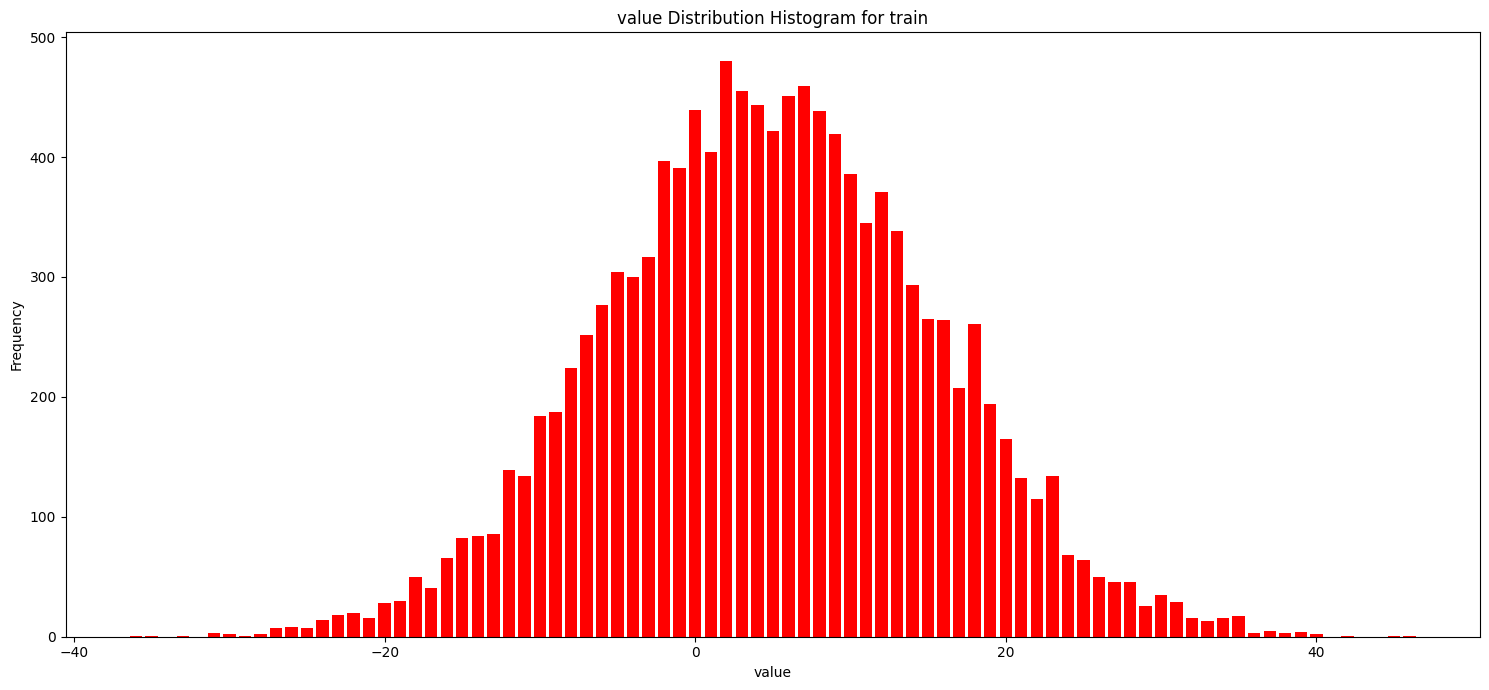

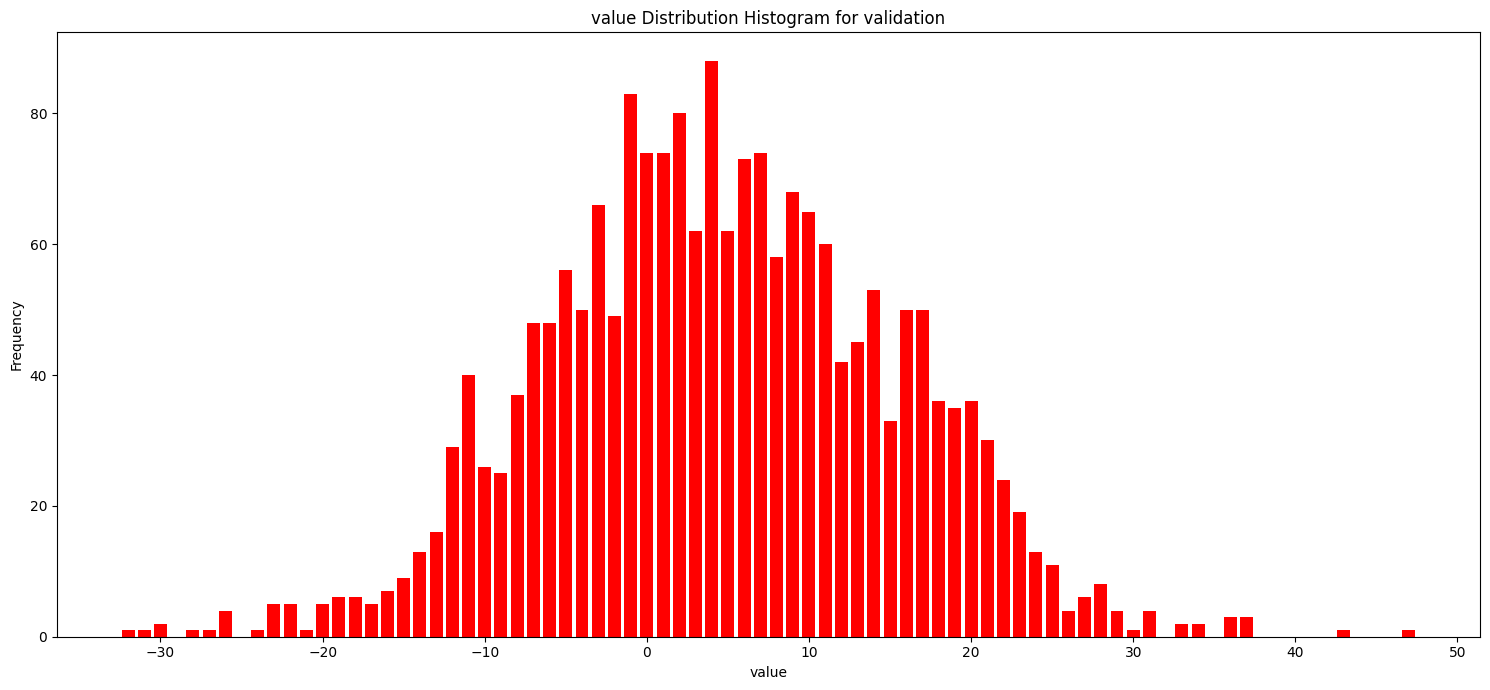

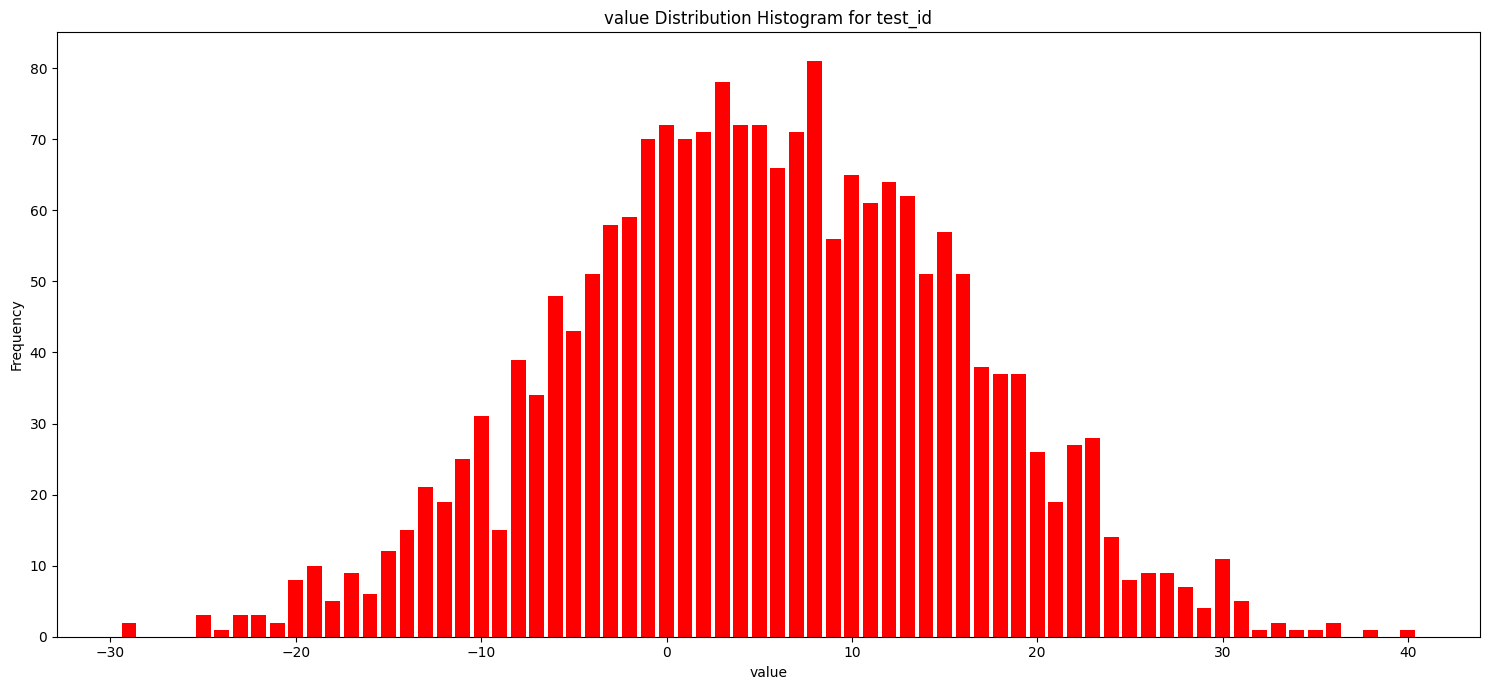

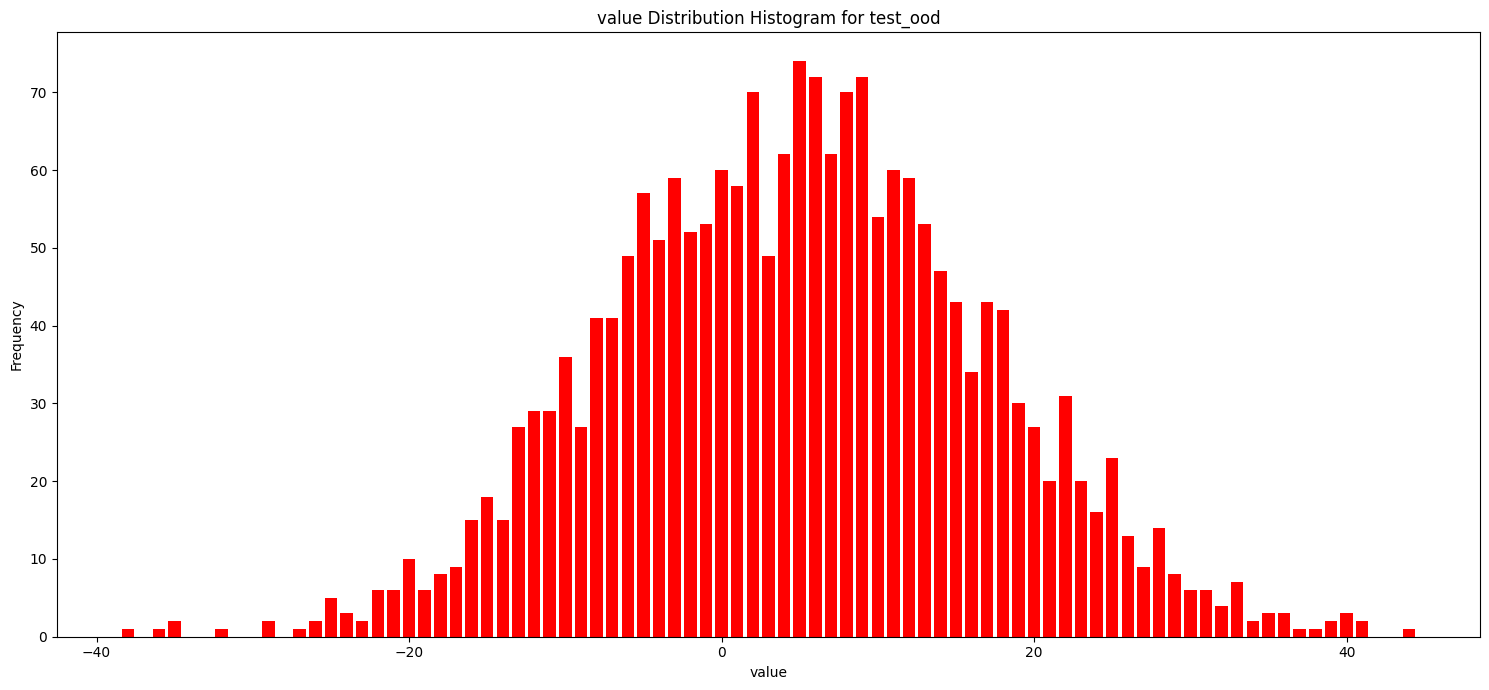

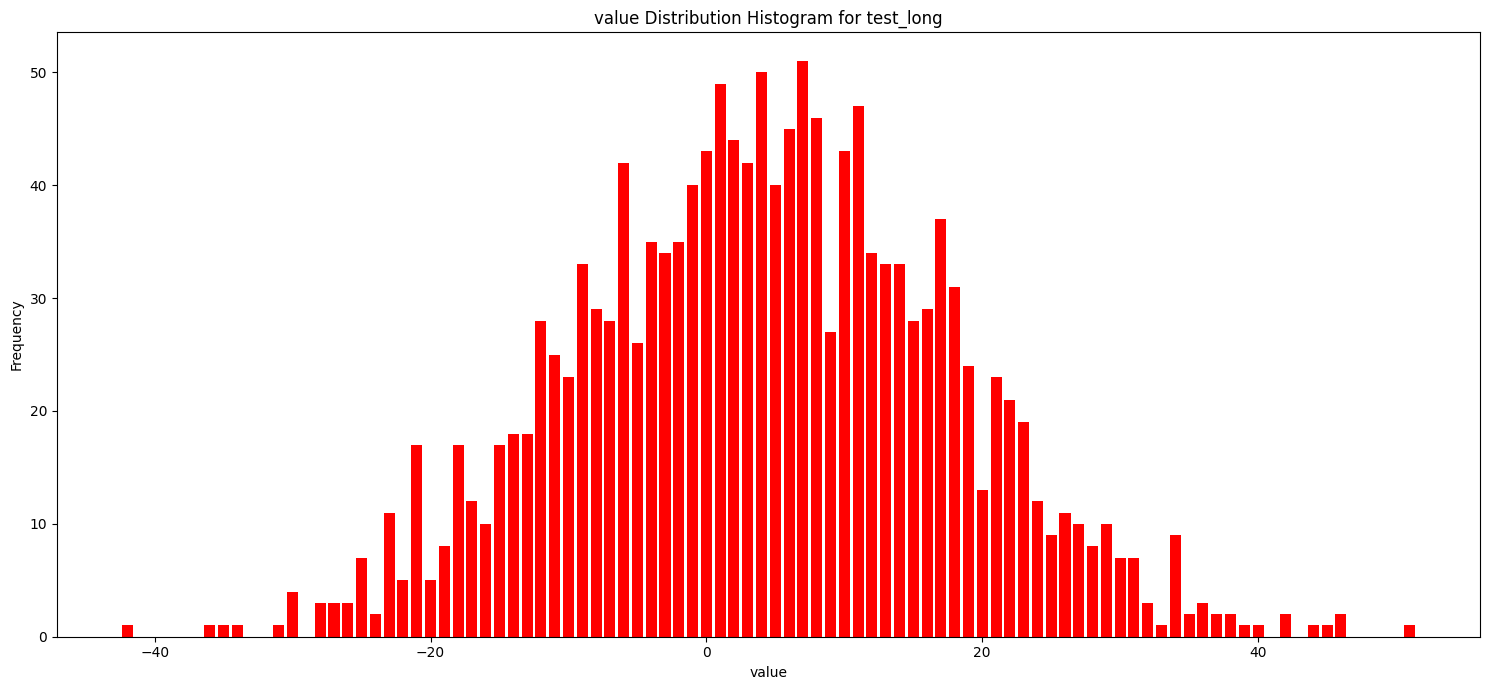

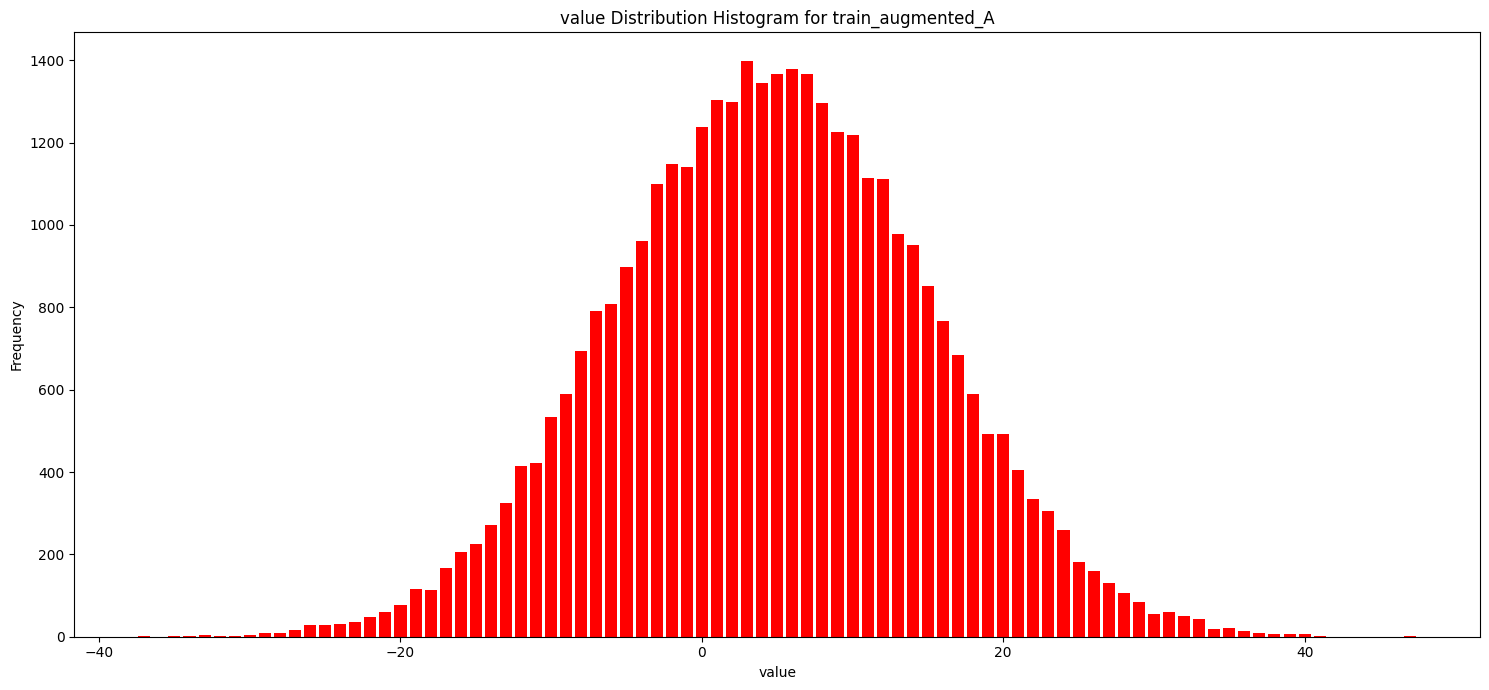

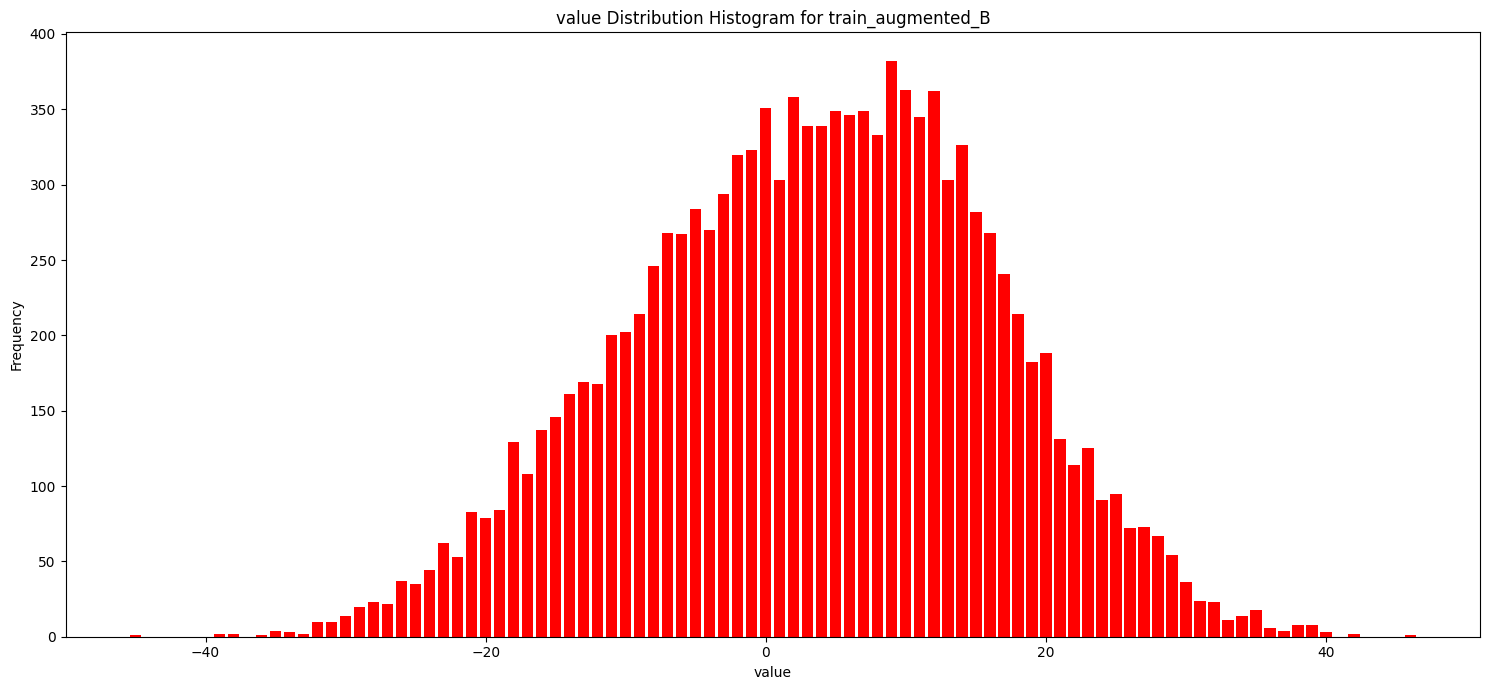

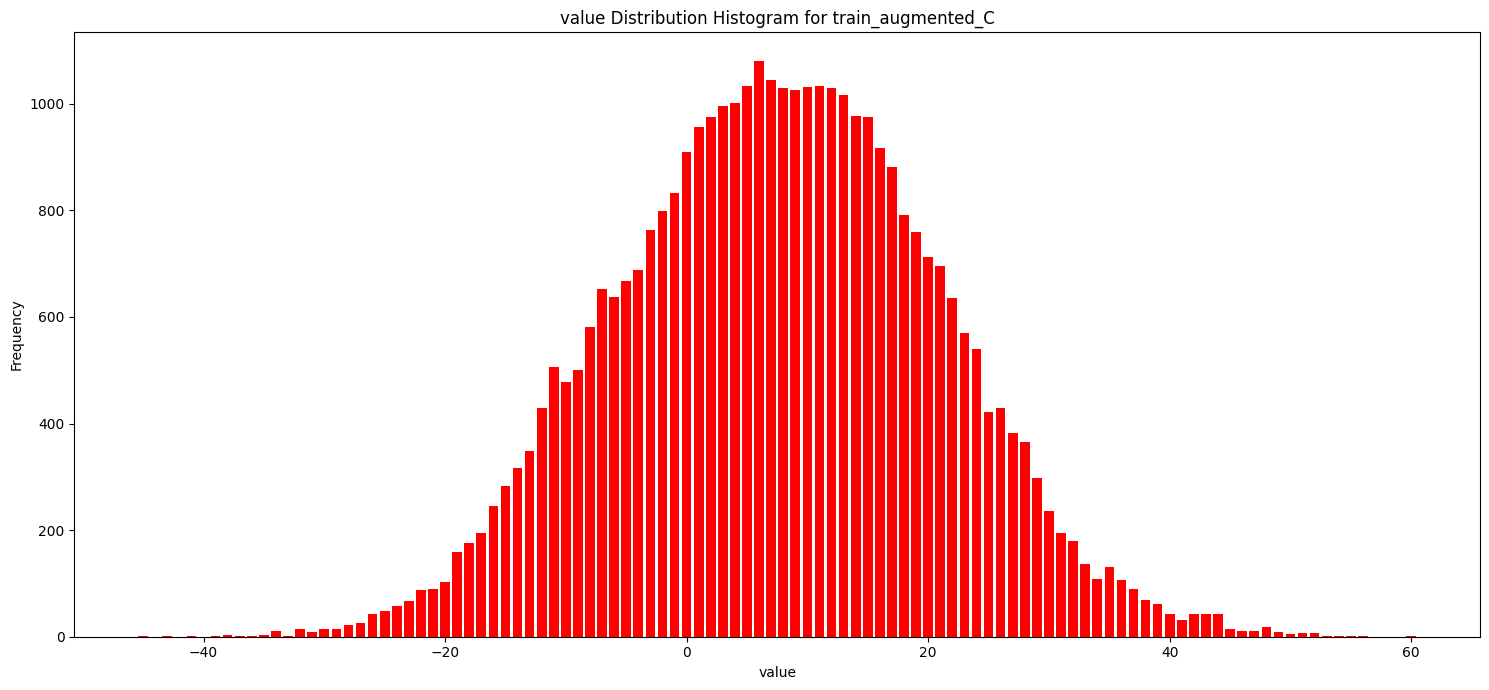

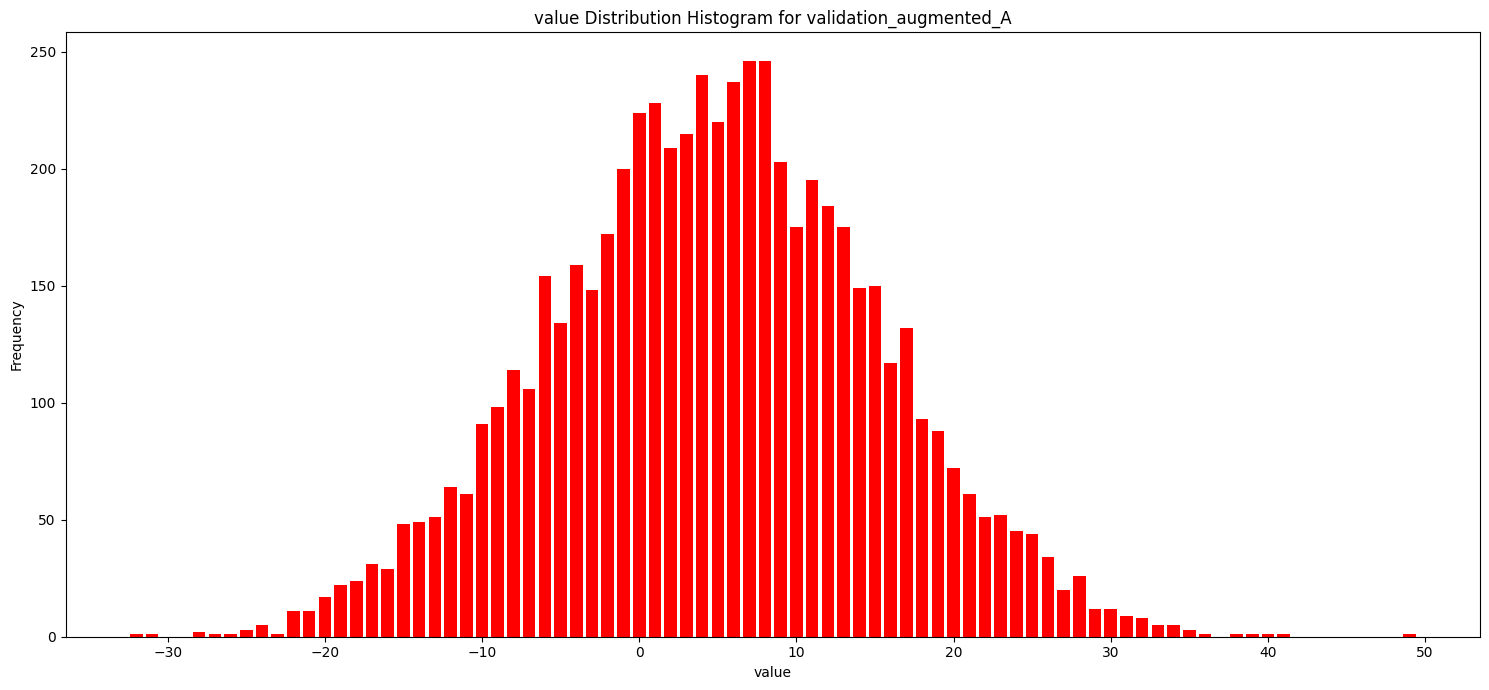

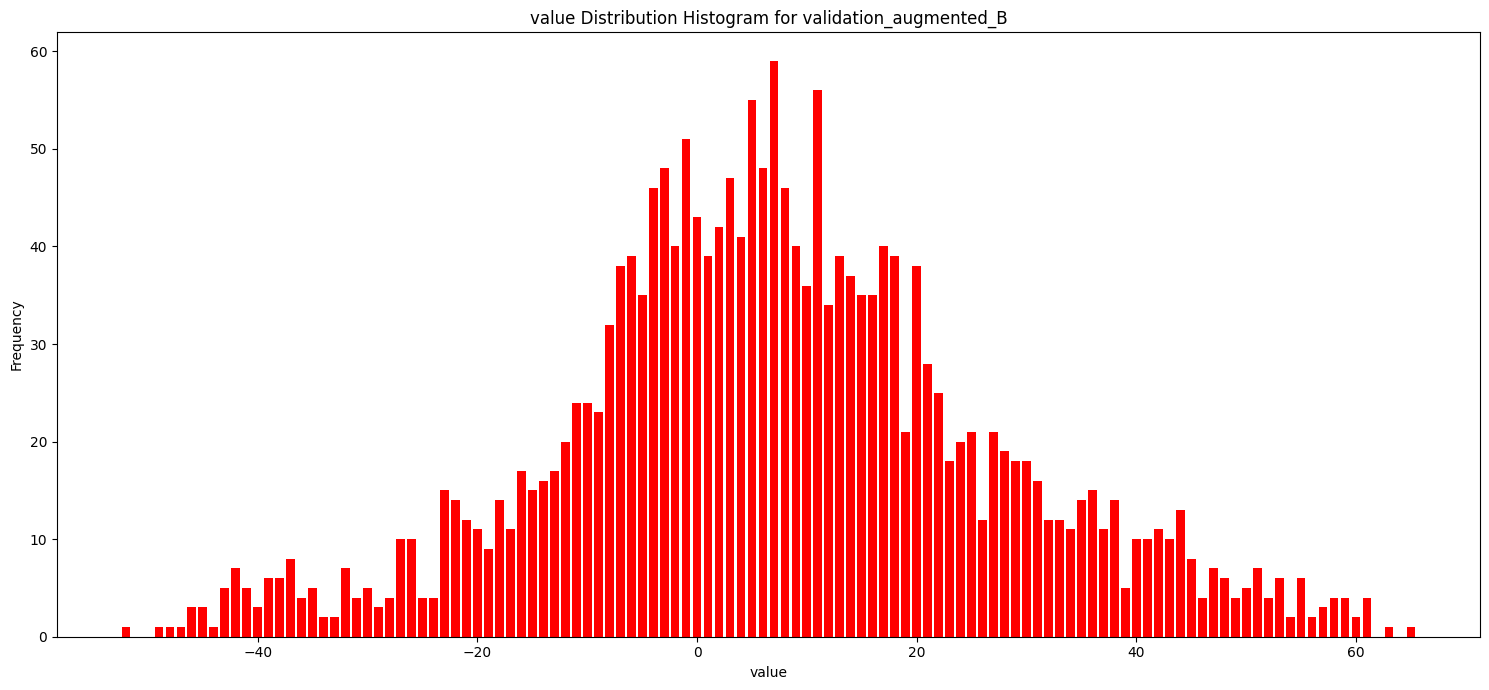

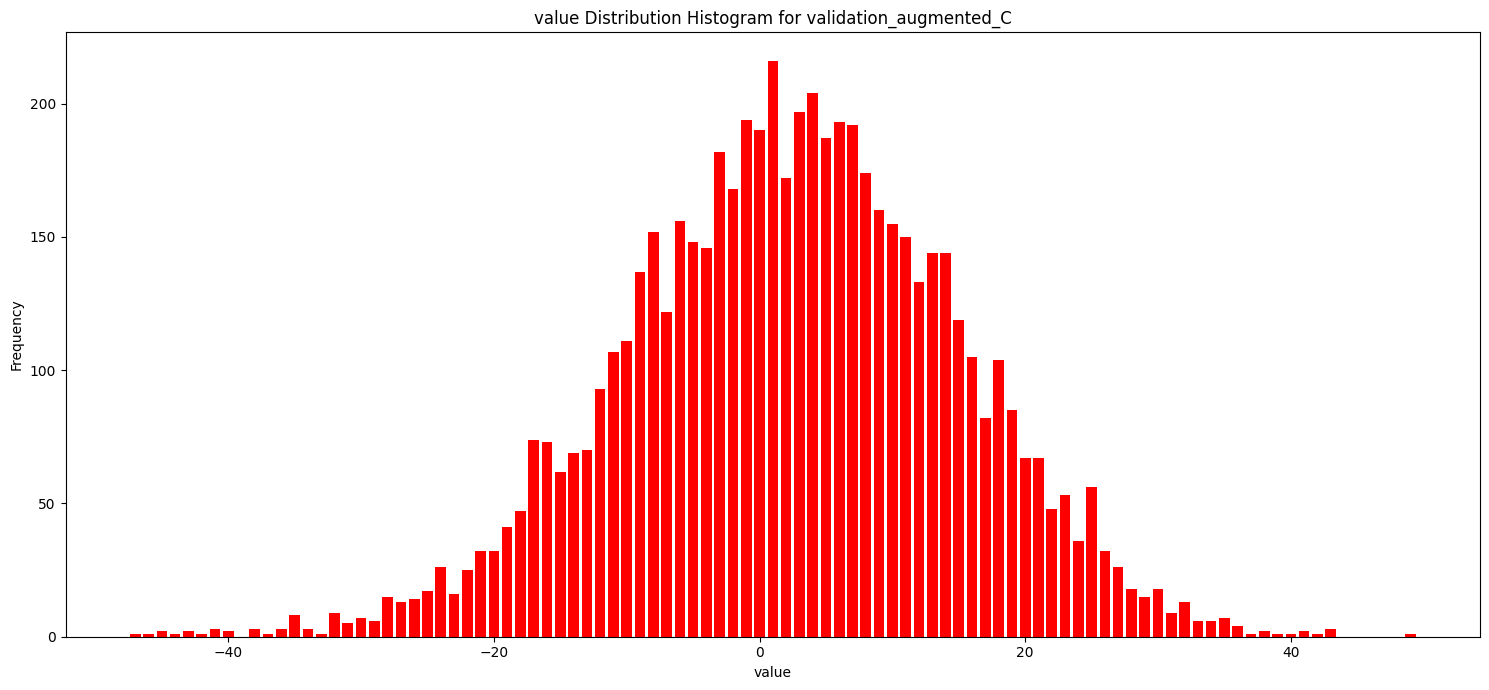

In [100]:
for split_name,df in data.items():
    build_count_histogram(df, "value", split_name)
    print("\n\n\n")

## 3. Helper Functions

### 3.1 Tensor to List
This function is necessary as some libraries do not support gpu

In [35]:
def tensors_to_list(x):
    return [i.detach().cpu().item() if torch.is_tensor(i) else i for i in x]

### 3.2 Draw Loss Graph

In [36]:
def draw_loss_graph(epochs, train_losses, val_losses = None, val_losses_RMSE=None, val_losses_MAE=None):     #for the real training if we want to plot we don't have a validation set
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Train Loss", marker='o')
    if val_losses is not None:
        plt.plot(epochs, tensors_to_list(val_losses), label="Validation Loss", marker='o')       #useful for seeing eventual overfitting
        plt.plot(epochs, tensors_to_list(val_losses_RMSE), label="Root Mean Squared Error on the validation set", marker='o')
        plt.plot(epochs, tensors_to_list(val_losses_MAE), label="Mean Absolute Error on the validation set", marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Losses")
    plt.legend()
    plt.title("Loss Graph")

### 3.3 Saving and Loading

In [37]:
def find_checkpoint(filename, model_dir):
    matches = list(Path(model_dir).rglob(filename))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Checkpoint '{filename}' not found inside {model_dir}. "
            "Please check the downloaded model folder or the checkpoint filename."
        )

    return matches[0]


In [38]:
def save_cnn_checkpoint(model, optimizer, epoch, path, loss=None, extra=None):
    os.makedirs(os.path.dirname(path), exist_ok=True)

    checkpoint = {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict() if optimizer is not None else None,
        "epoch": epoch,
        "loss": loss,
        "model_config": {
            "vocab_size": VOCAB_SIZE,
            "hidden_channels": 128,
            "num_outputs": 1,
        },
        "token_to_index": token_to_index,
        "V": VOCABULARY,
        "pad_token": PAD_TOKEN,
        "y_mean": float(y_mean),
        "y_std": float(y_std),
    }

    if extra is not None:
        checkpoint.update(extra)

    torch.save(checkpoint, path)
    print(f"Checkpoint saved to: {path}")


def load_cnn_checkpoint(path, device):
    checkpoint = torch.load(path, map_location=device)

    model = ExpressionCNNOneHot(**checkpoint["model_config"]).to(device)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
    return model, checkpoint


def save_transformer_checkpoint(model, config, optimizer, epoch, path, loss=None, extra=None):
    os.makedirs(os.path.dirname(path), exist_ok=True)

    checkpoint = {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict() if optimizer is not None else None,
        "epoch": epoch,
        "loss": loss,
        "model_config": config,
        "token_to_index": token_to_index,
        "V": VOCABULARY,
        "pad_token": PAD_TOKEN,
        "y_mean": float(y_mean),
        "y_std": float(y_std),
    }

    torch.save(checkpoint, path)
    print(f"Checkpoint saved to: {path}")


def load_transformer_checkpoint(path, device):
    try:
        checkpoint = torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(path, map_location=device)

    model_config = checkpoint.get("model_config", {}) if isinstance(checkpoint, dict) else {}

    model = TransformerClassifier(
        vocab_size=model_config.get("VOCAB_SIZE", VOCAB_SIZE),
        embedding_dim=model_config.get("EMBEDDING_DIM", TRANSFORMER_EMBEDDING_DIM),
        num_heads=model_config.get("NUM_HEADS", TRANSFORMER_NUM_HEADS),
        hidden_dim=model_config.get("HIDDEN_DIM", TRANSFORMER_HIDDEN_DIM),
        num_layers=model_config.get("NUM_LAYERS", TRANSFORMER_NUM_LAYERS),
        dropout=model_config.get("DROPOUT", TRANSFORMER_DROPOUT),
        num_outputs=TRANSFORMER_NUM_OUTPUTS
    ).to(device)

    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        state_dict = checkpoint["model_state"]
    elif isinstance(checkpoint, dict) and "best_model_state" in checkpoint:
        state_dict = checkpoint["best_model_state"]
    elif isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict)
    model.eval()

    print(f"Loaded Transformer checkpoint from: {path}")

    return model, checkpoint




### 3.4 Oversampling

In [39]:
def build_transformer_focused_train_df(combined_train_df, SEED):
    # Build a harder training set by oversampling long-ish and structurally difficult examples.
    # This does not create new formulas and does not use test data.

    focused_df = combined_train_df.copy()

    subtraction_ratio = (
        focused_df["expression"].str.count("-")
        / focused_df["operator_count"].replace(0, 1) # replace to avoid dividing by 0
    )

    hard_mask = (  # to identify hard examples
        (focused_df["length"] >= 17)
        | (focused_df["depth"] >= 3)
        | (subtraction_ratio >= 0.5)
    )

    very_long_mask = focused_df["length"] >= 19

    # expanding the dataset by adding more hard examples
    focused_df = pd.concat(
        [
            focused_df,
            focused_df[hard_mask],
            focused_df[hard_mask],
            focused_df[very_long_mask],
            focused_df[very_long_mask],
            focused_df[very_long_mask],
        ],
        ignore_index=True  # to create a new continuous index
    )

    focused_df = focused_df.sample(frac=1, random_state=SEED).reset_index(drop=True) # shuffling 100% of datas and resetting the index

    print("Original train size:", len(combined_train_df))
    print("Focused train size:", len(focused_df))

    return focused_df

### 3.5 Make Loaders

In [40]:
def make_cnn_loader(x_data, y_data, batch_size, collate_fn_to_use,shuffle=False):
    dataset = list(zip(x_data, y_data))
    return torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate_fn_to_use
    )

In [41]:
def make_transformer_loader(df, batch_size,shuffle=False):
    labels = (df["value"] + 99).values.astype(int)
    dataset = list(zip(df["expression"], labels))

    return torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=transformer_collate_fn
    )

### 3.6 Histograms

In [42]:
def build_count_histogram(data_df, column, dataset_name='Dataset'):
    if not isinstance(data_df, pd.DataFrame):
        raise TypeError("Input must be a single pandas DataFrame.")

    counts = data_df[column].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(15, 7))
    ax.bar(counts.index, counts.values, color='red')

    # USE THIS FOR EXACT TICK IF PROF ASK, FOR NORMAL REPRESENTATION, ITS TOO CLUTTERED
    # ax.set_xticks(np.arange(counts.index.min(), counts.index.max() + 1, 1))

    ax.set_title(f"{column} Distribution Histogram for {dataset_name}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

    fig.tight_layout()

    return fig, ax

### 3.7 Distances

Here we introduced the wasserstein distance as a bonus interesting point to look at

In [43]:
#assuming all the test sets have a normal distribution
def wasserstein_distance_calc(data_df_1, data_df_2):
    def mean_std(data_df):
        if not isinstance(data_df, pd.DataFrame):
            raise TypeError("Input must be a single pandas DataFrame.")
        mean = data_df['value'].mean()
        std = data_df['value'].std()
        return mean, std

    if not isinstance(data_df_1, pd.DataFrame) or not isinstance(data_df_2, pd.DataFrame):
        raise TypeError("Input must be two pandas Dataframes")
    mean_1, std_1 = mean_std(data_df_1)
    mean_2, std_2 = mean_std(data_df_2)
    u_values = np.random.normal(mean_1, std_1, 10000)
    v_values = np.random.normal(mean_2, std_2, 10000)

    return wasserstein_distance(u_values, v_values)

## 4. CNN Regression

### 4.1 Defining Input and Target (x and y)

In [44]:
combined_train_df = pd.concat([data["train"]], axis=0, ignore_index=True)
combined_validation_df = pd.concat([data["validation"]], axis=0, ignore_index=True)

In [45]:
x_train = combined_train_df["expression"]
y_train = combined_train_df["value"]
x_val = combined_validation_df["expression"]
y_val = combined_validation_df["value"]

### 4.2 Batching and Transformation

We dynamically pad every batch that has to be given to the nn by the length of the maximum element in it. `batch` is a list of `(input_sequence, target_value)` tuples. For us, `input_sequence` is `x_data`, and `target_value` is `y_data`. We will be using this padding method also for the Transformer Classifier

In [46]:
def cnn_collate_fn(batch):
    # Separate inputs (expressions) and targets (values)
    expressions = [item[0] for item in batch]
    values = [item[1] for item in batch]

    # Encode expressions
    encoded_expressions = [encode(expr) for expr in expressions]

    # Find the maximum length in the current batch
    batch_max_length = max(len(seq) for seq in encoded_expressions)

    # Pad each sequence in the batch to batch_max_length
    padded_expressions = []
    for seq in encoded_expressions:
        padding_needed = batch_max_length - len(seq)
        padded_seq = seq + [token_to_index[PAD_TOKEN]] * padding_needed
        padded_expressions.append(padded_seq)

    # Convert to PyTorch tensors
    x_batch = torch.tensor(padded_expressions, dtype=torch.long)
    y_batch = torch.tensor(values, dtype=torch.float)

    return x_batch, y_batch

### 4.3 Model Definition

In [47]:
NUM_OUTPUTS = 1 # For regression, we predict a single value (the result of the expression)

In [48]:
class ExpressionCNNOneHot(nn.Module):
    def __init__(self, vocab_size, hidden_channels=64, num_outputs=1,dropout=0.0):
        super(ExpressionCNNOneHot, self).__init__()

        # Convolution Layers
        self.conv1 = nn.Conv1d(
            in_channels=vocab_size,
            out_channels=hidden_channels,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv1d(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            kernel_size=7,
            padding=3
        )

        self.conv3 = nn.Conv1d(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            kernel_size=7,
            padding=3
        )

        self.conv4 = nn.Conv1d(
            in_channels=hidden_channels,
            out_channels=hidden_channels//2,
            kernel_size=5,
            padding=2
        )

        # Dropout layers
        self.dropout_conv = nn.Dropout(p=dropout)
        self.dropout_fc = nn.Dropout(p=dropout)

        self.fc = nn.Linear(hidden_channels, num_outputs)

    def forward(self, x, mask):
        h = F.relu(self.conv1(x))
        h = self.dropout_conv(h)

        h = F.relu(self.conv2(h))
        h = self.dropout_conv(h)

        h = F.relu(self.conv3(h))
        h = self.dropout_conv(h)

        h = F.relu(self.conv4(h))
        h = self.dropout_conv(h)

        mask = mask.unsqueeze(1)
        h = h * mask

        lengths = mask.sum(dim=2).clamp(min=1)

        #Pooling
        mean_pool = h.sum(dim=2) / lengths
        max_pool = h.max(dim=2).values
        pooled = torch.cat([mean_pool, max_pool], dim=1)
        pooled = self.dropout_fc(pooled)

        output = self.fc(pooled).squeeze(1)
        return output

In [49]:
baseline_cnn_model = ExpressionCNNOneHot(
    vocab_size=VOCAB_SIZE,
    hidden_channels=128,
    num_outputs=1,
    dropout=0.0
)

### 4.4 Training

#### 4.4.1 Train Function

In [50]:
def train(model,
          x_train_data,
          y_train_data,
          optimizer,
          loss_fn,
          normalized_coefficient,
          epochs,
          device,
          batch_size,
          normalized_training = False,
          x_val_data=None,
          y_val_data=None,
          patience = 20,
          min_delta=0.005,
          verbose=True,
          show_loss_graph=True):

    model.to(device)
    train_dataset = list(zip(x_train_data, y_train_data))

    # Dataloaders
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=cnn_collate_fn)
    val_dataset = list(zip(x_val_data, y_val_data))
    val_dataset_len = len(val_dataset)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=cnn_collate_fn)

    # Dynamic learning rate reduction
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.1,
        patience=round(patience * 0.5),
        threshold=min_delta,
        threshold_mode='abs',
    )

    # Flags and Logs
    train_losses = []
    val_losses = []
    val_losses_RMSE = []
    val_losses_MAE = []
    exact_match_accuracies = []
    best_monitor_value = float('inf')
    epochs_without_improvement = 0


    #Best Model Stats
    best_model = {"best_model_state":None,
                  "best_model_epoch": None,
                  "best_model_accuracy": 0.0,
                  "best_model_loss": float('inf'),
                  "best_model_RMSE": float('inf'),
                  "best_model_MAE": float('inf')}

    for epoch in range(epochs):
        model.train()
        losses = []
        for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask = (x_batch != token_to_index[PAD_TOKEN]).float()

            # One-hot encode x_batch and permute for conv1d
            x_batch = F.one_hot(x_batch, num_classes=VOCAB_SIZE).float().permute(0, 2, 1)

            optimizer.zero_grad()
            y_pred = model(x_batch, mask)


            loss = loss_fn(y_pred, y_batch) + normalized_coefficient/2 * torch.norm(model.fc.weight, p=2)**2
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        train_loss = np.mean(losses)
        train_losses.append(train_loss)

        # Validation
        val_loss, RMSE_loss, MAE_loss, correct_matches = evaluate_cnn_regressor(model, val_loader, device, normalized_training)
        exact_match_accuracy = (correct_matches / val_dataset_len) * 100
        val_losses.append(val_loss)
        val_losses_RMSE.append(RMSE_loss)
        val_losses_MAE.append(MAE_loss)
        exact_match_accuracies.append(exact_match_accuracy)

        # Convert validation metrics from tensors to Python floats.
        # This makes comparisons, logging, and checkpoint selection safer and cleaner.
        val_loss_value = val_loss.item()
        rmse_value = RMSE_loss.item()
        mae_value = MAE_loss.item()

        # Update
        previous_best = best_monitor_value

        # Save the best checkpoint whenever validation improves at all.
        if val_loss_value < best_monitor_value:
            best_monitor_value = val_loss_value

            best_model["best_model_state"] = copy.deepcopy(model.state_dict())
            best_model["best_model_epoch"] = epoch + 1
            best_model["best_model_accuracy"] = exact_match_accuracy
            best_model["best_model_loss"] = val_loss_value
            best_model["best_model_RMSE"] = rmse_value
            best_model["best_model_MAE"] = mae_value

        # Reset patience when improvement is over a threshold
        if val_loss_value < previous_best - min_delta:
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered. No meaningful improvement in Validation Loss for {patience} epochs.")
            if show_loss_graph:
              draw_loss_graph([i for i in range(1,len(train_losses)+1)],train_losses,val_losses, val_losses_RMSE, val_losses_MAE)
              plt.show()
              plt.plot([i for i in range(1,len(train_losses)+1)], exact_match_accuracies) # Plot as percentage
              plt.title('Exact match accuracy in percentage vs epoch')
              plt.xlabel('epochs')
              plt.ylabel('exact match accuracy (%)')
              plt.show()


            # Reload the best validation checkpoint before returning.
            # This ensures that future evaluations use the best model selected on validation,
            # not simply the model from the last training epoch.
            if best_model["best_model_state"] is not None:
                model.load_state_dict(best_model["best_model_state"])
                print(f"Reloaded best validation checkpoint from epoch {best_model['best_model_epoch']}")
            return best_model

        if verbose:
            print(f"--- Epoch {epoch+1} ---")
            print(f'Train Loss: {train_loss:.8f}')
            print(f'Validation Loss: {val_loss:.4f}')
            print(f'RMSE Loss on the validation set: {RMSE_loss:.4f}')
            print(f'MAE Loss on the validation set: {MAE_loss:.4f}')
            print(f'Correct predictions on the validation set: {correct_matches:.0f} / {val_dataset_len} ({exact_match_accuracy:.2f}%)')
            print('')

        print('')
        print(scheduler.get_last_lr())
        print('')
        # The scheduler follows the same metric used for early stopping.
        # If this metric reaches a plateau, the learning rate is reduced automatically.
        scheduler.step(val_loss_value)

    if show_loss_graph:
      draw_loss_graph([i for i in range(1,len(train_losses)+1)],train_losses,val_losses, val_losses_RMSE, val_losses_MAE)
      plt.show()
      plt.plot([i for i in range(1,len(train_losses)+1)], exact_match_accuracies) # Plot as percentage
      plt.title('Exact match accuracy in percentage vs epoch')
      plt.xlabel('epochs')
      plt.ylabel('exact match accuracy (%)')
      plt.show()


        # Reload the best validation checkpoint also when training finishes without early stopping.
    # This keeps the model in memory aligned with the checkpoint selected by validation loss.
    if best_model["best_model_state"] is not None:
        model.load_state_dict(best_model["best_model_state"])
        print(f"Reloaded best validation checkpoint from epoch {best_model['best_model_epoch']}")
    return best_model


def evaluate_cnn_regressor(model, loader, device, normalized_training=False):
    model.to(device)
    model.eval()
    RMSE_loss = 0
    MAE_loss = 0
    num_samples = 0
    total_loss = 0
    loss_fn_1 = nn.MSELoss()              #for the RMSE
    loss_fn_2 = nn.L1Loss()               #for the MAE
    correct_matches = 0


    with torch.no_grad():
        for batch_size, (x_batch, y_batch) in enumerate(loader):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask = (x_batch != token_to_index[PAD_TOKEN]).float()

            # One-hot encode x_batch and permute for conv1d
            x_batch = F.one_hot(x_batch, num_classes=VOCAB_SIZE).float().permute(0, 2, 1)

            y_pred = model(x_batch, mask)
            if normalized_training:
                y_pred = denormalize_target_value(y_pred, y_mean, y_std)          #denormalizing the targets for the validation process, useful for exact math accuracy etc...
                y_batch = denormalize_target_value(y_batch, y_mean, y_std)
            for j in range(len(y_pred)):
                RMSE_loss += loss_fn_1(y_pred[j], y_batch[j])
                MAE_loss += loss_fn_2(y_pred[j], y_batch[j])
                pred_rounded = torch.round(y_pred[j]).item()
                target_rounded = torch.round(y_batch[j]).item()

                if pred_rounded == target_rounded:
                    correct_matches += 1
            num_samples += x_batch.shape[0]

    average_loss = RMSE_loss / num_samples
    RMSE_loss = torch.sqrt(RMSE_loss / num_samples)
    MAE_loss = MAE_loss / num_samples

    return average_loss, RMSE_loss, MAE_loss, correct_matches

#### 4.4.2 Hyperparameters, Loss Function and Optimizer

In [51]:
# Training Hyperparameters
BASELINE_CNN_BATCH_SIZE = 32
BASELINE_CNN_LEARNING_RATE = 0.001
BASELINE_CNN_EPOCHS = 1000
BASELINE_CNN_NORMALIZED_TERM = 0.005
BASELINE_CNN_MIN_DELTA=0.005
BASELINE_CNN_PATIENCE = 20
BASELINE_CNN_DROPOUT = 0.0

In [52]:
baseline_cnn_loss_fn = nn.MSELoss()

In [53]:
baseline_cnn_optimizer = torch.optim.Adam(baseline_cnn_model.parameters(), lr=BASELINE_CNN_LEARNING_RATE)

#### 4.4.3 Train Loop

In [54]:
#it is normal for regression, we should normalize the datas and the rescale them, the important thing is that it is decreasing
if RUN_TRAINING:
    baseline_cnn_model_best = train(
        model=baseline_cnn_model,
        x_train_data=x_train,
        y_train_data=y_train,
        optimizer=baseline_cnn_optimizer,
        loss_fn=baseline_cnn_loss_fn,
        normalized_coefficient=BASELINE_CNN_NORMALIZED_TERM,
        epochs=BASELINE_CNN_EPOCHS,
        device=DEVICE,
        batch_size=BASELINE_CNN_BATCH_SIZE,
        x_val_data=x_val,
        y_val_data=y_val,
        patience=20,
        min_delta=0.005,
    )
else:
    print("Skipping Baseline CNN training. Loading pretrained checkpoint instead.")
    CNN_BASELINE_CHECKPOINT = find_checkpoint("baseline_cnn_model_best.pt",MODEL_DIR)
    baseline_cnn_model_best, baseline_cnn_model_best_chkpt = load_cnn_checkpoint(CNN_BASELINE_CHECKPOINT,DEVICE)

Skipping Baseline CNN training. Loading pretrained checkpoint instead.
Loaded checkpoint from epoch 60


#### 4.4.4 Save Best Model

In [55]:
if RUN_TRAINING:
    print("Best CNN checkpoint:")
    print("Epoch:", baseline_cnn_model_best["best_model_epoch"])
    print("Validation accuracy:", baseline_cnn_model_best["best_model_accuracy"])
    print("Validation loss:", baseline_cnn_model_best["best_model_loss"])
    print("Validation RMSE:", baseline_cnn_model_best["best_model_RMSE"])
    print("Validation MAE:", baseline_cnn_model_best["best_model_MAE"])

In [56]:
if RUN_TRAINING:
    model_to_save = baseline_cnn_model
    model_to_save.load_state_dict(baseline_cnn_model_best["best_model_state"])

    extra = {
        "val_accuracy": baseline_cnn_model_best["best_model_accuracy"],
        "val_rmse": baseline_cnn_model_best["best_model_RMSE"],
        "val_mae": baseline_cnn_model_best["best_model_MAE"],
        "normalized_training": False,
    }

    save_cnn_checkpoint(
        model=model_to_save,
        optimizer=baseline_cnn_optimizer,
        epoch=baseline_cnn_model_best["best_model_epoch"],
        path=os.path.join(MODEL_DIR,"baseline_cnn_model_best.pt"),
        loss=baseline_cnn_model_best["best_model_loss"],
        extra=extra
    )

    baseline_cnn_model_best = baseline_cnn_model
else:
    print("Skipping Baseline CNN training and checkpoint saving. Loading pretrained checkpoint instead.")

Skipping Baseline CNN training and checkpoint saving. Loading pretrained checkpoint instead.


### 4.5 Full Evaluation

In [57]:
def cnn_score_summary(model, data, normalized_training):
    x_col = "expression"
    y_col = "normalized_value" if normalized_training else "value"

    train_dataset = list(zip(data["train"][x_col], data["train"][y_col]))
    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=BASELINE_CNN_BATCH_SIZE,
        shuffle=False,
        collate_fn=cnn_collate_fn
    )

    val_dataset = list(zip(data["validation"][x_col], data["validation"][y_col]))
    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=BASELINE_CNN_BATCH_SIZE,
        shuffle=False,
        collate_fn=cnn_collate_fn
    )

    test_id_dataset = list(zip(data["test_id"][x_col], data["test_id"][y_col]))
    test_id_loader = torch.utils.data.DataLoader(
        test_id_dataset,
        batch_size=BASELINE_CNN_BATCH_SIZE,
        shuffle=False,
        collate_fn=cnn_collate_fn
    )

    test_ood_dataset = list(zip(data["test_ood"][x_col], data["test_ood"][y_col]))
    test_ood_loader = torch.utils.data.DataLoader(
        test_ood_dataset,
        batch_size=BASELINE_CNN_BATCH_SIZE,
        shuffle=False,
        collate_fn=cnn_collate_fn
    )

    test_long_dataset = list(zip(data["test_long"][x_col], data["test_long"][y_col]))
    test_long_loader = torch.utils.data.DataLoader(
        test_long_dataset,
        batch_size=BASELINE_CNN_BATCH_SIZE,
        shuffle=False,
        collate_fn=cnn_collate_fn
    )

    _, RMSE_train, MAE_train, correct_train = evaluate_cnn_regressor(
        model, train_loader, DEVICE, normalized_training=normalized_training
    )
    _, RMSE_val, MAE_val, correct_val = evaluate_cnn_regressor(
        model, val_loader, DEVICE, normalized_training=normalized_training
    )
    _, RMSE_id, MAE_id, correct_id = evaluate_cnn_regressor(
        model, test_id_loader, DEVICE, normalized_training=normalized_training
    )
    _, RMSE_ood, MAE_ood, correct_ood = evaluate_cnn_regressor(
        model, test_ood_loader, DEVICE, normalized_training=normalized_training
    )
    _, RMSE_long, MAE_long, correct_long = evaluate_cnn_regressor(
        model, test_long_loader, DEVICE, normalized_training=normalized_training
    )

    print(f"Train RMSE: {RMSE_train:.4f}, MAE: {MAE_train:.4f}, Correct Matches: {correct_train} ({correct_train / len(data['train']['expression']) * 100:.2f}%)")
    print(f"Validation RMSE: {RMSE_val:.4f}, MAE: {MAE_val:.4f}, Correct Matches: {correct_val} ({correct_val / len(data['validation']['expression']) * 100:.2f}%)")
    print(f"Test ID RMSE: {RMSE_id:.4f}, MAE: {MAE_id:.4f}, Correct Matches: {correct_id} ({correct_id / len(data['test_id']['expression']) * 100:.2f}%)")
    print(f"Test OOD RMSE: {RMSE_ood:.4f}, MAE: {MAE_ood:.4f}, Correct Matches: {correct_ood} ({correct_ood / len(data['test_ood']['expression']) * 100:.2f}%)")
    print(f"Test Long RMSE: {RMSE_long:.4f}, MAE: {MAE_long:.4f}, Correct Matches: {correct_long} ({correct_long / len(data['test_long']['expression']) * 100:.2f}%)")

In [58]:
cnn_score_summary(
    model=baseline_cnn_model_best,
    data=data,
    normalized_training=False
)

Train RMSE: 0.0502, MAE: 0.0358, Correct Matches: 11997 (99.98%)
Validation RMSE: 0.2347, MAE: 0.0943, Correct Matches: 1952 (97.60%)
Test ID RMSE: 0.3071, MAE: 0.1074, Correct Matches: 1944 (97.20%)
Test OOD RMSE: 1.1808, MAE: 0.4703, Correct Matches: 1604 (80.20%)
Test Long RMSE: 2.8766, MAE: 1.7340, Correct Matches: 517 (34.47%)


## 5. CNN Regression (Normalised)

### 5.1 Defining Input and Target (x and y)

In [59]:
combined_train_df = pd.concat([data["train"]], axis=0, ignore_index=True)
combined_validation_df = pd.concat([data["validation"]], axis=0, ignore_index=True)

In [60]:
x_train = combined_train_df["expression"]
x_val = combined_validation_df["expression"]
y_train_normalized = combined_train_df["normalized_value"]
y_val_normalized = combined_validation_df["normalized_value"]

### 5.2 Custom Loss Function for Exact Match Accuracy

To address the goal of improving 'exact match accuracy' while still benefiting from target normalization in a regression setup, we can define a custom loss function. This function will combine two main components:

1.  **Mean Squared Error (MSE)**: This is applied to the *normalized* predictions and *normalized* true values. This is the primary regression loss that helps the model learn the overall mapping from input to target, leveraging the stability and convergence benefits of normalization.

2.  **Exact Match Penalty (EMP)**: This term is designed to explicitly encourage the *denormalized* predictions to be very close to the *original integer targets*. The condition for an 'exact match' (after rounding) is that the denormalized prediction `y_pred_denormalized` must satisfy `y_true - 0.5 <= y_pred_denormalized < y_true + 0.5`, where `y_true` is the original integer target. This is equivalent to `|y_pred_denormalized - y_true| < 0.5`.

    Our EMP term will therefore penalize the model when `|y_pred_denormalized - y_true| >= 0.5`. By using `torch.clamp(abs_diff - 0.5, min=0)**2`, we create a differentiable penalty that is zero if the prediction is within 0.5 of the true value and grows quadratically if it's further away. This subtly guides the model towards making predictions that will round correctly, without relying on non-differentiable `torch.round` in the backpropagation.

    

We will define this as a `torch.nn.Module` subclass, making it easy to integrate into the training loop.

In [61]:
class CustomExactMatchLoss(nn.Module):
    def __init__(self, y_mean, y_std, alpha=1.0, beta=0.01, margin=0.5):
        super().__init__()
        self.y_mean = y_mean
        self.y_std = y_std
        self.alpha = alpha
        self.beta = beta
        self.margin = margin
        self.mse_loss_fn = nn.MSELoss(reduction='mean')

    def forward(self, y_pred_normalized, y_true_normalized):
        # 1. MSE component on normalized values
        mse_normalized_loss = self.mse_loss_fn(y_pred_normalized, y_true_normalized)

        # 2. Exact Match Penalty (EMP) component on denormalized values
        y_pred_denormalized = denormalize_target_value(y_pred_normalized, self.y_mean, self.y_std)

        y_true_denormalized = denormalize_target_value(y_true_normalized, self.y_mean, self.y_std)

        abs_diff_denormalized = torch.abs(y_pred_denormalized - y_true_denormalized)
        emp_term = torch.clamp(abs_diff_denormalized - self.margin,min=0)
        emp_loss = torch.mean(emp_term ** 2)


        return self.alpha * mse_normalized_loss + self.beta * emp_loss


### 5.3 Model Definition

In [62]:
normal_cnn_model = ExpressionCNNOneHot(
        vocab_size=VOCAB_SIZE,
        hidden_channels=128,
        num_outputs=1,
        dropout=0.0
    ).to(DEVICE)

### 5.4 Training

#### 5.4.1 Hyperparameters, Loss Function and Optimizer

In [63]:
# Training Hyperparameters
NORMAL_CNN_BATCH_SIZE = 32
NORMAL_CNN_LEARNING_RATE = 0.001
NORMAL_CNN_EPOCHS = 1000
NORMAL_CNN_NORMALIZED_TERM = 0.005
NORMAL_CNN_MIN_DELTA=0.005
NORMAL_CNN_PATIENCE = 20
NORMAL_CNN_DROPOUT = 0.0

normalized_training = True

In [64]:
normal_cnn_loss_fn = CustomExactMatchLoss(y_mean=y_mean,  y_std=y_std, alpha=1.0, beta=0.01, margin=0.5)

In [65]:
normal_cnn_optimizer = torch.optim.Adam(
    normal_cnn_model.parameters(),
    lr=NORMAL_CNN_LEARNING_RATE
)

#### 5.4.2 Train Loop

In [66]:
if RUN_TRAINING:
    normal_cnn_model_best = train(
        model=normal_cnn_model,
        x_train_data=x_train,
        y_train_data=y_train_normalized,
        optimizer=normal_cnn_optimizer,
        loss_fn=normal_cnn_loss_fn,
        normalized_coefficient=NORMAL_CNN_NORMALIZED_TERM,
        epochs=NORMAL_CNN_EPOCHS,
        device=DEVICE,
        batch_size=NORMAL_CNN_BATCH_SIZE,
        normalized_training=normalized_training,
        x_val_data=x_val,
        y_val_data=y_val_normalized,
        patience=20,
        min_delta=0.005,
    )
else:
    print("Skipping Normal CNN training. Loading pretrained checkpoint instead.")
    CNN_NORMAL_CHECKPOINT = find_checkpoint(
        "normal_cnn_model_best.pt",
        MODEL_DIR
    )

    normal_cnn_model_best, normal_cnn_model_best_chkpt = load_cnn_checkpoint(CNN_NORMAL_CHECKPOINT,DEVICE)

Skipping Normal CNN training. Loading pretrained checkpoint instead.
Loaded checkpoint from epoch 60


#### 5.4.3 Save Best Model

In [67]:
if RUN_TRAINING:
    print("Best CNN custom loss checkpoint:")
    print("Epoch:", normal_cnn_model_best["best_model_epoch"])
    print("Validation accuracy:", normal_cnn_model_best["best_model_accuracy"])
    print("Validation loss:", normal_cnn_model_best["best_model_loss"])
    print("Validation RMSE:", normal_cnn_model_best["best_model_RMSE"])
    print("Validation MAE:", normal_cnn_model_best["best_model_MAE"])

In [68]:
if RUN_TRAINING:
    model_to_save = normal_cnn_model
    model_to_save.load_state_dict(normal_cnn_model_best["best_model_state"])

    extra = {
        "val_accuracy": normal_cnn_model_best["best_model_accuracy"],
        "val_rmse": normal_cnn_model_best["best_model_RMSE"],
        "val_mae": normal_cnn_model_best["best_model_MAE"],
        "normalized_training": True,
    }

    save_cnn_checkpoint(
        model=model_to_save,
        optimizer=normal_cnn_optimizer,
        epoch=normal_cnn_model_best["best_model_epoch"],
        path=os.path.join(MODEL_DIR, "normal_cnn_model_best.pt"),
        loss=normal_cnn_model_best["best_model_loss"],
        extra=extra
    )

    normal_cnn_model_best = normal_cnn_model
else:
    print("Skipping Normal CNN training and checkpoint saving. Loading pretrained checkpoint instead.")

Skipping Normal CNN training and checkpoint saving. Loading pretrained checkpoint instead.


### 5.5 Full Evaluation

In [69]:
cnn_score_summary(
    model=normal_cnn_model_best,
    data=data,
    normalized_training=True
)

Train RMSE: 0.0421, MAE: 0.0315, Correct Matches: 12000 (100.00%)
Validation RMSE: 0.0742, MAE: 0.0468, Correct Matches: 1995 (99.75%)
Test ID RMSE: 0.0724, MAE: 0.0451, Correct Matches: 1996 (99.80%)
Test OOD RMSE: 1.1965, MAE: 0.4305, Correct Matches: 1700 (85.00%)
Test Long RMSE: 3.3913, MAE: 2.1687, Correct Matches: 553 (36.87%)


## 6. Transformer Classification

### 6.1 Defining Input and Target (x and y)

In [70]:
if RUN_TRAINING:
    train_df_focused = build_transformer_focused_train_df(combined_train_df, SEED)

    x_train_transformer = train_df_focused["expression"]
    y_train_transformer = (train_df_focused["value"] + 99).values.astype(int)

    x_val_transformer = combined_validation_df["expression"]
    y_val_transformer = (combined_validation_df["value"] + 99).values.astype(int)

### 6.2 Batching and Transformation

In [71]:
def transformer_collate_fn(batch):
    expressions = [item[0] for item in batch]
    labels = [item[1] for item in batch]

    encoded_expressions = [encode(expr) for expr in expressions]
    batch_max_length = max(len(seq) for seq in encoded_expressions)

    padded_expressions = [
        seq + [token_to_index[PAD_TOKEN]] * (batch_max_length - len(seq))
        for seq in encoded_expressions
    ]

    x_batch = torch.tensor(padded_expressions, dtype=torch.long)
    y_batch = torch.tensor(labels, dtype=torch.long)

    return x_batch, y_batch

### 6.3 Model Definition

In [72]:
TRANSFORMER_EMBEDDING_DIM = 128
TRANSFORMER_HIDDEN_DIM = 512
TRANSFORMER_NUM_HEADS = 4
TRANSFORMER_NUM_LAYERS = 3
TRANSFORMER_DROPOUT = 0.1
TRANSFORMER_NUM_OUTPUTS = 199

In [73]:
class SinusoidalPositionalEmbedding(nn.Module):
    """
    Adds sinusoidal positional encodings to token embeddings.
    Expected input shape: [batch_size, sequence_length, embedding_dim].
    """
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        num_heads,
        hidden_dim,
        num_layers,
        dropout,
        num_outputs
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=token_to_index[PAD_TOKEN]
        )

        self.pos_embedding = SinusoidalPositionalEmbedding(embedding_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            activation="relu",
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(2 * embedding_dim, num_outputs)

    def forward(self, x, mask):
        x = self.embedding(x)
        x = self.pos_embedding(x)

        x = self.transformer_encoder(
            x,
            src_key_padding_mask=mask.bool()
        )

        mask_expanded = mask.unsqueeze(-1)

        x_zeroed = x.masked_fill(mask_expanded, 0.0)
        num_non_padded = (~mask).sum(dim=1).unsqueeze(-1).clamp(min=1)
        mean_pool = x_zeroed.sum(dim=1) / num_non_padded

        x_for_max = x.masked_fill(mask_expanded, -1e9)
        max_pool = x_for_max.max(dim=1).values

        pooled = torch.cat([mean_pool, max_pool], dim=1)

        return self.fc(pooled)

In [74]:
transformer_model = TransformerClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=TRANSFORMER_EMBEDDING_DIM,
    num_heads=TRANSFORMER_NUM_HEADS,
    hidden_dim=TRANSFORMER_HIDDEN_DIM,
    num_layers=TRANSFORMER_NUM_LAYERS,
    dropout=TRANSFORMER_DROPOUT,
    num_outputs=TRANSFORMER_NUM_OUTPUTS
).to(DEVICE)

print(
    f"Number of Transformer parameters: "
    f"{sum(p.numel() for p in transformer_model.parameters())}"
)

Number of Transformer parameters: 648007


### 6.4 Training

#### 6.4.1 Train Function

In [75]:
def train_transformer_classifier(model,
          x_train_data,
          y_train_data,
          optimizer,
          loss_fn,
          weight_decay_coefficient,
          epochs,
          device,
          batch_size,
          x_val_data=None,
          y_val_data=None,
          patience = 20,
          verbose=True,
          show_loss_graph=True):

    model.to(device)
    # Create DataLoader for training data
    train_dataset = list(zip(x_train_data, y_train_data))
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=transformer_collate_fn)



    val_dataset = list(zip(x_val_data, y_val_data))
    val_dataset_len = len(val_dataset)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=transformer_collate_fn)


    # Dynamic LR Reduction
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.1,
        patience=round(patience*0.5)
    )

    # Flags and Logs
    train_losses = []
    val_losses = []
    val_losses_RMSE = []              #RMSE on the validation set
    val_losses_MAE = []                 #MAE on the validation set
    exact_match_accuracies = []

    best_accuracy = -1.0 # Ensures that the first validation epoch is always stored as the initial best checkpoint.
    epochs_without_improvement = 0


    #Best Model Stats
    best_model = {
        "best_model_state": None,
        "best_model_epoch": None,
        "best_model_accuracy": 0.0,
        "best_model_loss": float('inf'),
        "best_model_RMSE": float('inf'),
        "best_model_MAE": float('inf')
    }

    for epoch in range(epochs):
      model.train()
      losses = []

      for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
          x_batch = x_batch.to(device)
          y_batch = y_batch.to(device)
          mask = (x_batch == token_to_index[PAD_TOKEN]) # True for padding, False for valid tokens


          optimizer.zero_grad()
          y_pred = model(x_batch, mask)

          loss = (loss_fn(y_pred, y_batch) + weight_decay_coefficient/2 * torch.norm(model.fc.weight, p=2)**2)
          loss.backward()
          optimizer.step()
          losses.append(loss.item())

      train_loss = np.mean(losses)
      train_losses.append(train_loss)         #END OF TRAINING PART

      val_loss, RMSE_loss, MAE_loss, correct_matches = evaluate_transformer_classifier(model, val_loader, device)
      exact_match_accuracy = (correct_matches / val_dataset_len) * 100
      val_losses.append(val_loss)
      val_losses_RMSE.append(RMSE_loss)
      val_losses_MAE.append(MAE_loss)
      exact_match_accuracies.append(exact_match_accuracy)

      if exact_match_accuracy > best_accuracy:
          best_accuracy = exact_match_accuracy

          best_model["best_model_state"] = copy.deepcopy(model.state_dict())
          best_model["best_model_epoch"] = epoch + 1
          best_model["best_model_accuracy"] = exact_match_accuracy
          best_model["best_model_loss"] = val_loss.item()
          best_model["best_model_RMSE"] = RMSE_loss.item()
          best_model["best_model_MAE"] = MAE_loss.item()

          epochs_without_improvement = 0
      else:
          epochs_without_improvement += 1

      if verbose:
          print(f"--- Epoch {epoch + 1} ---")
          print(f"Train Loss: {train_loss:.4f}")
          print(f"Validation Loss: {val_loss:.4f}")
          print(f"Validation RMSE: {RMSE_loss:.4f}")
          print(f"Validation MAE: {MAE_loss:.4f}")
          print(f"Correct predictions on validation: "f"{correct_matches:.0f} / {val_dataset_len} "f"({exact_match_accuracy:.2f}%)")
          print(f"Best validation accuracy so far: "f"{best_model['best_model_accuracy']:.2f}% "f"at epoch {best_model['best_model_epoch']}")
          print("")

      scheduler.step(exact_match_accuracy)

      if epochs_without_improvement >= patience:
          print(
              f"Early stopping triggered. "
              f"No improvement in validation accuracy for {patience} epochs."
          )

          if show_loss_graph:
              draw_loss_graph(
                  [i for i in range(1, len(train_losses) + 1)],
                  train_losses,
                  val_losses,
                  val_losses_RMSE,
                  val_losses_MAE
              )
              plt.show()

              plt.plot(
                  [i for i in range(1, len(train_losses) + 1)],
                  exact_match_accuracies
              )
              plt.title("Exact-match accuracy vs epoch")
              plt.xlabel("Epoch")
              plt.ylabel("Exact-match accuracy (%)")
              plt.show()

          return best_model

    return best_model

def evaluate_transformer_classifier(model, loader, device):
    model.to(device)
    model.eval()
    total_ce_loss = 0.0 # Cross Entropy Loss
    total_rmse_sum_sq = 0.0 # RMSE Loss
    total_mae_sum_abs = 0.0 # MAE Loss
    num_samples = 0
    correct_matches = 0

    loss_fn_ce = nn.CrossEntropyLoss(reduction='sum') #Train Loss
    loss_fn_mse = nn.MSELoss(reduction='sum') # MSELoss
    loss_fn_l1 = nn.L1Loss(reduction='sum') # L1Loss

    with torch.no_grad():
          for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            mask = (x_batch == token_to_index[PAD_TOKEN])

            y_pred_logits = model(x_batch, mask)
            y_pred_indices = torch.argmax(y_pred_logits, dim=1)

            current_batch_size = x_batch.shape[0]

            # Calculate CrossEntropyLoss for the batch
            total_ce_loss += loss_fn_ce(y_pred_logits, y_batch).item()

            # Calculate accuracy
            correct_matches += (y_pred_indices == y_batch).sum().item()

            # Calculate RMSE and MAE. Convert y_pred_indices and y_batch to float for these metrics.
            total_rmse_sum_sq += loss_fn_mse(y_pred_indices.float(), y_batch.float()).item()
            total_mae_sum_abs += loss_fn_l1(y_pred_indices.float(), y_batch.float()).item()

            num_samples += current_batch_size

    if num_samples == 0:
        return torch.tensor(0.0), torch.tensor(0.0), torch.tensor(0.0), 0

    average_ce_loss = total_ce_loss / num_samples
    average_rmse_loss = torch.sqrt(torch.tensor(total_rmse_sum_sq / num_samples))
    average_mae_loss = torch.tensor(total_mae_sum_abs / num_samples) # Convert to tensor here

    return torch.tensor(average_ce_loss), average_rmse_loss, average_mae_loss, correct_matches

#### 6.4.2 Hyperparameters, Loss Function and Optimizer

In [76]:
TRANSFORMER_BATCH_SIZE = 128
TRANSFORMER_LEARNING_RATE = 0.001
TRANSFORMER_EPOCHS = 1000
TRANSFORMER_WEIGHT_DECAY = 0.001
TRANSFORMER_PATIENCE = 20

In [77]:
transformer_loss_fn = nn.CrossEntropyLoss()

In [78]:
transformer_optimizer = torch.optim.Adam(transformer_model.parameters(),lr=TRANSFORMER_LEARNING_RATE)

#### 6.4.3 Train Loop

In [79]:
if RUN_TRAINING:
    transformer_model_best = train_transformer_classifier(
        model=transformer_model,
        x_train_data=x_train_transformer,
        y_train_data=y_train_transformer,
        optimizer=transformer_optimizer,
        loss_fn=transformer_loss_fn,
        weight_decay_coefficient=TRANSFORMER_WEIGHT_DECAY,
        epochs=TRANSFORMER_EPOCHS,
        device=DEVICE,
        batch_size=TRANSFORMER_BATCH_SIZE,
        x_val_data=x_val_transformer,
        y_val_data=y_val_transformer,
        patience=TRANSFORMER_PATIENCE,
        verbose=True,
        show_loss_graph=True
    )
else:
    print("Skipping Transformer training. Loading pretrained checkpoint instead.")

    TRANSFORMER_CHECKPOINT = find_checkpoint(
        "transformer_model_best.pt",
        MODEL_DIR
    )

    transformer_model, transformer_model_chkpt = load_transformer_checkpoint(
        TRANSFORMER_CHECKPOINT,
        DEVICE
    )

Skipping Transformer training. Loading pretrained checkpoint instead.
Loaded Transformer checkpoint from: /content/ML_Exam_Project/model/transformer_model_best.pt


#### 6.4.4 Save Best Model

In [80]:
if RUN_TRAINING:
    print("Best Transformer checkpoint")
    print("Epoch:", transformer_model_best["best_model_epoch"])
    print("Validation accuracy:", transformer_model_best["best_model_accuracy"])
    print("Validation CE loss:", transformer_model_best["best_model_loss"])
    print("Validation RMSE:", transformer_model_best["best_model_RMSE"])
    print("Validation MAE:", transformer_model_best["best_model_MAE"])

In [81]:
if RUN_TRAINING:
    model_to_save = transformer_model
    model_to_save.load_state_dict(transformer_model_best["best_model_state"])

    config = {
        "VOCAB_SIZE": VOCAB_SIZE,
        "EMBEDDING_DIM": TRANSFORMER_EMBEDDING_DIM,
        "HIDDEN_DIM" :TRANSFORMER_HIDDEN_DIM,
        "NUM_HEADS" :TRANSFORMER_NUM_HEADS,
        "NUM_LAYERS": TRANSFORMER_NUM_LAYERS,
        "DROPOUT":TRANSFORMER_DROPOUT,
        "NUM_OUTPUTS":TRANSFORMER_NUM_OUTPUTS
    }

    extra = {
        "val_accuracy": transformer_model_best["best_model_accuracy"],
        "val_rmse": transformer_model_best["best_model_RMSE"],
        "val_mae": transformer_model_best["best_model_MAE"]
    }

    save_transformer_checkpoint(
        model=model_to_save,
        config=config,
        optimizer=transformer_optimizer,
        epoch=transformer_model_best["best_model_epoch"],
        path=os.path.join(MODEL_DIR,"transformer_model_best.pt"),
        loss=transformer_model_best["best_model_loss"],
        extra=extra
    )

    transformer_model_best = transformer_model

###6.5 Full Evaluation

In [82]:
def transformer_score_summary(model, data):
    train_loader = make_transformer_loader(data["train"],TRANSFORMER_BATCH_SIZE)
    val_loader = make_transformer_loader(data["validation"],TRANSFORMER_BATCH_SIZE)
    test_id_loader = make_transformer_loader(data["test_id"],TRANSFORMER_BATCH_SIZE)
    test_ood_loader = make_transformer_loader(data["test_ood"],TRANSFORMER_BATCH_SIZE)
    test_long_loader = make_transformer_loader(data["test_long"],TRANSFORMER_BATCH_SIZE)

    _, RMSE_train, MAE_train, correct_train = evaluate_transformer_classifier(
        model, train_loader, DEVICE
    )
    _, RMSE_val, MAE_val, correct_val = evaluate_transformer_classifier(
        model, val_loader, DEVICE
    )
    _, RMSE_id, MAE_id, correct_id = evaluate_transformer_classifier(
        model, test_id_loader, DEVICE
    )
    _, RMSE_ood, MAE_ood, correct_ood = evaluate_transformer_classifier(
        model, test_ood_loader, DEVICE
    )
    _, RMSE_long, MAE_long, correct_long = evaluate_transformer_classifier(
        model, test_long_loader, DEVICE
    )

    print(f"Train RMSE: {RMSE_train:.4f}, MAE: {MAE_train:.4f}, Correct Matches: {correct_train} ({correct_train / len(data['train']) * 100:.2f}%)")
    print(f"Validation RMSE: {RMSE_val:.4f}, MAE: {MAE_val:.4f}, Correct Matches: {correct_val} ({correct_val / len(data['validation']) * 100:.2f}%)")
    print(f"Test ID RMSE: {RMSE_id:.4f}, MAE: {MAE_id:.4f}, Correct Matches: {correct_id} ({correct_id / len(data['test_id']) * 100:.2f}%)")
    print(f"Test OOD RMSE: {RMSE_ood:.4f}, MAE: {MAE_ood:.4f}, Correct Matches: {correct_ood} ({correct_ood / len(data['test_ood']) * 100:.2f}%)")
    print(f"Test Long RMSE: {RMSE_long:.4f}, MAE: {MAE_long:.4f}, Correct Matches: {correct_long} ({correct_long / len(data['test_long']) * 100:.2f}%)")

In [83]:
transformer_score_summary(model=transformer_model,data=data)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Train RMSE: 0.2004, MAE: 0.0245, Correct Matches: 11768 (98.07%)
Validation RMSE: 0.3025, MAE: 0.0425, Correct Matches: 1936 (96.80%)
Test ID RMSE: 0.2398, MAE: 0.0415, Correct Matches: 1927 (96.35%)
Test OOD RMSE: 2.9948, MAE: 0.8480, Correct Matches: 1580 (79.00%)
Test Long RMSE: 6.6645, MAE: 3.8547, Correct Matches: 443 (29.53%)


## 7. Comparison Between the Models

### 7.1 Run Per-Sample Prediction

In [84]:
def run_predictions(input_df, device, cnn_model, transformer_model, batch_size_transformer=128, batch_size_cnn=32):
    if isinstance(input_df, pd.DataFrame):
        df = input_df
    elif isinstance(input_df, list):
        if not all(isinstance(d, pd.DataFrame) for d in input_df):
            raise TypeError("All elements in the list must be pandas DataFrames.")
        df = pd.concat(input_df, ignore_index=True)
    else:
        raise TypeError("Input must be a pandas DataFrame or list of DataFrames.")

    predictions_cnn = []
    predictions_transformer = []
    exact_match_cnn = []
    exact_match_transformer = []

    loader_transformer = make_transformer_loader(df,batch_size=batch_size_transformer, shuffle=False)
    loader_cnn = make_cnn_loader(df["expression"], df['value'], batch_size=batch_size_cnn, collate_fn_to_use=cnn_collate_fn, shuffle=False)

    # CNN Predictioms
    cnn_model.eval()
    with torch.no_grad():
        for x_batch, y_batch in loader_cnn:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            mask = (x_batch != token_to_index[PAD_TOKEN]).float()
            x_batch_one_hot = F.one_hot(x_batch, num_classes=VOCAB_SIZE).float().permute(0, 2, 1)
            y_pred = cnn_model(x_batch_one_hot, mask)
            y_pred = denormalize_target_value(y_pred, y_mean, y_std)
            # y_batch here is the original value, not normalized, so denormalization of y_batch is not needed
            # to compare with y_pred

            for i in range(len(y_pred)):
                # Round y_pred to the nearest integer for comparison
                predictions_cnn.append(round(y_pred[i].item()))
                # Compare the rounded prediction with the original true value
                exact_match_cnn.append(round(y_pred[i].item()) == y_batch[i].item())

    # Transformer Predictions
    transformer_model.eval()
    with torch.no_grad():
        for x_batch, y_batch_classification in loader_transformer:
            x_batch = x_batch.to(device)
            y_batch_classification = y_batch_classification.to(device)

            mask = (x_batch == token_to_index[PAD_TOKEN]) # Transformer expects boolean mask
            y_pred_logits = transformer_model(x_batch, mask)
            y_pred_indices = torch.argmax(y_pred_logits, dim=1)

            real_y_pred = (y_pred_indices - 99).tolist()
            real_y_true = (y_batch_classification - 99).tolist()

            for i in range(len(real_y_pred)):
                predictions_transformer.append(real_y_pred[i])
                exact_match_transformer.append(real_y_pred[i] == real_y_true[i])


    df["prediction_cnn"] = predictions_cnn
    df["exact_match_cnn"] = exact_match_cnn
    df["prediction_transformer"] = predictions_transformer
    df["exact_match_transformer"] = exact_match_transformer

    return df

In [85]:
train_prediction_df = run_predictions(data["train"],DEVICE,cnn_model=normal_cnn_model_best,transformer_model=transformer_model)
test_id_prediction_df = run_predictions(data["test_id"],DEVICE,cnn_model=normal_cnn_model_best,transformer_model=transformer_model)
test_ood_prediction_df = run_predictions(data["test_ood"],DEVICE,cnn_model=normal_cnn_model_best,transformer_model=transformer_model)
test_long_prediction_df = run_predictions(data["test_long"],DEVICE,cnn_model=normal_cnn_model_best,transformer_model=transformer_model)

test_all_prediction_df = pd.concat(
    [test_id_prediction_df, test_ood_prediction_df, test_long_prediction_df],
    ignore_index=True
)

test_all_prediction_df.head()


,id,expression,value,length,operator_count,depth,normalized_value,prefix,postfix,prediction_cnn,exact_match_cnn,prediction_transformer,exact_match_transformer
0,test_id-00000,1-(1-5),5,7,2,3,0.013148,- 1 - 1 5,1 1 5 - -,5,True,5,True
1,test_id-00001,9-(2-6),13,7,2,3,0.768525,- 9 - 2 6,9 2 6 - -,13,True,13,True
2,test_id-00002,0+0+5+6-6,5,9,4,4,0.013148,- + + + 0 0 5 6 6,0 0 + 5 + 6 + 6 -,5,True,5,True
3,test_id-00003,2-8-(8+8),-22,9,3,3,-2.536248,- - 2 8 + 8 8,2 8 - 8 8 + -,-22,True,-22,True
4,test_id-00004,9-(5-(5+7-2)),14,13,4,5,0.862947,- 9 - 5 - + 5 7 2,9 5 5 7 + 2 - - -,14,True,14,True


### 7.2 Prediction Histograms

In [86]:
predictions_df = [
    train_prediction_df,
    test_id_prediction_df,
    test_ood_prediction_df,
    test_long_prediction_df,
    test_all_prediction_df
]

df_names = ["train", "test_id", "test_ood", "test_long", "test_all"]

#### 7.2.1 Exact Match Histogram

In [87]:
def build_exact_match_histogram(
    pred_df,
    pred_col,
    group_col,
    return_percentage=False,
    match_value=True,
    ax=None,
    title=None
):
    if not isinstance(pred_df, pd.DataFrame):
        raise TypeError("Input must be a single pandas DataFrame.")

    match_counts = {}
    total_counts = {}

    for value in pred_df[group_col].unique():
        match_count = pred_df[
            (pred_df[group_col] == value) &
            (pred_df[pred_col] == match_value)
        ].shape[0]
        match_counts[value] = match_count

        group_total_count = pred_df[pred_df[group_col] == value].shape[0]
        total_counts[value] = group_total_count

    sorted_keys = sorted(match_counts.keys())

    if return_percentage:
        values = [
            (match_counts[k] / total_counts[k] * 100)
            if total_counts[k] > 0 else 0
            for k in sorted_keys
        ]
        ylabel = "Exact Match (%)" if match_value else "Non-Exact Match (%)"
    else:
        values = [match_counts[k] for k in sorted_keys]
        ylabel = "Count of Exact Matches" if match_value else "Count of Non-Exact Match"

    if ax is None:
        _, ax = plt.subplots()

    ax.bar(sorted_keys, values, color="red" if return_percentage else "blue")

    ax.set_xlabel(group_col)
    ax.set_ylabel(ylabel)

    if title is not None:
        ax.set_title(title)

    return ax

In [88]:
def draw_exact_match_histogram_grid(pred_col,group_col,percentage=False,match_value=True,save_path=None):
    fig, axes = plt.subplots(1, 5, figsize=(22, 10), sharex=True, sharey=True)

    for col_idx, (df, name) in enumerate(zip(predictions_df, df_names)):

        build_exact_match_histogram(
            df,
            pred_col,
            group_col,
            return_percentage=percentage,
            match_value=match_value,
            ax=axes[col_idx],
            title=name
        )


    title = "Wrong" if not match_value else "Correct"
    title += " Match" + (" Percentage " if percentage else " Count ") +f"Histogram ({group_col})"

    fig.suptitle(title)

    if save_path!=None:
        fig.savefig(save_path, dpi=300)
    plt.show()


#### 7.2.2 Error Contribution Histograms

In [89]:
def build_error_contribution_histogram(
    pred_df,
    pred_col,
    group_col,
    ax=None,
    title=None
):
    if not isinstance(pred_df, pd.DataFrame):
        raise TypeError("Input must be a single pandas DataFrame.")

    # errors are strictly False predictions
    error_df = pred_df[pred_df[pred_col] == False]

    total_errors = error_df.shape[0]

    error_counts = {}
    for value in pred_df[group_col].unique():
        error_counts[value] = error_df[error_df[group_col] == value].shape[0]

    sorted_keys = sorted(error_counts.keys())

    if total_errors > 0:
        values = [
            (error_counts[k] / total_errors) * 100
            for k in sorted_keys
        ]
    else:
        values = [0 for _ in sorted_keys]

    if ax is None:
        _, ax = plt.subplots()

    ax.bar(sorted_keys, values, color="red")

    ax.set_xlabel(group_col)
    ax.set_ylabel("Error Contribution (%)")

    if title:
        ax.set_title(title)

    return ax

In [90]:
def draw_error_contribution_grid(pred_col, group_col,save_path=None):
    fig, axes = plt.subplots(1, 5, figsize=(22, 10), sharex=True, sharey=True)

    for col_idx, (df, name) in enumerate(zip(predictions_df, df_names)):
        build_error_contribution_histogram(
            df,
            pred_col,
            group_col,
            ax=axes[col_idx],
            title=name
        )

    title = f"Error Contribution Histogram ({group_col})"
    fig.suptitle(title)

    if save_path!=None:
        fig.savefig(save_path, dpi=300)

    plt.show()

### 7.3 CNN Wrong Match Analysis

#### 7.3.1 CNN Wrong Predictions

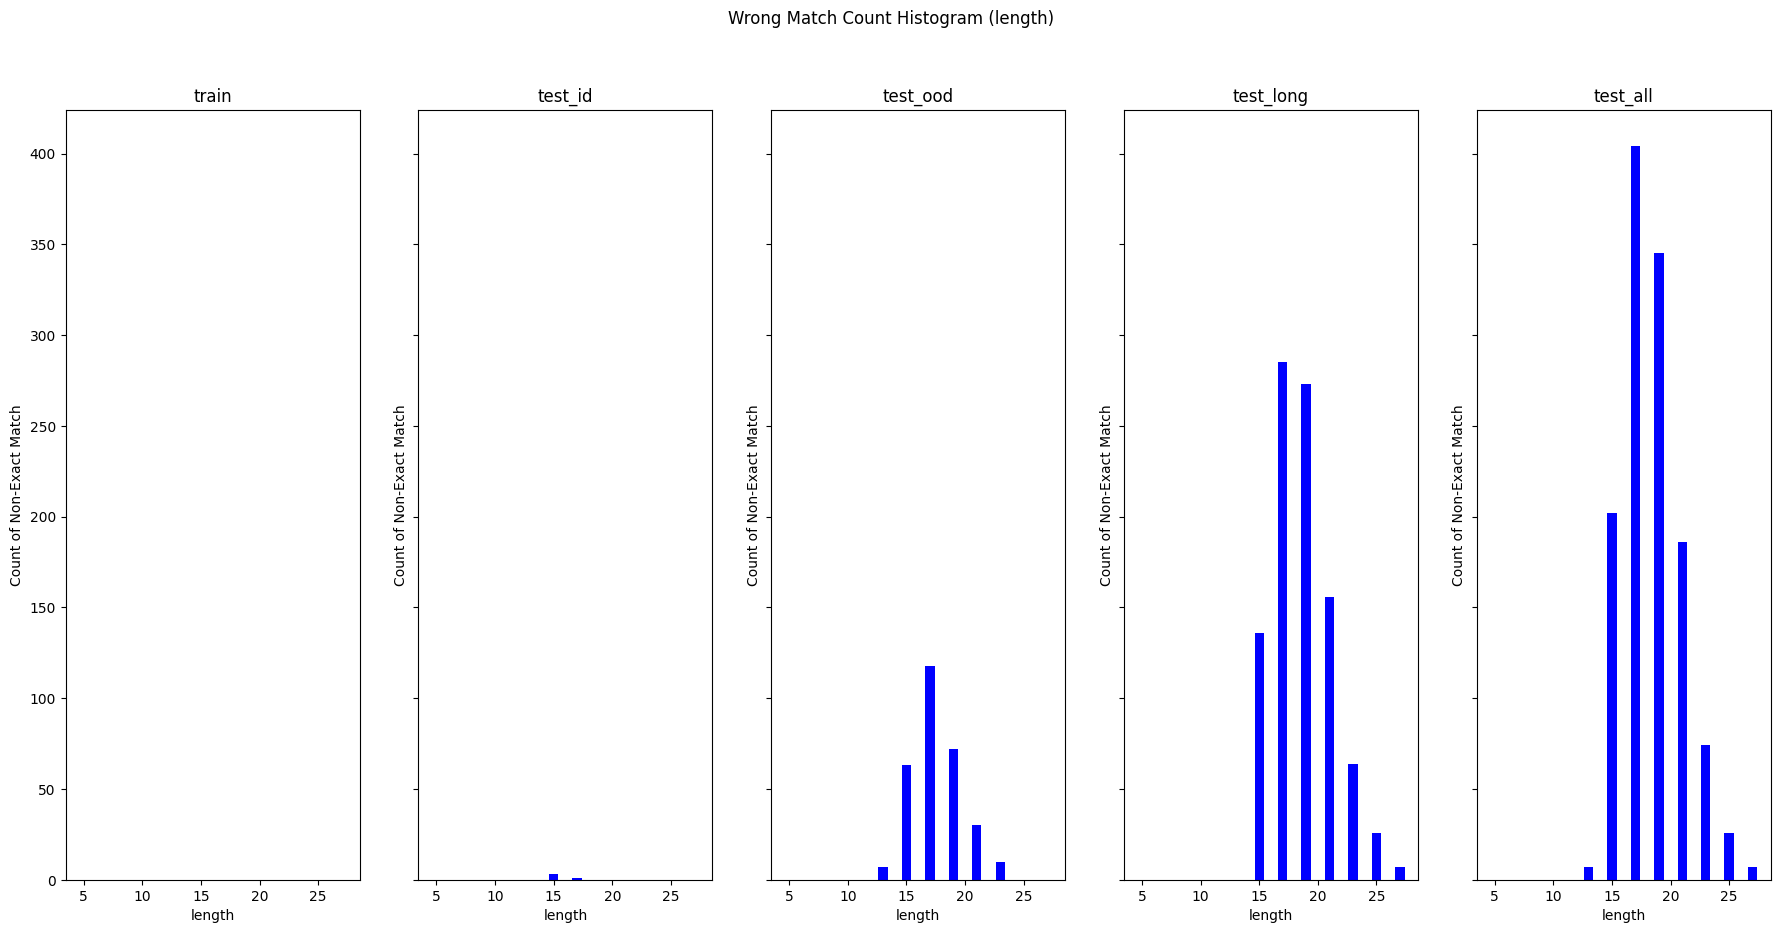

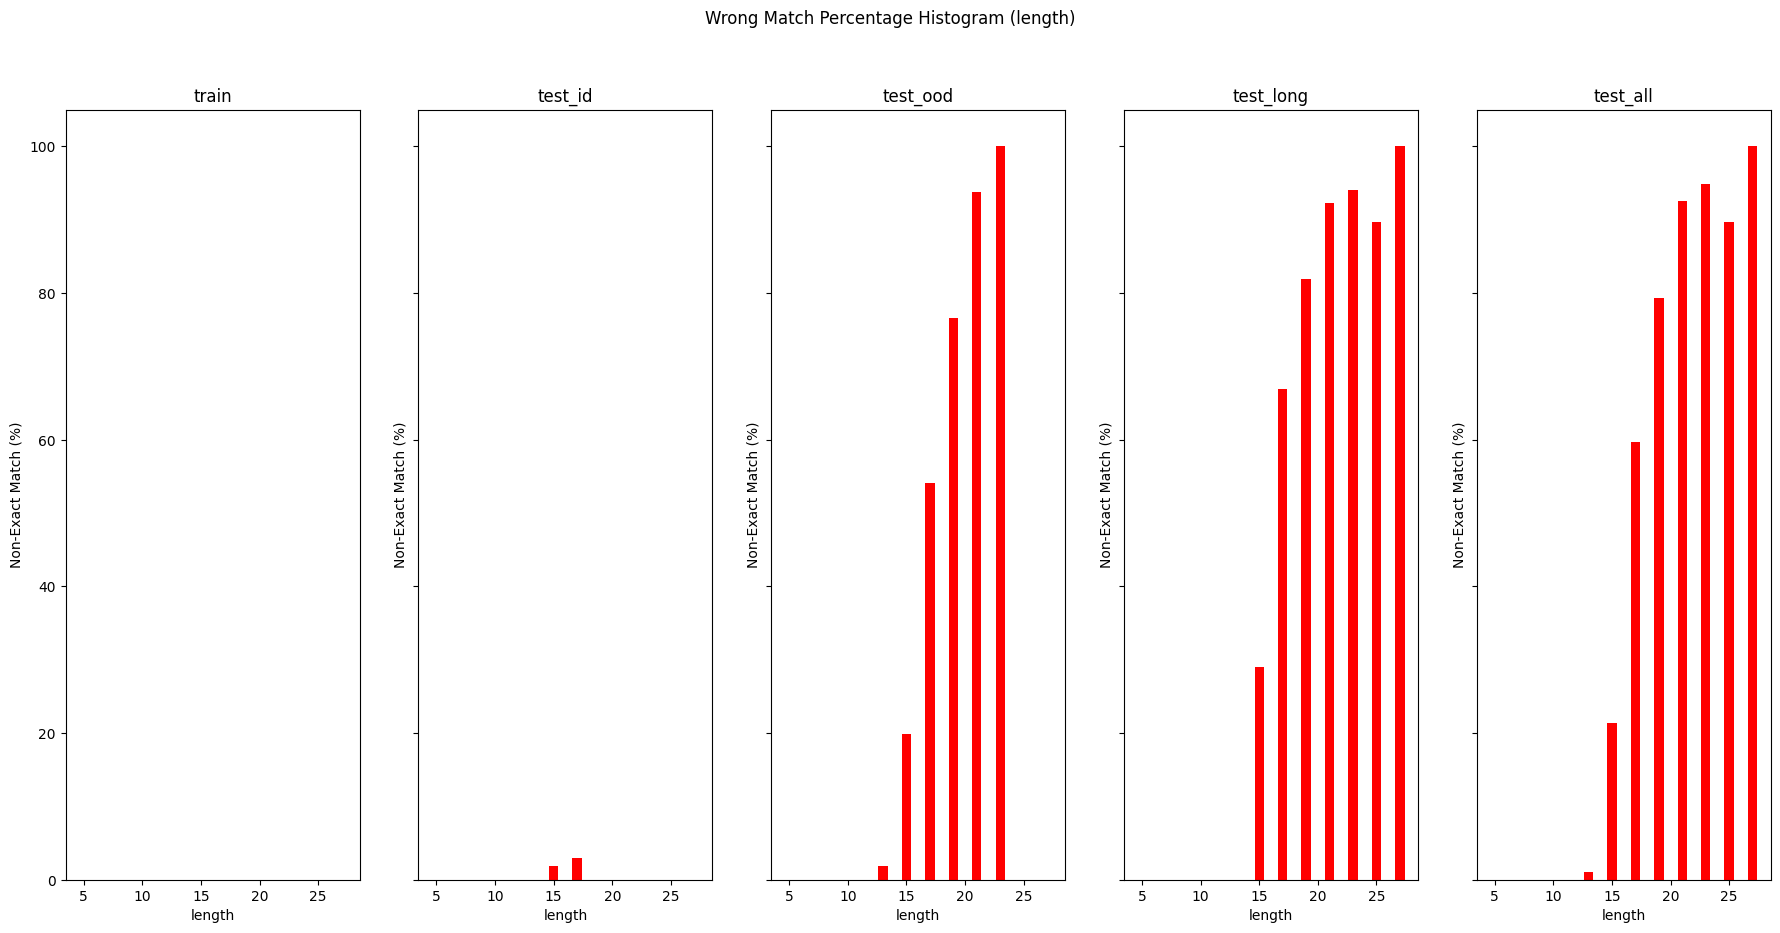

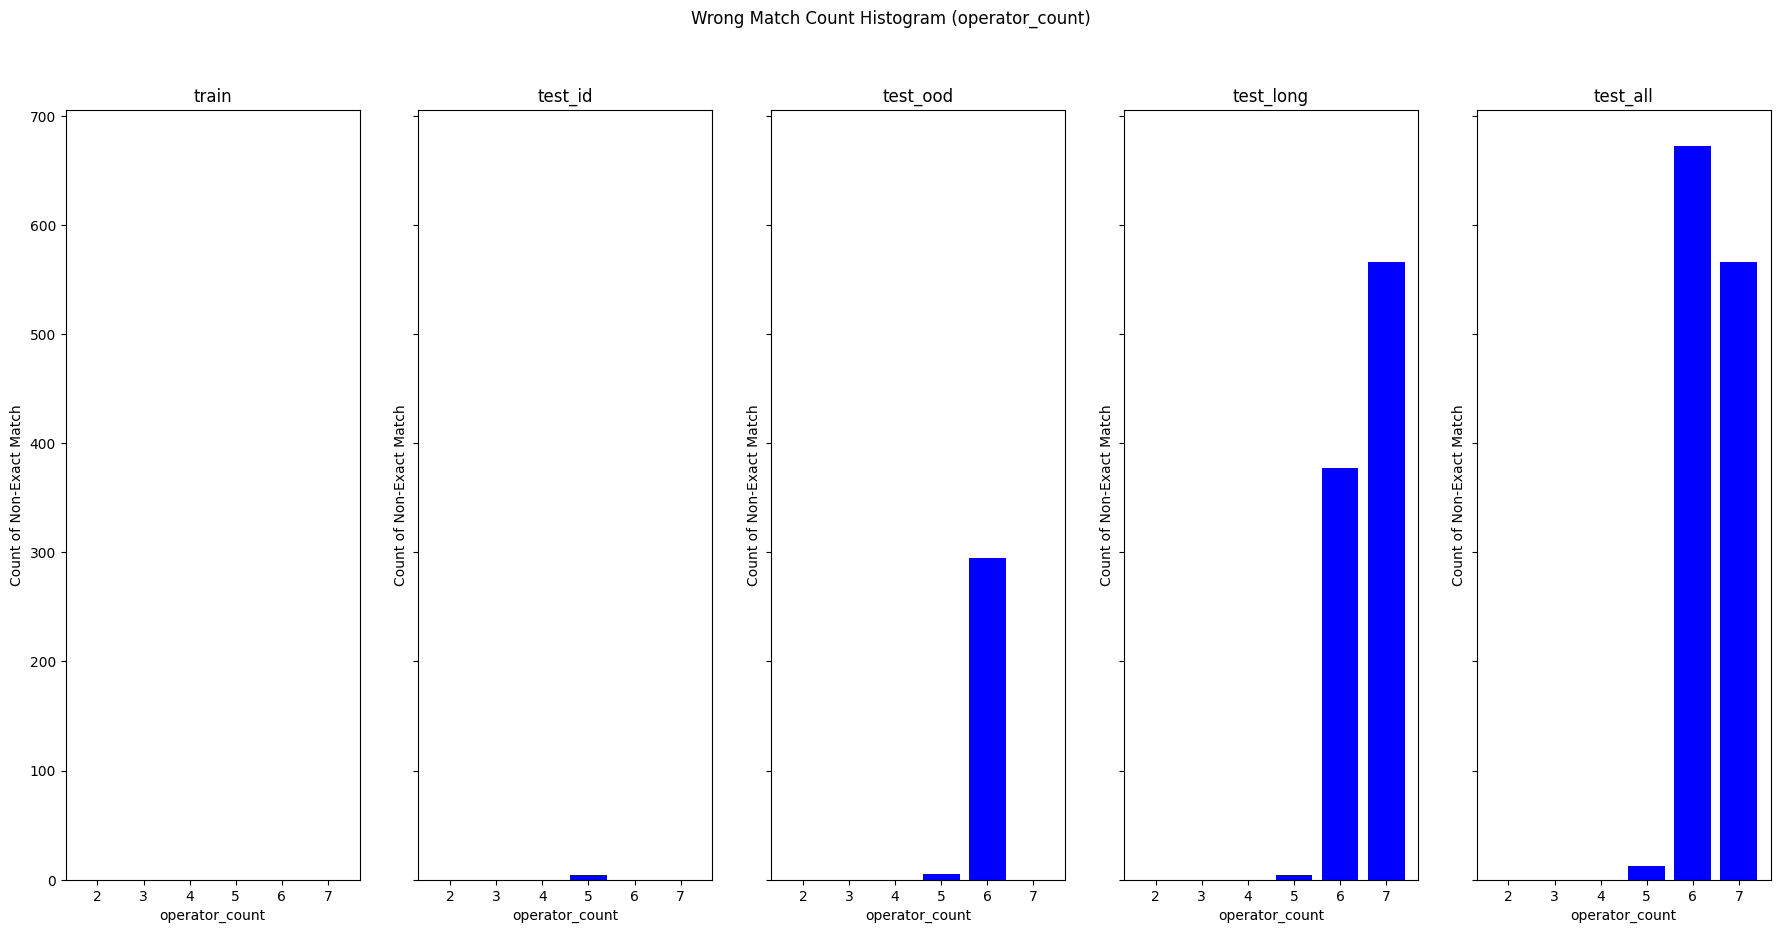

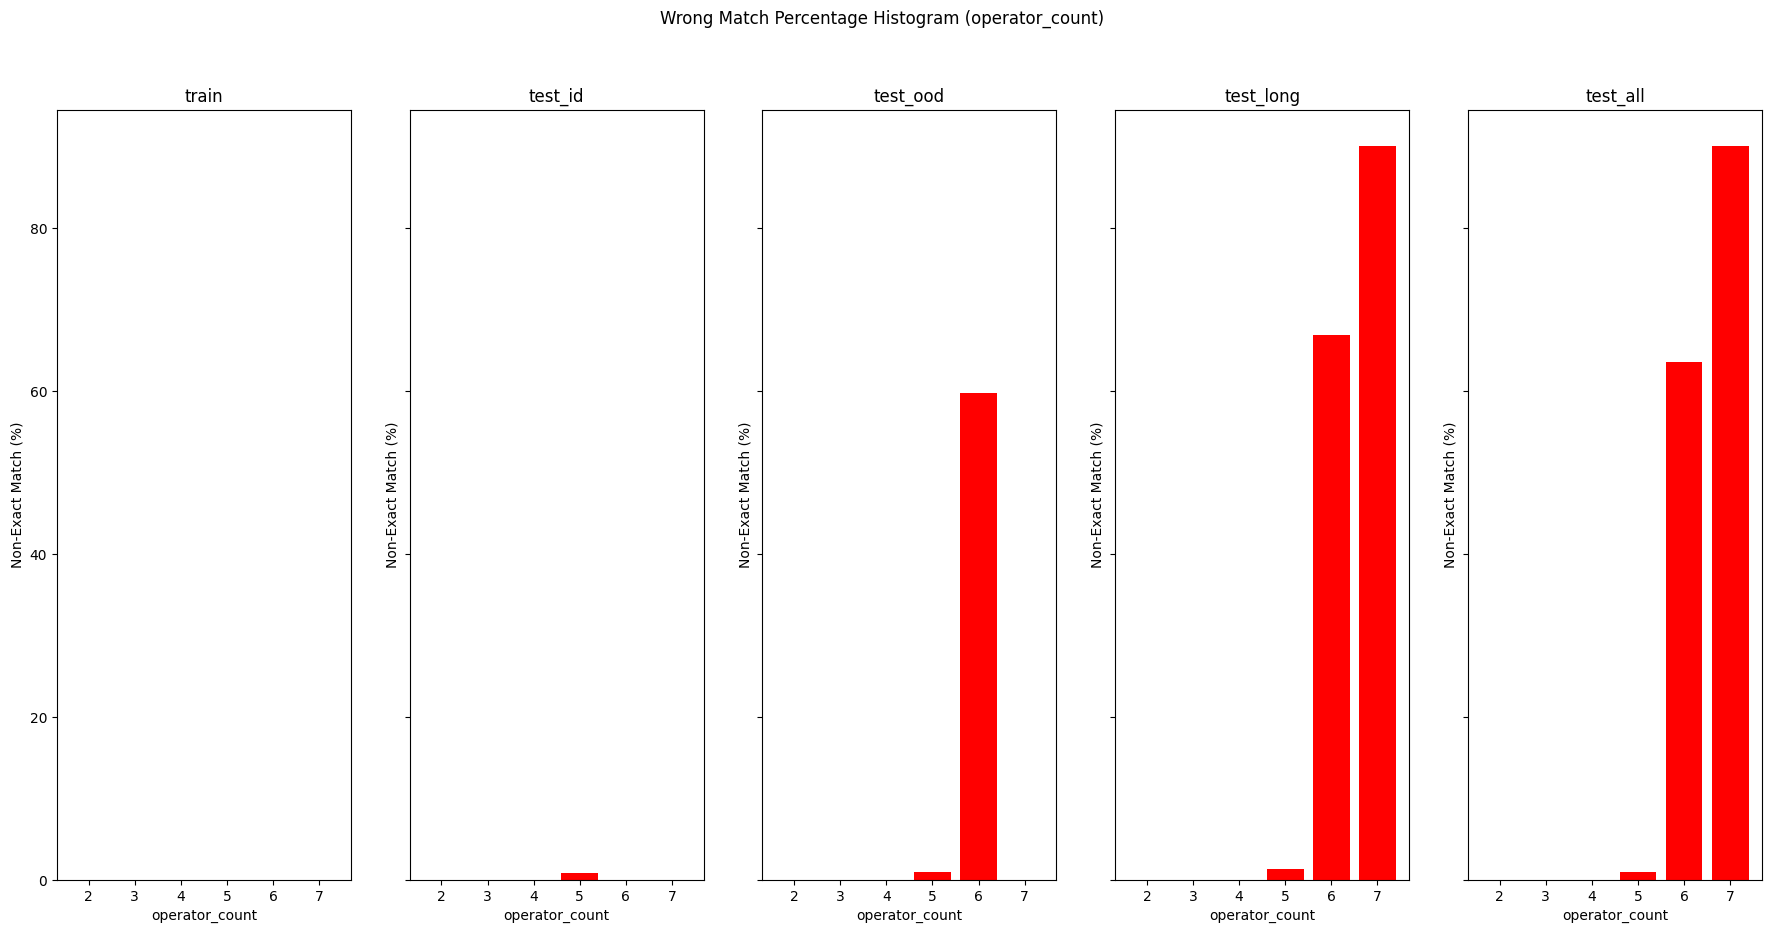

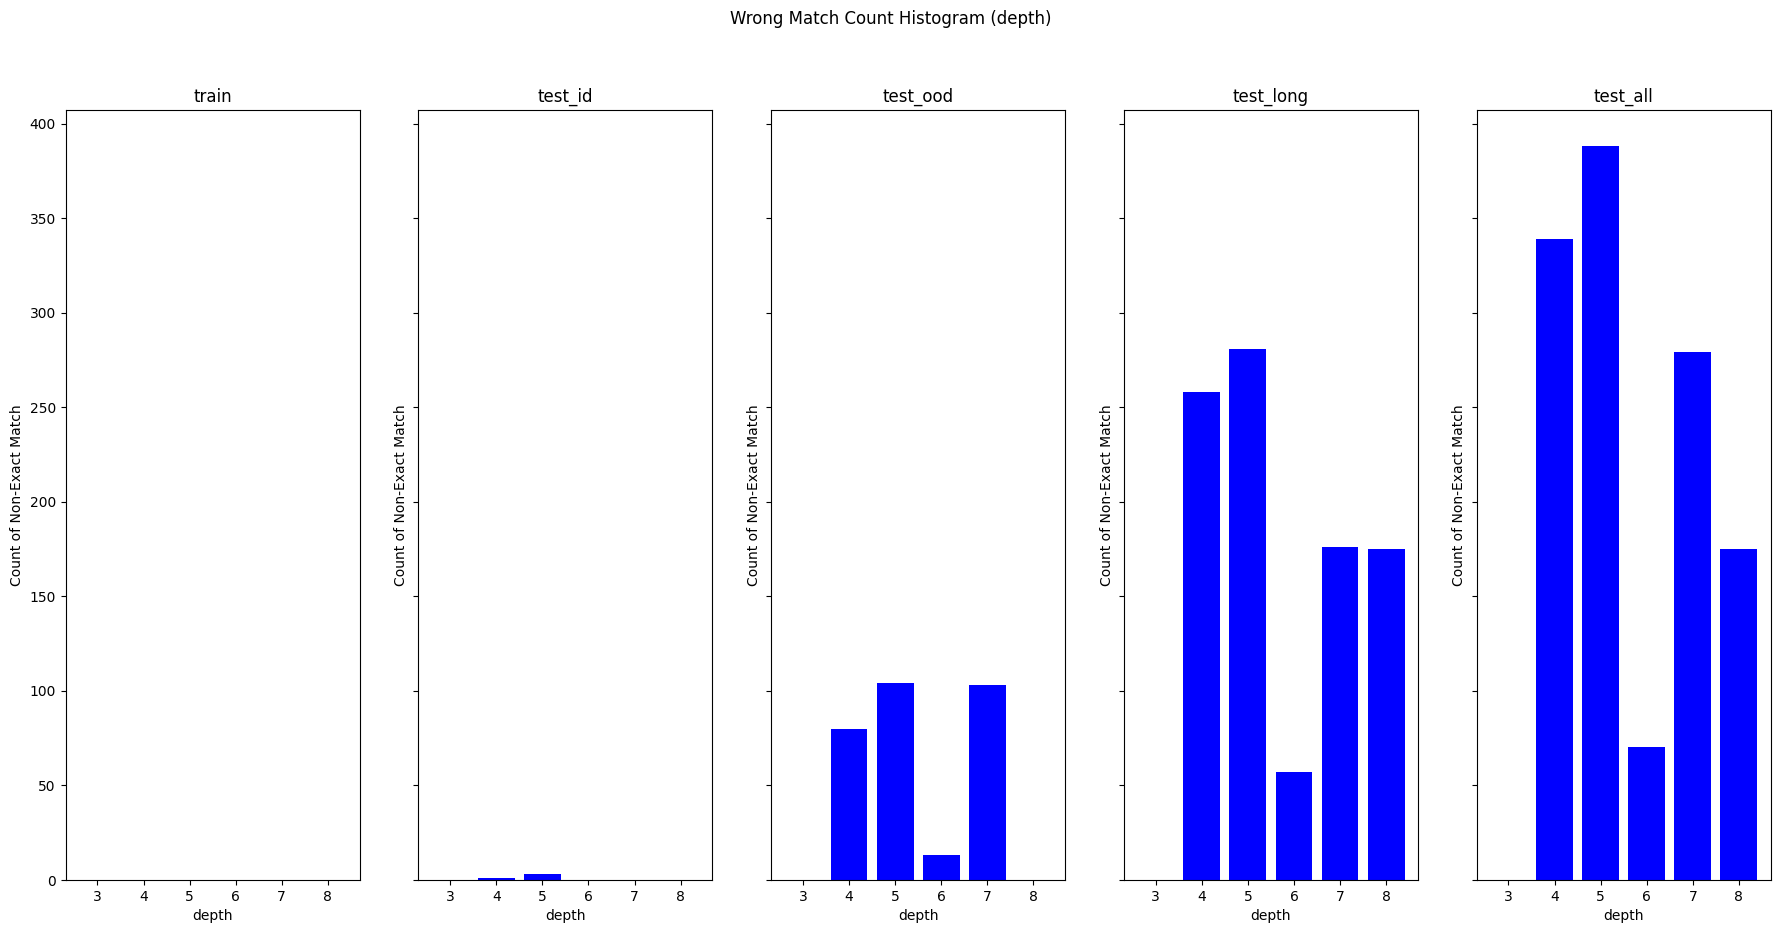

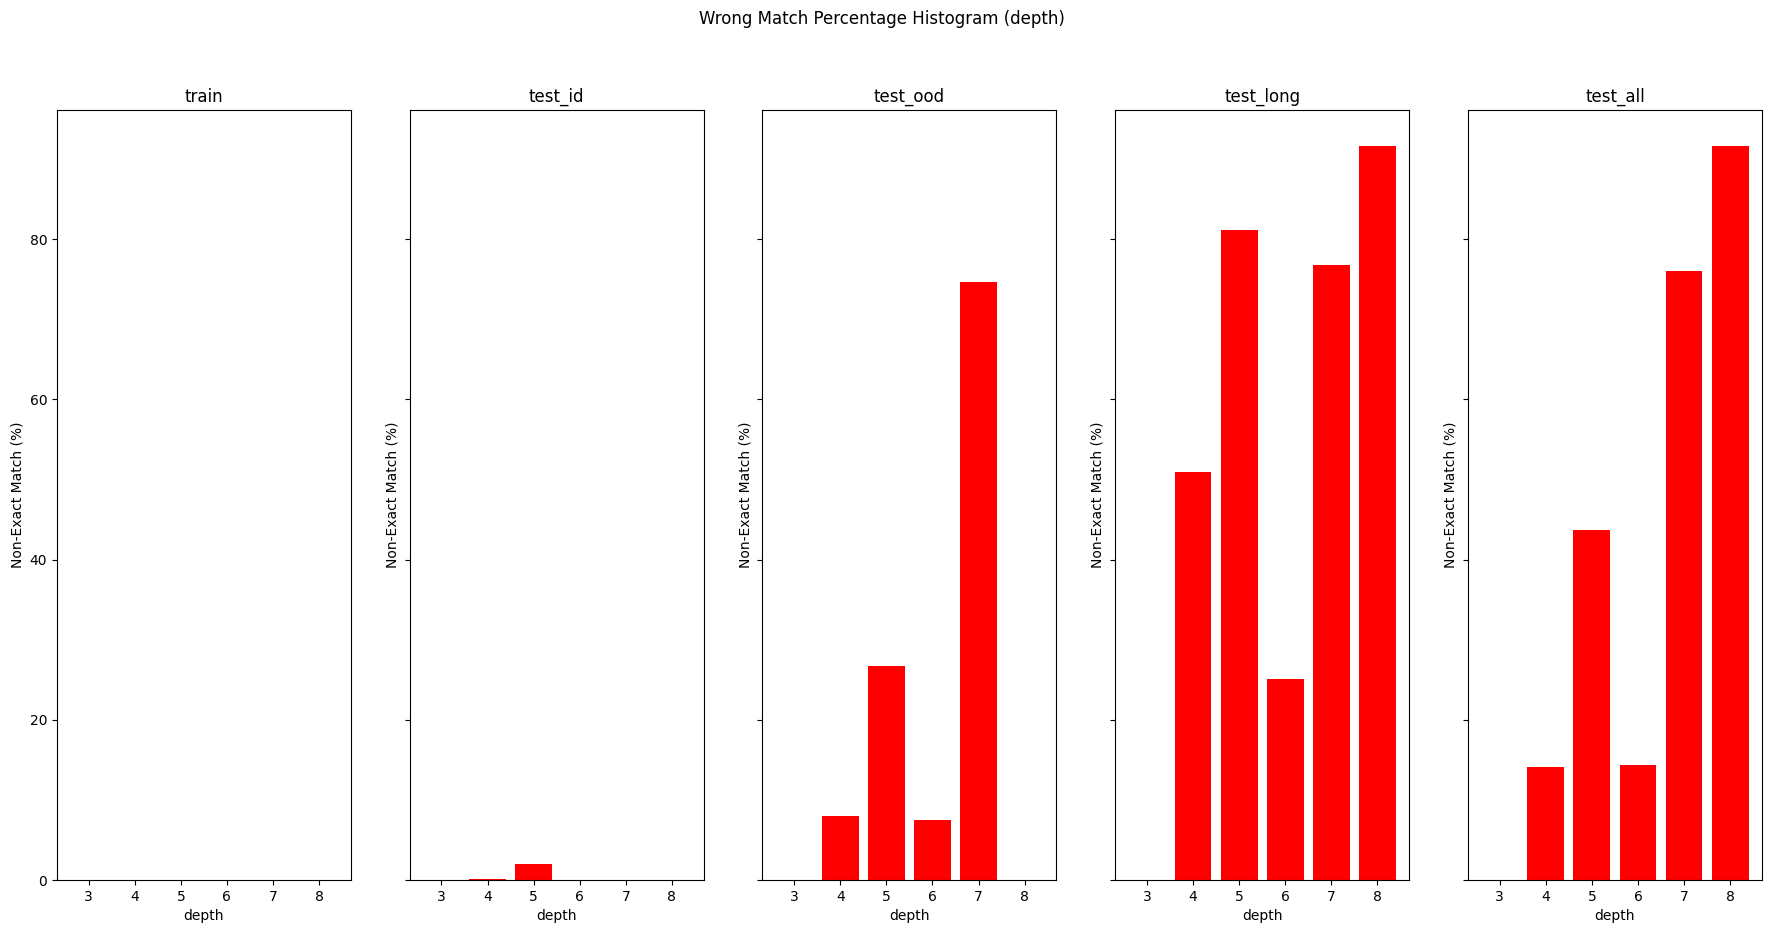

In [91]:
draw_exact_match_histogram_grid("exact_match_cnn","length",match_value=False,save_path=os.path.join(DIAGRAM_DIR,'CNN_exact_match_count_length.png'))
draw_exact_match_histogram_grid("exact_match_cnn","length",match_value=False,percentage=True,save_path=os.path.join(DIAGRAM_DIR,'CNN_exact_match_pct_length.png'))
draw_exact_match_histogram_grid("exact_match_cnn","operator_count",match_value=False,save_path=os.path.join(DIAGRAM_DIR,'CNN_exact_match_count_operator.png'))
draw_exact_match_histogram_grid("exact_match_cnn","operator_count",match_value=False,percentage=True,save_path=os.path.join(DIAGRAM_DIR,'CNN_exact_match_pct_operator.png'))
draw_exact_match_histogram_grid("exact_match_cnn","depth",match_value=False,save_path=os.path.join(DIAGRAM_DIR,'CNN_exact_match_count_depth.png'))
draw_exact_match_histogram_grid("exact_match_cnn","depth",match_value=False,percentage=True,save_path=os.path.join(DIAGRAM_DIR,'CNN_exact_match_pct_depth.png'))

#### 7.3.2 CNN Wrong Prediction Contribution

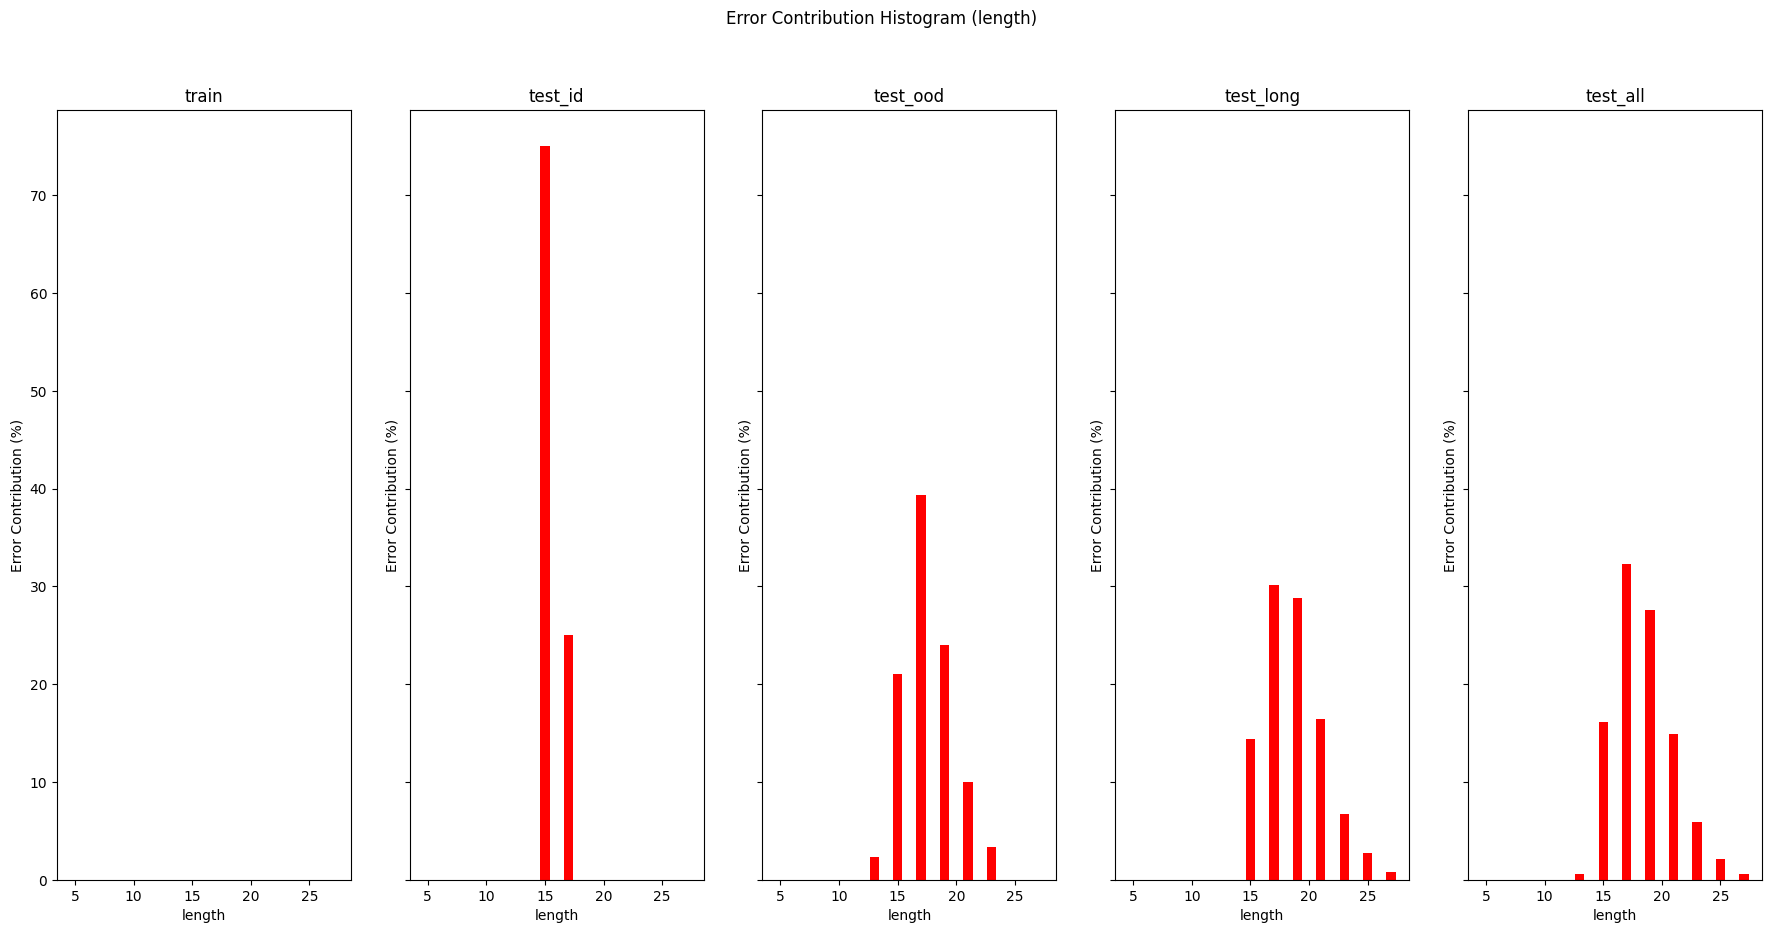

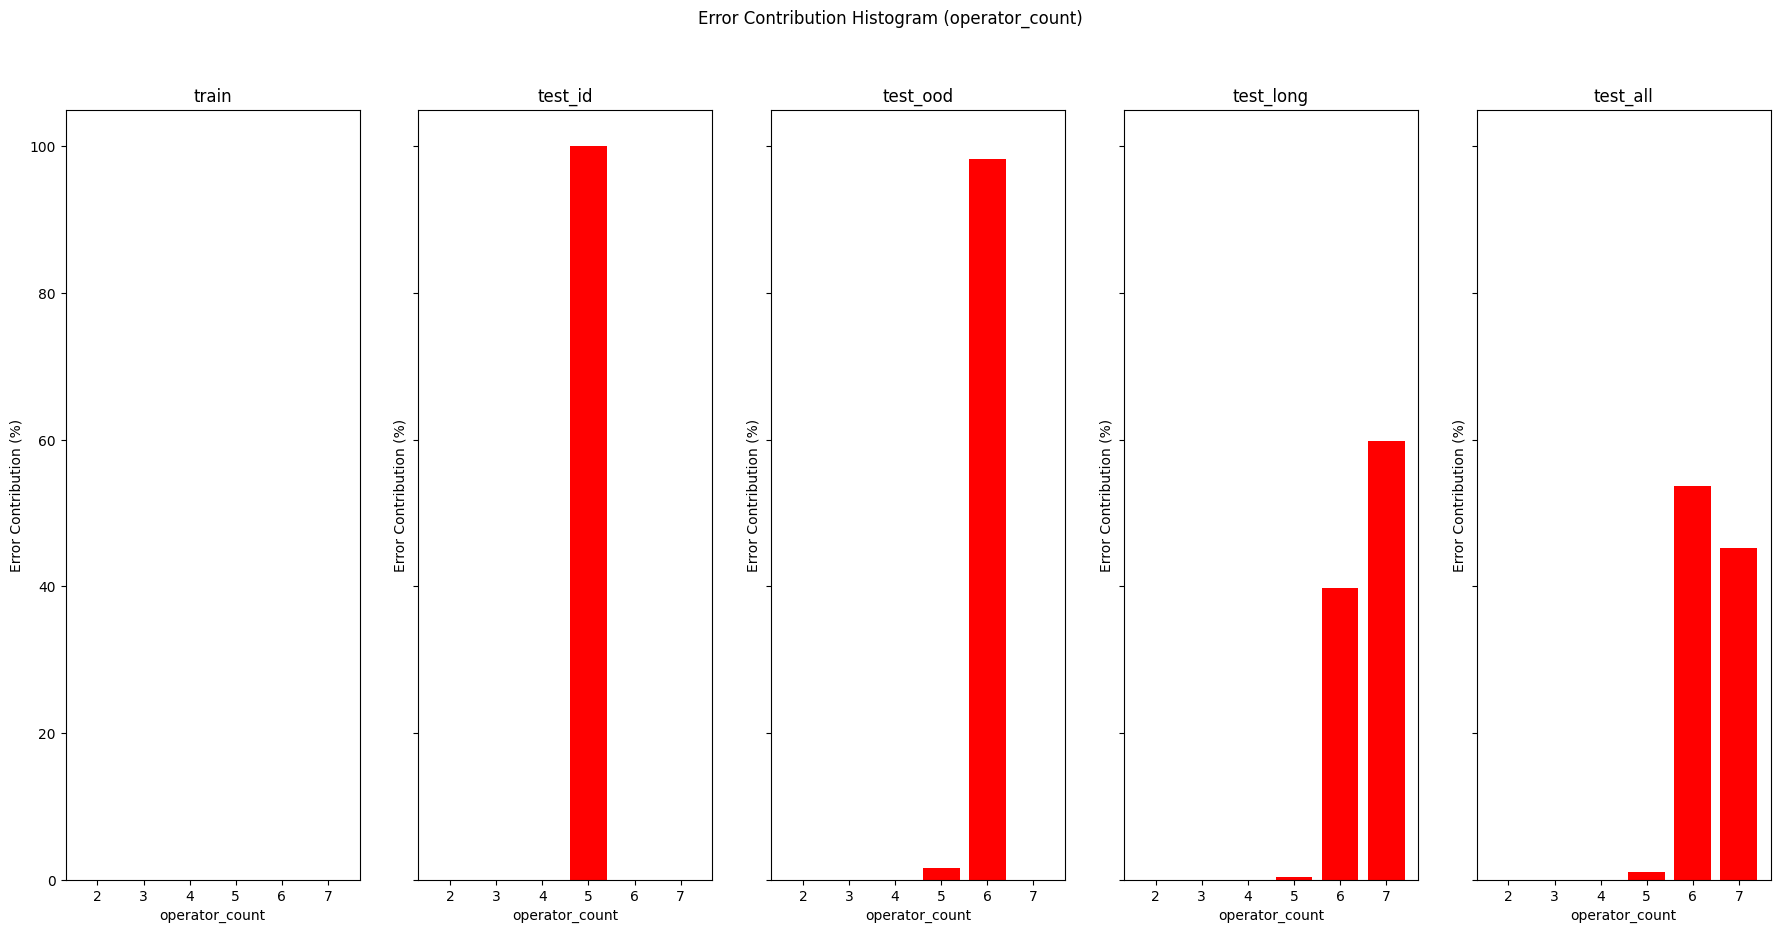

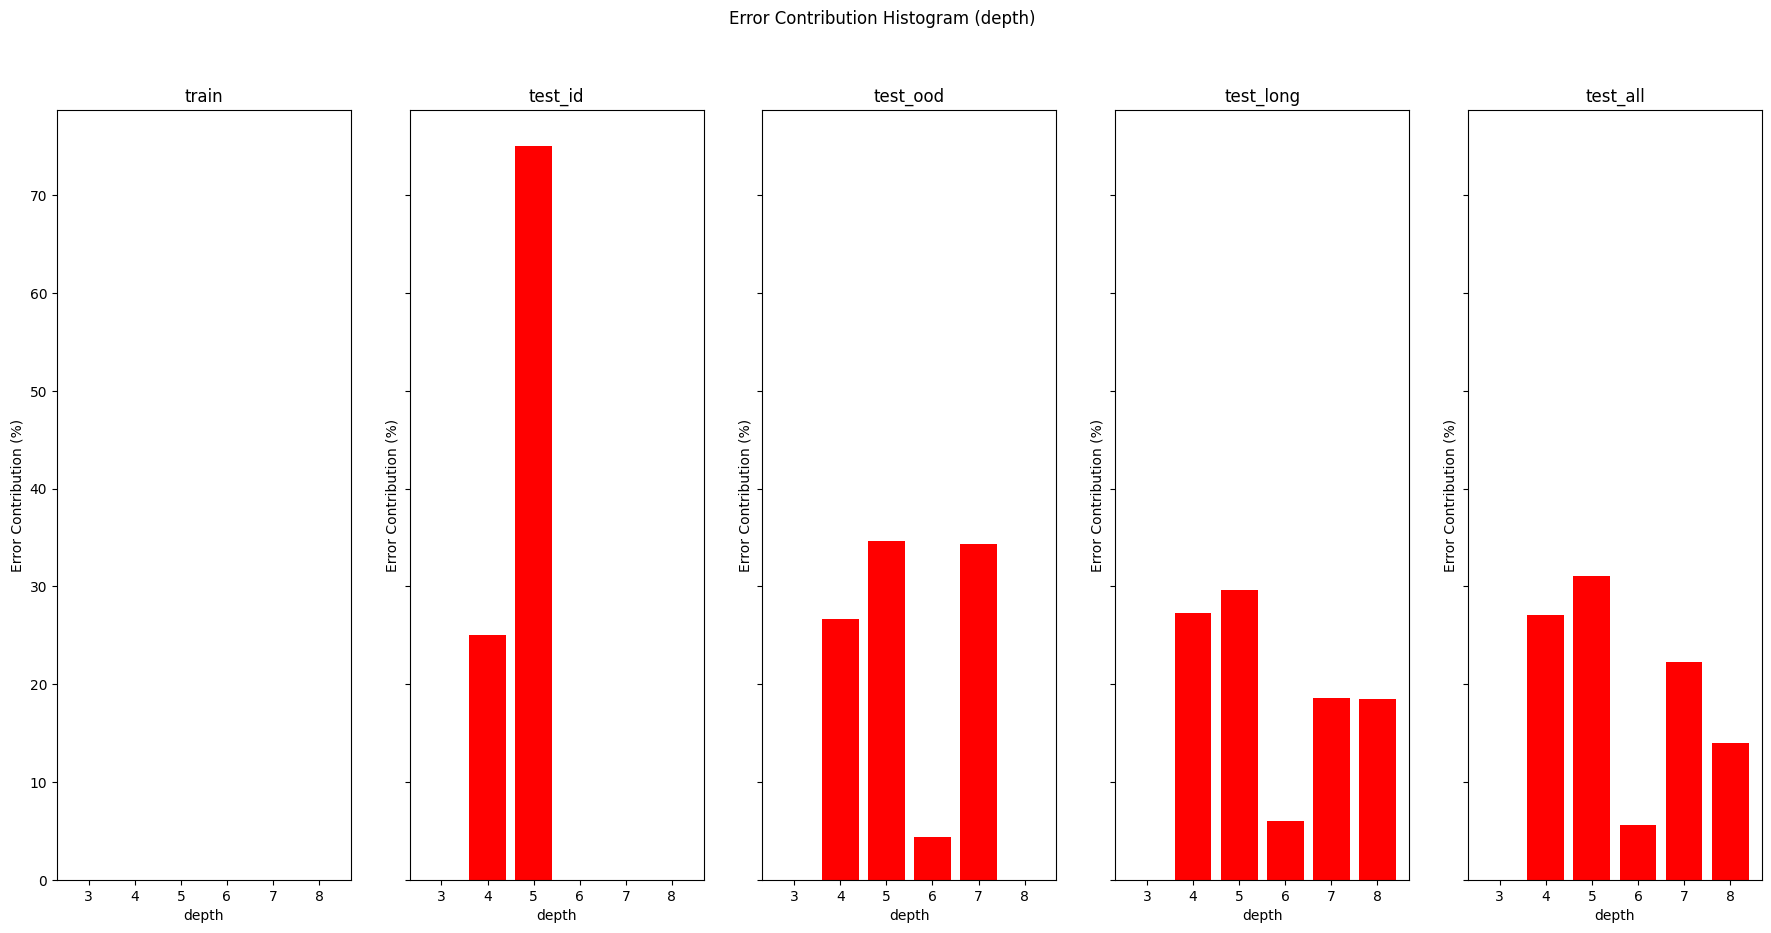

In [92]:
draw_error_contribution_grid("exact_match_cnn","length",save_path=os.path.join(DIAGRAM_DIR,'CNN_error_contrib_length.png'))
draw_error_contribution_grid("exact_match_cnn","operator_count",save_path=os.path.join(DIAGRAM_DIR,'CNN_error_contrib_operator.png'))
draw_error_contribution_grid("exact_match_cnn","depth",save_path=os.path.join(DIAGRAM_DIR,'CNN_error_contrib_depth.png'))

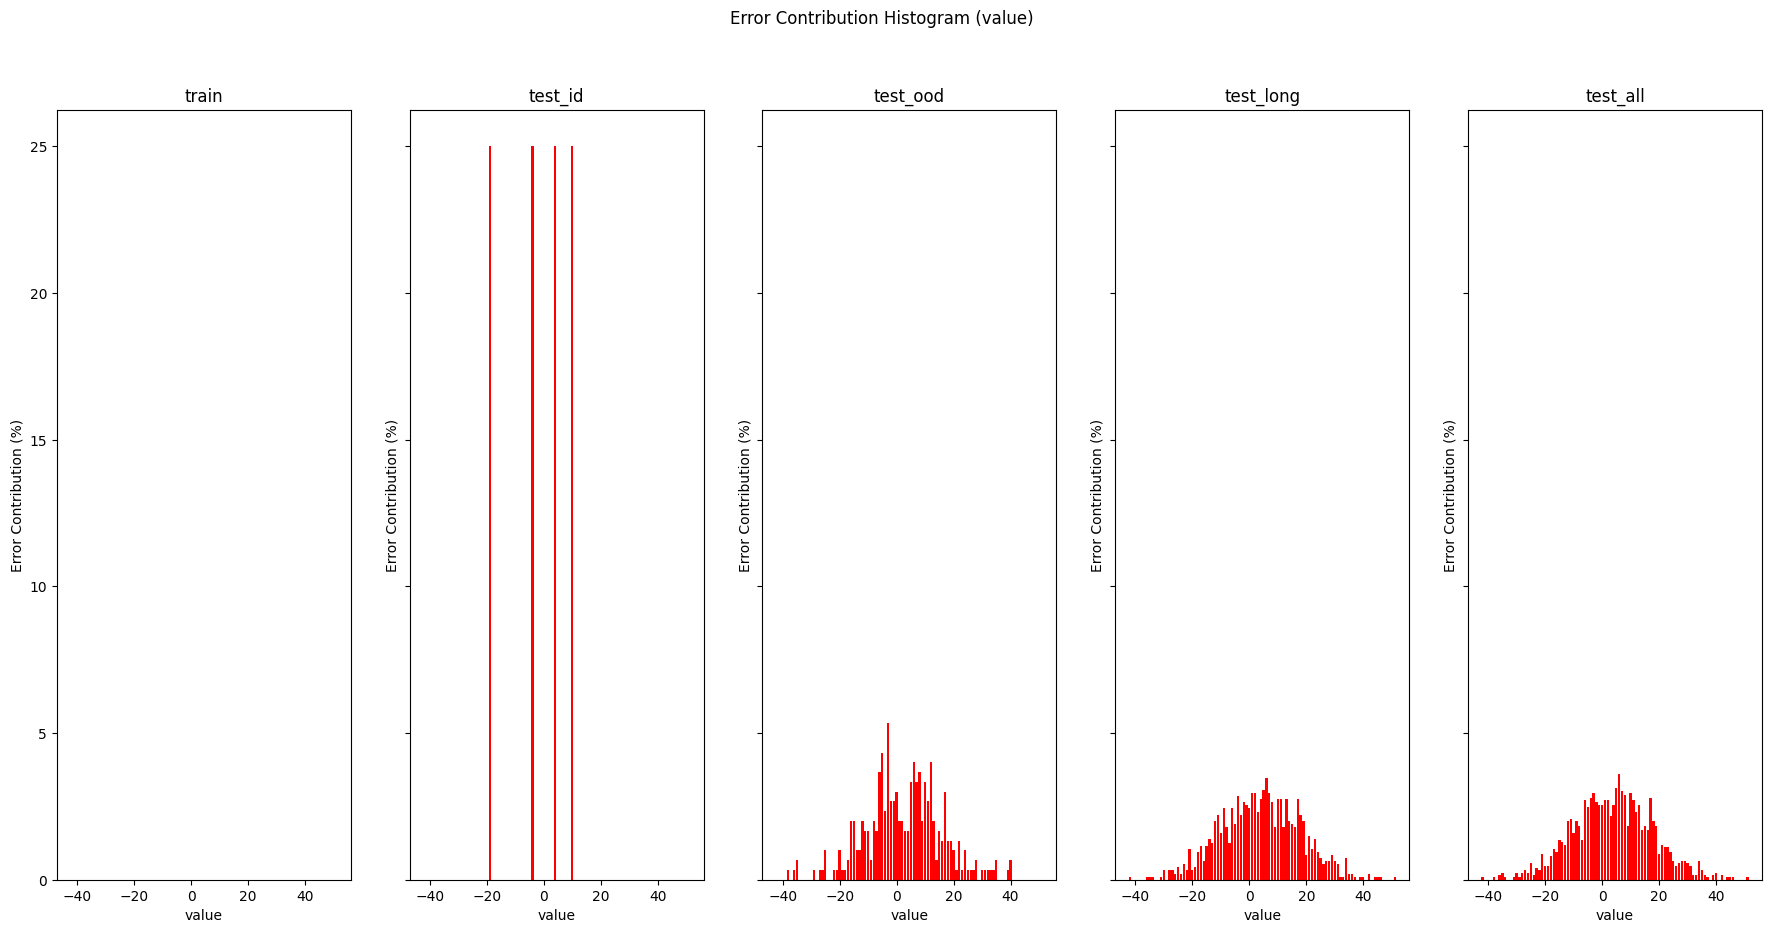

In [93]:
draw_error_contribution_grid("exact_match_cnn", "value", save_path=os.path.join(DIAGRAM_DIR,'CNN_error_contrib_value.png'))

### 7.4 Transformer Wrong Match Analysis

#### 7.4.1 Transformer Wrong Predictions

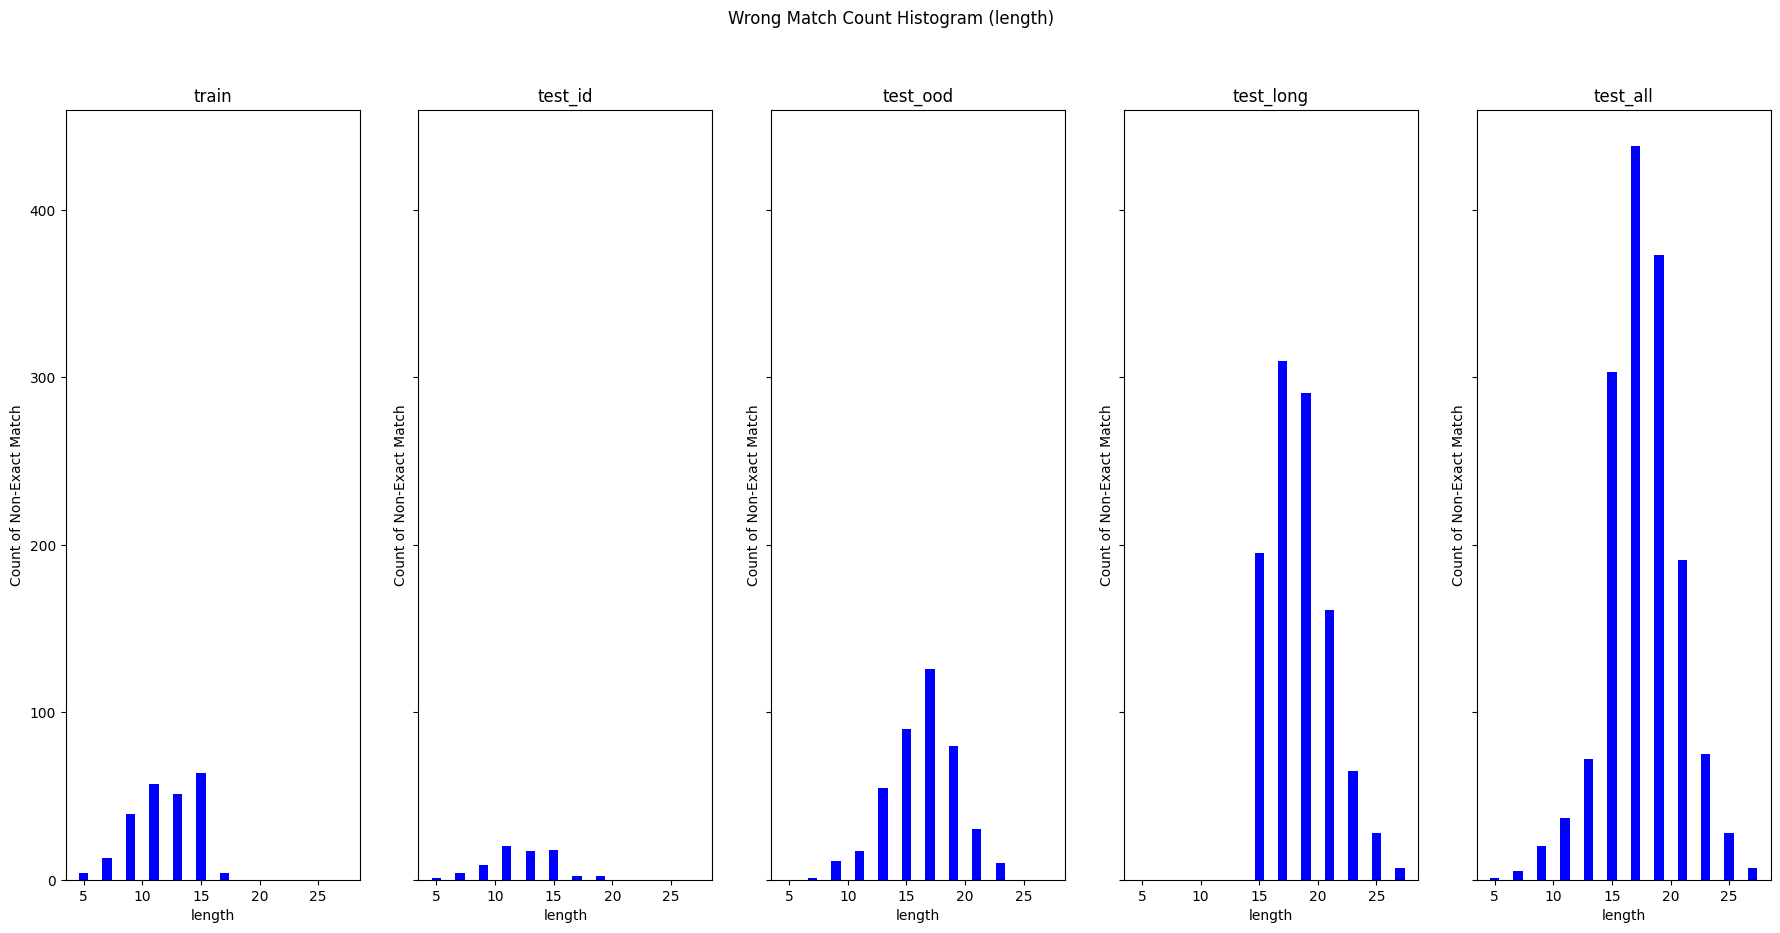

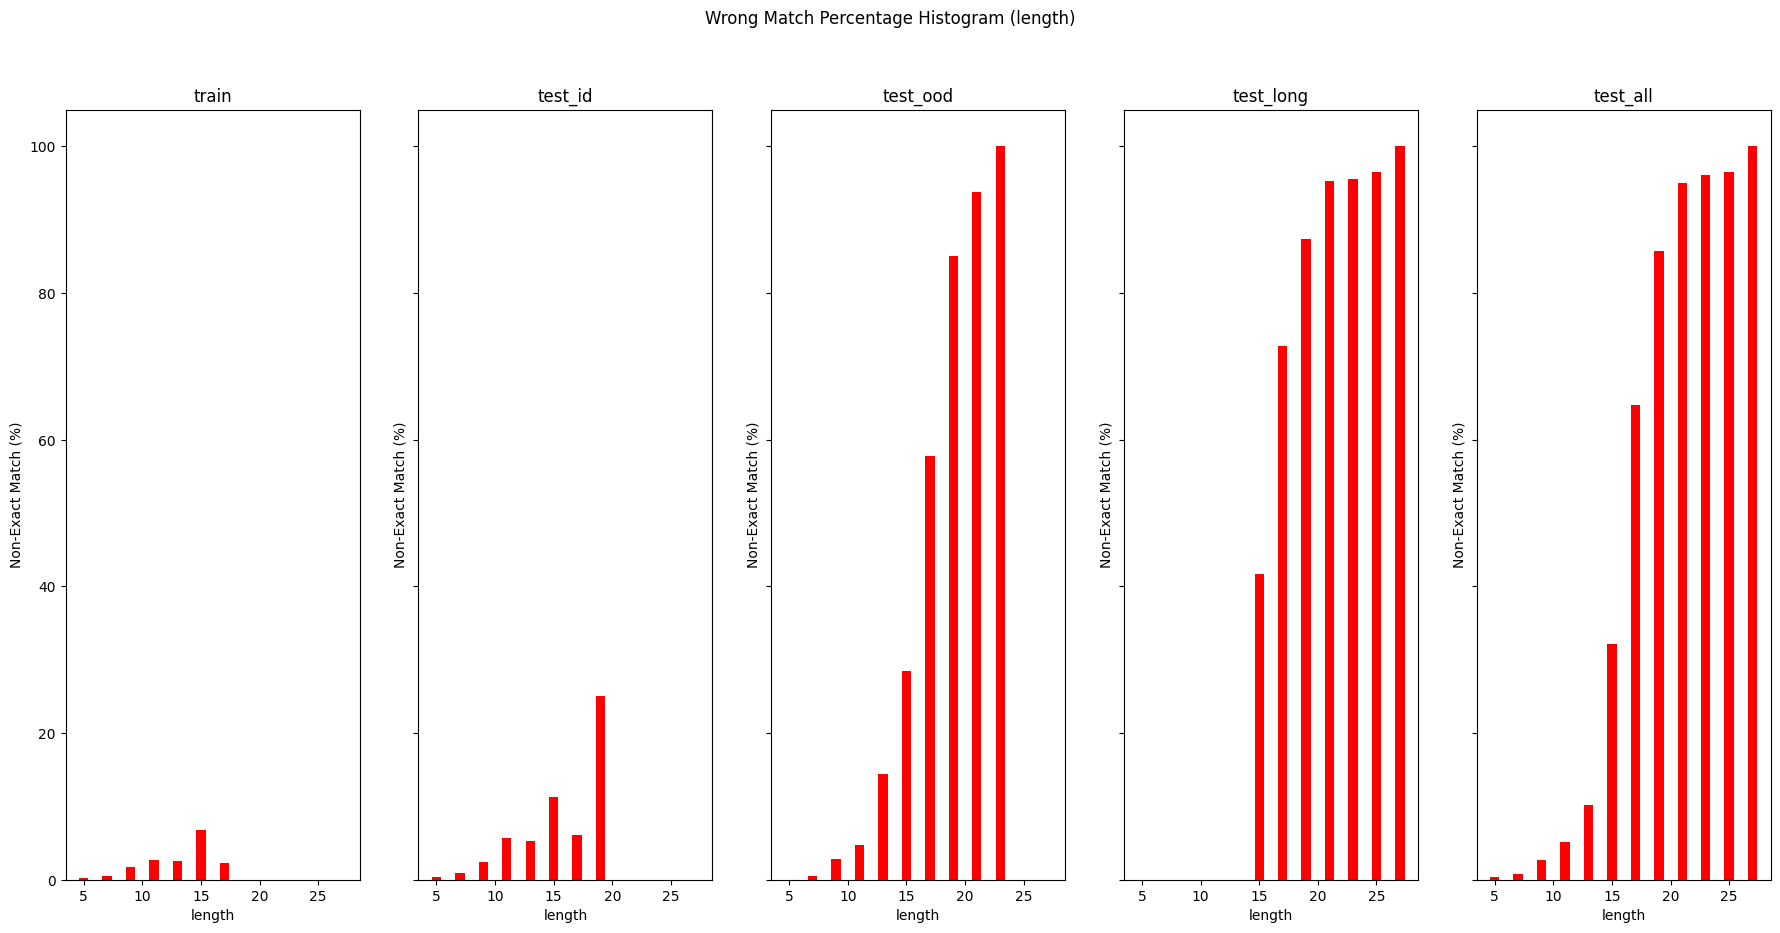

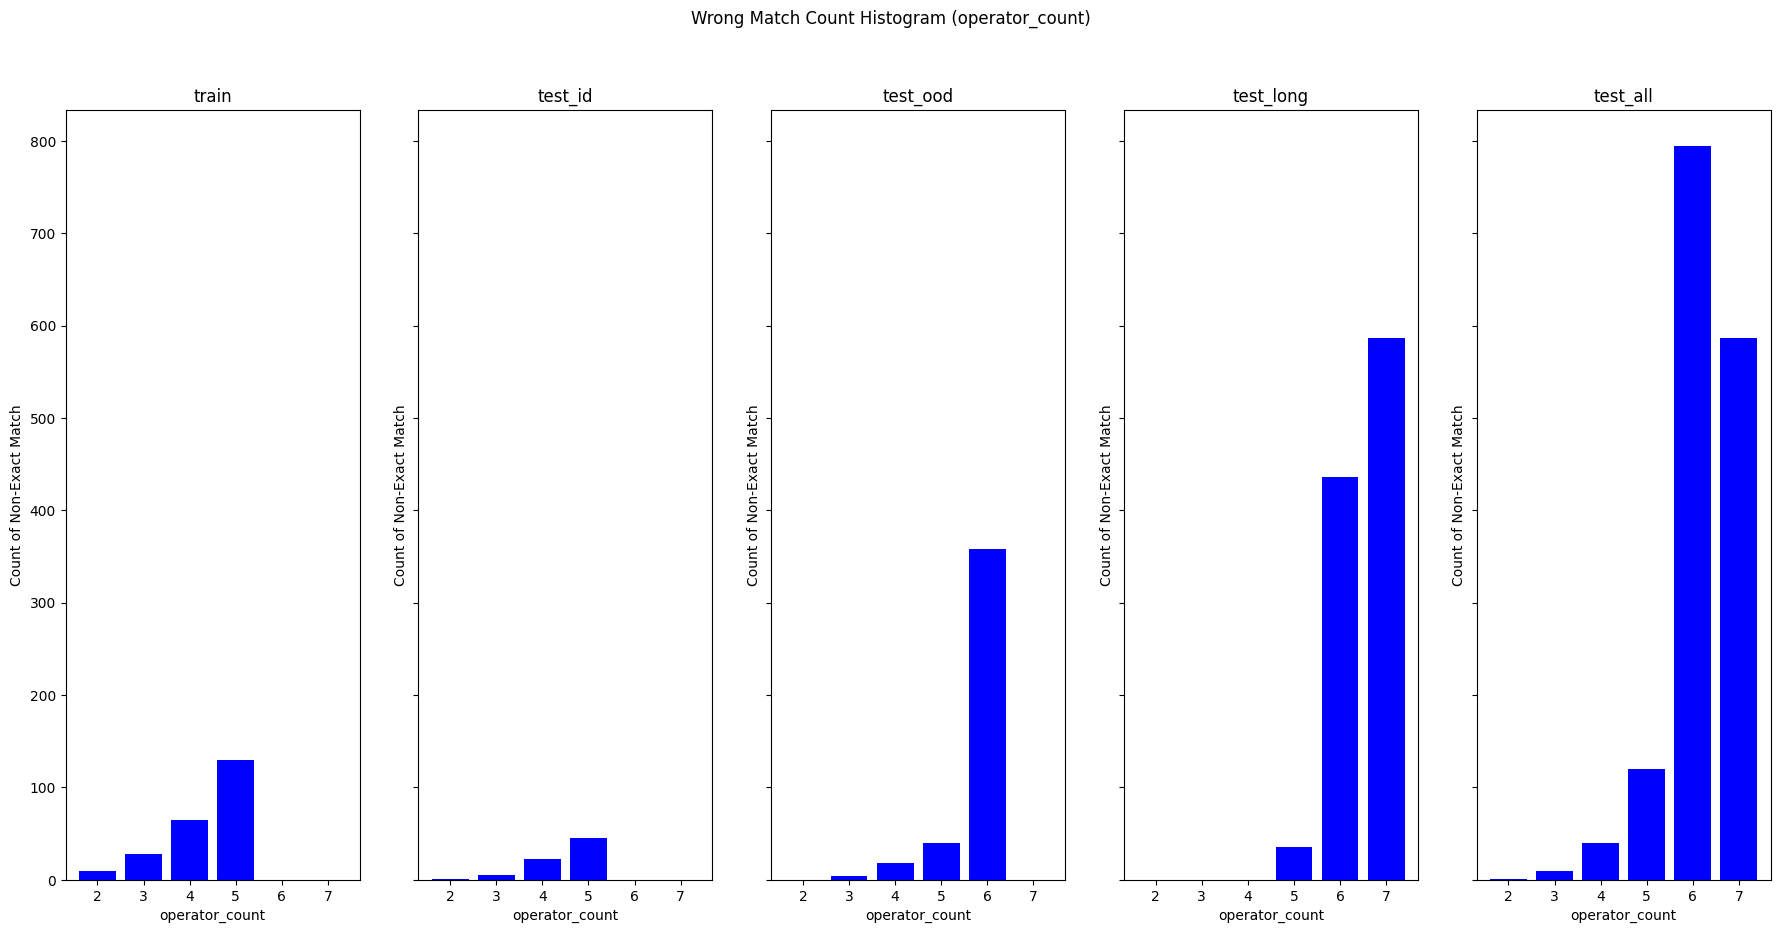

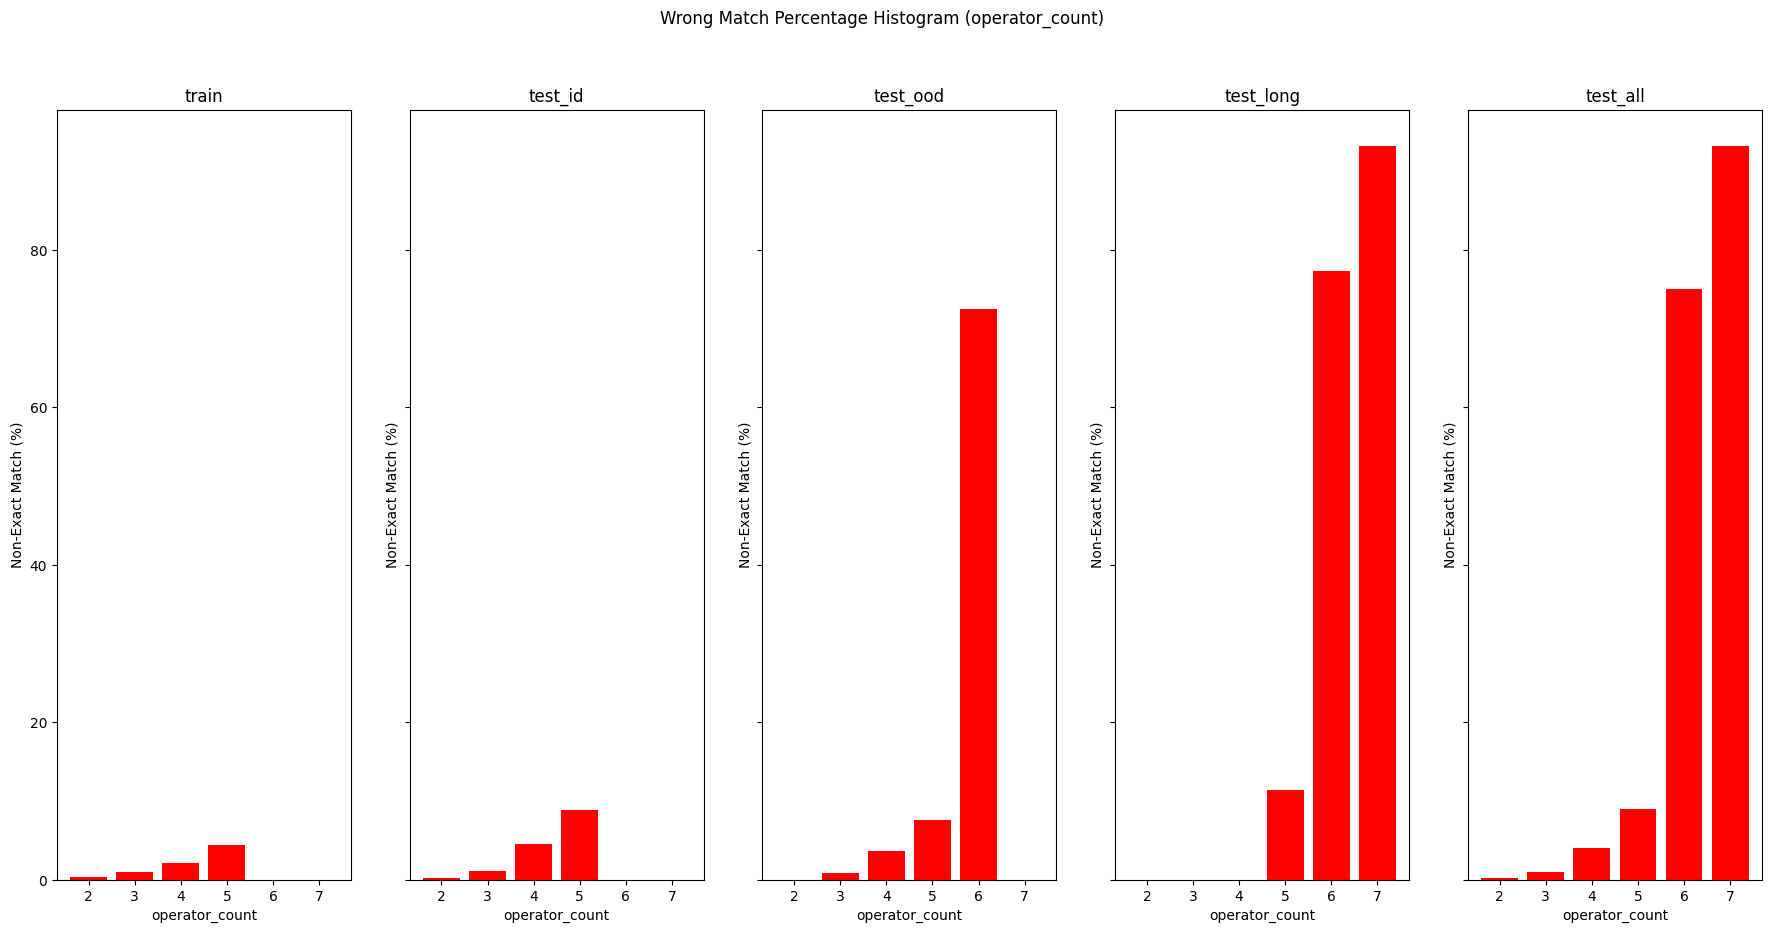

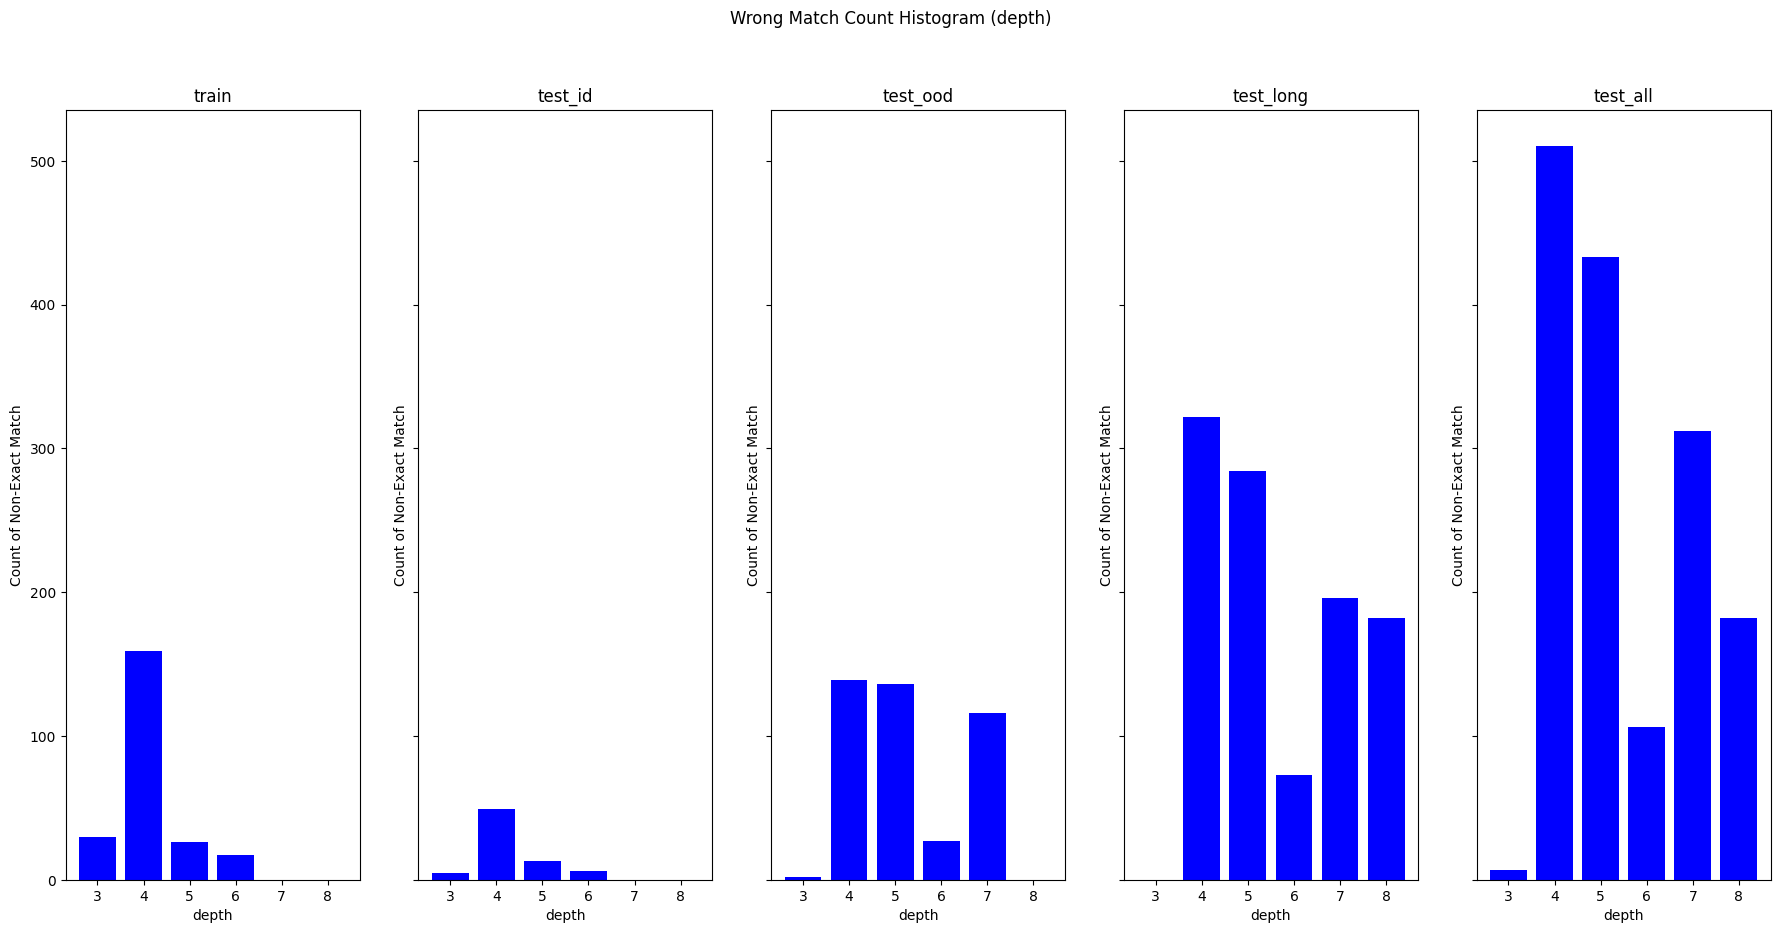

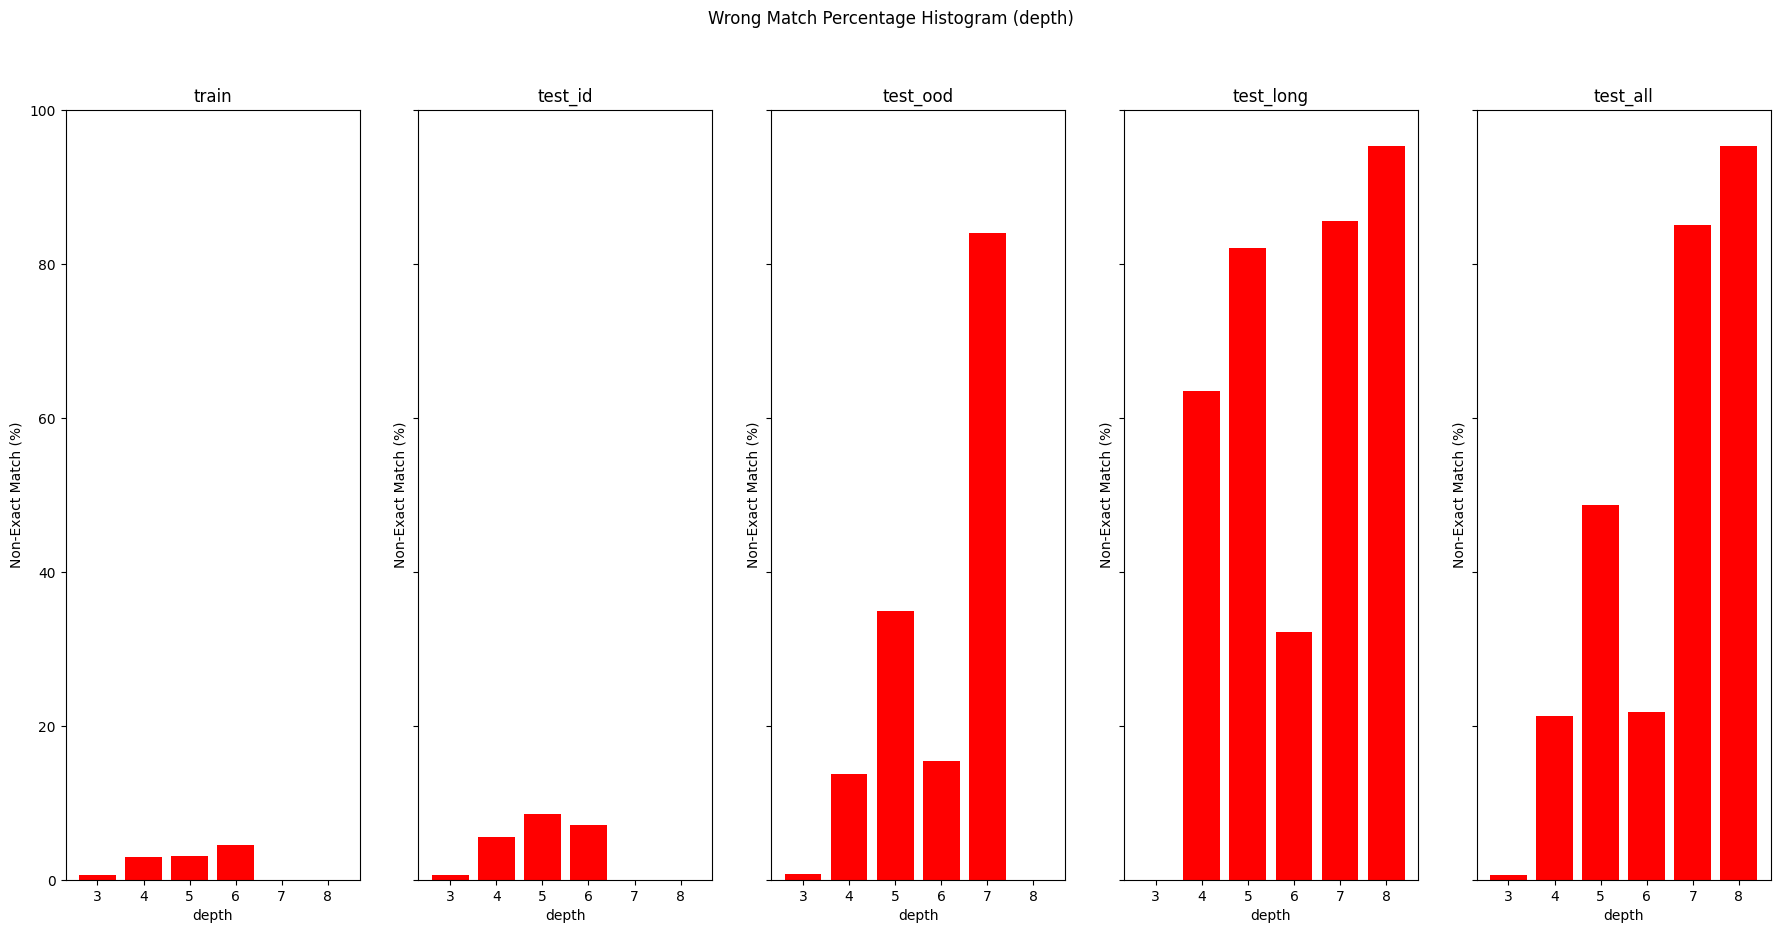

In [94]:
draw_exact_match_histogram_grid("exact_match_transformer","length",match_value=False,save_path=os.path.join(DIAGRAM_DIR,'T_exact_match_count_length.png'))
draw_exact_match_histogram_grid("exact_match_transformer","length",match_value=False,percentage=True,save_path=os.path.join(DIAGRAM_DIR,'T_exact_match_pct_length.png'))
draw_exact_match_histogram_grid("exact_match_transformer","operator_count",match_value=False,save_path=os.path.join(DIAGRAM_DIR,'T_exact_match_count_operator.png'))
draw_exact_match_histogram_grid("exact_match_transformer","operator_count",match_value=False,percentage=True,save_path=os.path.join(DIAGRAM_DIR,'T_exact_match_pct_operator.png'))
draw_exact_match_histogram_grid("exact_match_transformer","depth",match_value=False,save_path=os.path.join(DIAGRAM_DIR,'T_exact_match_count_depth.png'))
draw_exact_match_histogram_grid("exact_match_transformer","depth",match_value=False,percentage=True,save_path=os.path.join(DIAGRAM_DIR,'T_exact_match_pct_depth.png'))

#### 7.4.2 Transformer Wrong Match Contribution

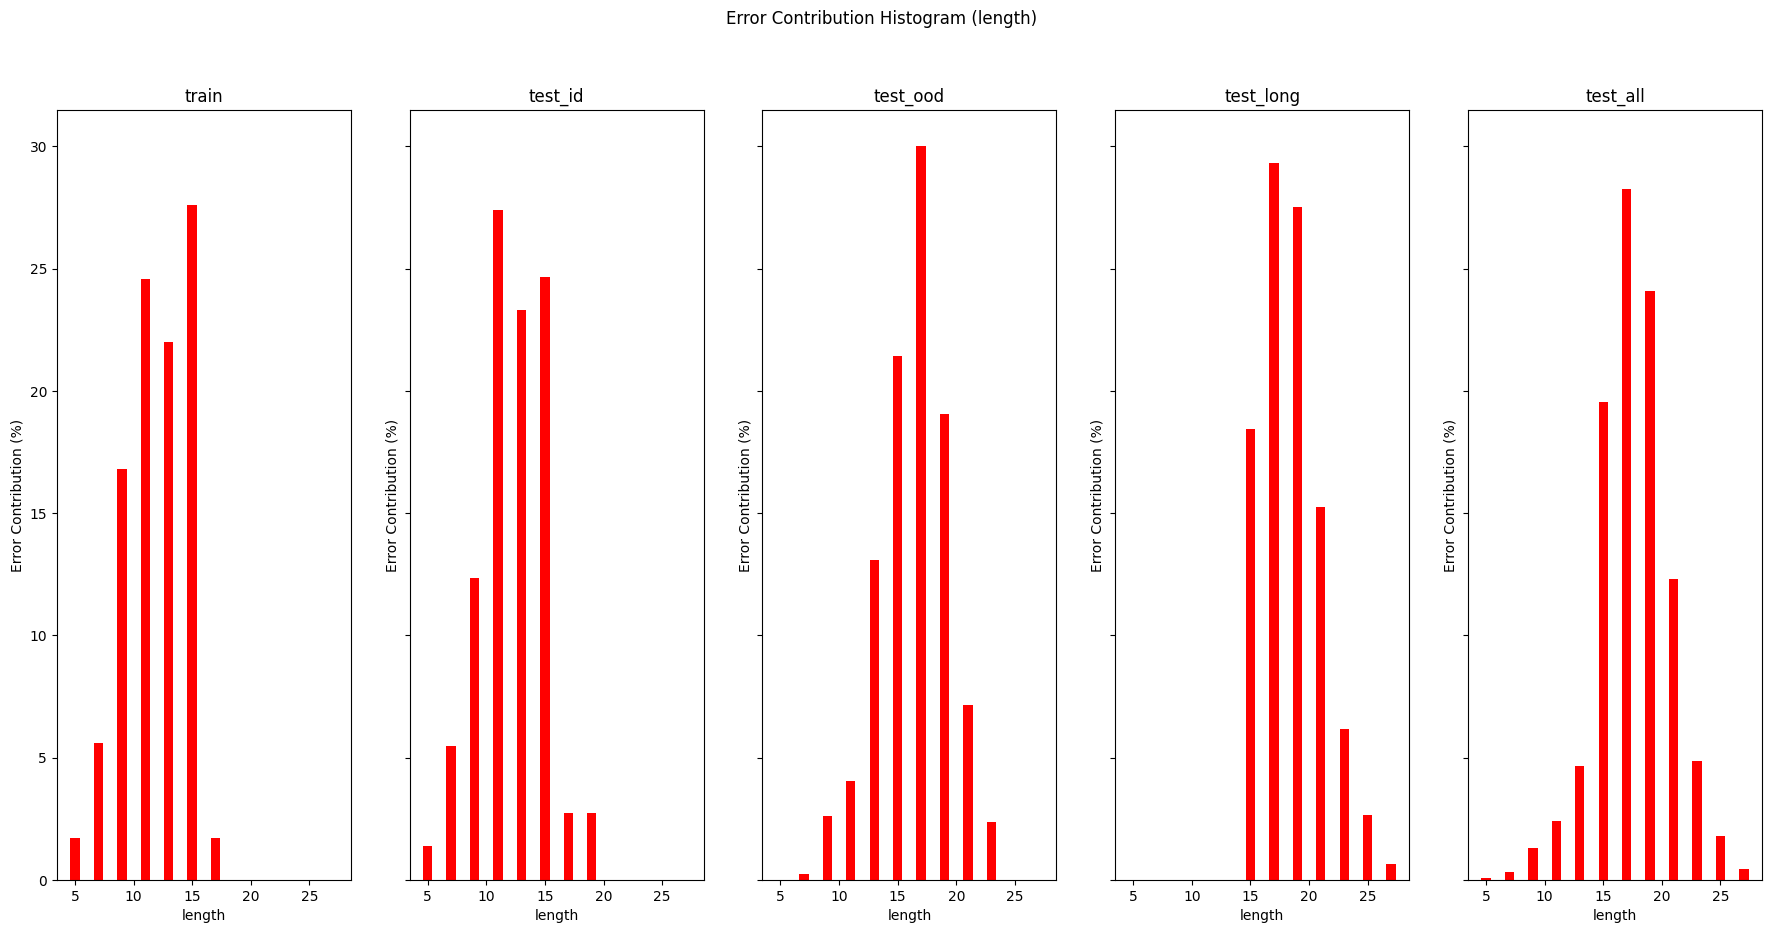

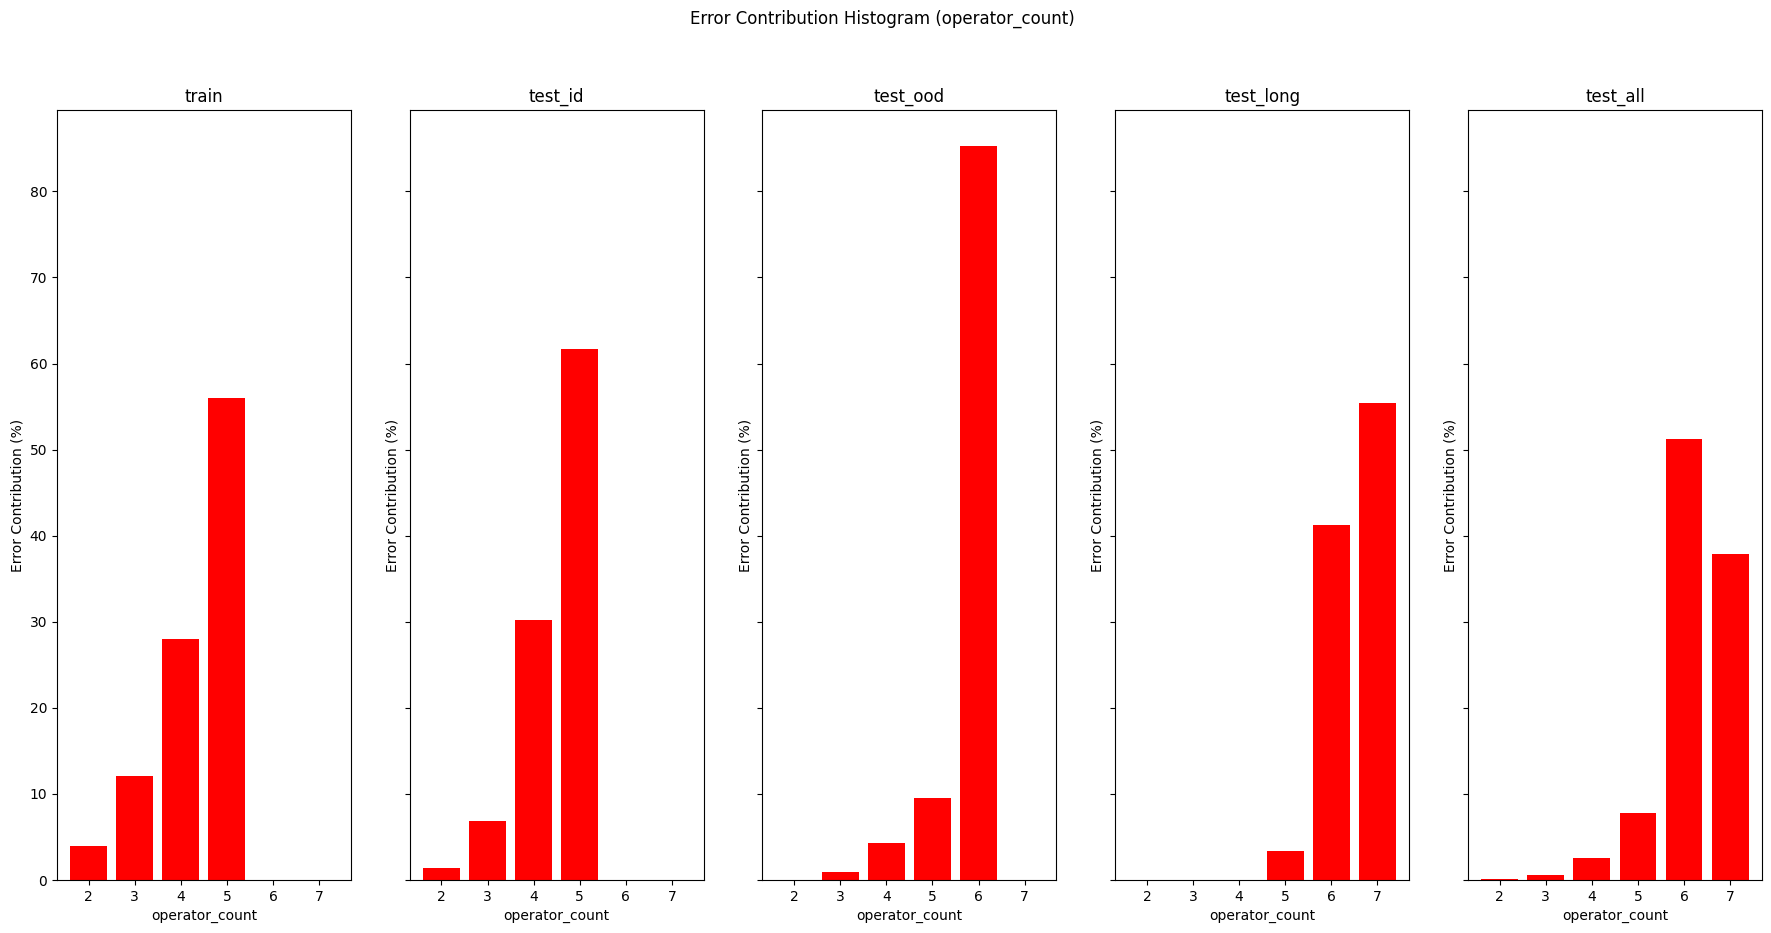

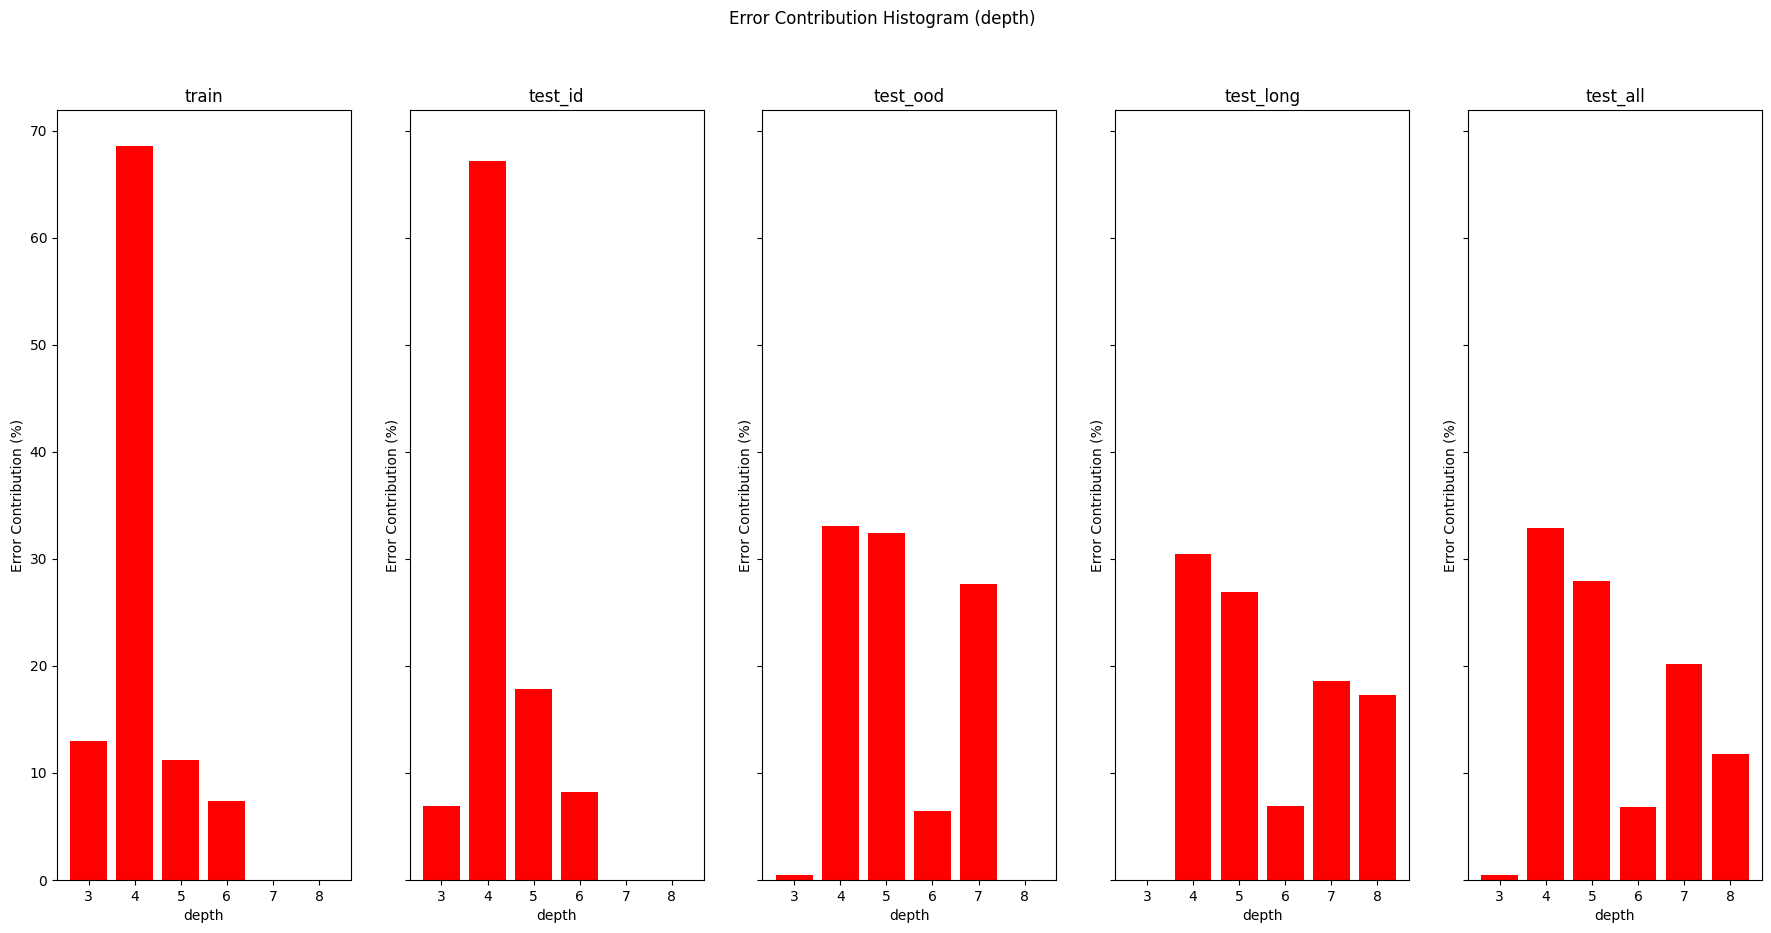

In [95]:
draw_error_contribution_grid("exact_match_transformer","length",save_path=os.path.join(DIAGRAM_DIR,'T_error_contrib_length.png'))
draw_error_contribution_grid("exact_match_transformer","operator_count",save_path=os.path.join(DIAGRAM_DIR,'T_error_contrib_operator.png'))
draw_error_contribution_grid("exact_match_transformer","depth",save_path=os.path.join(DIAGRAM_DIR,'T_error_contrib_depth.png'))

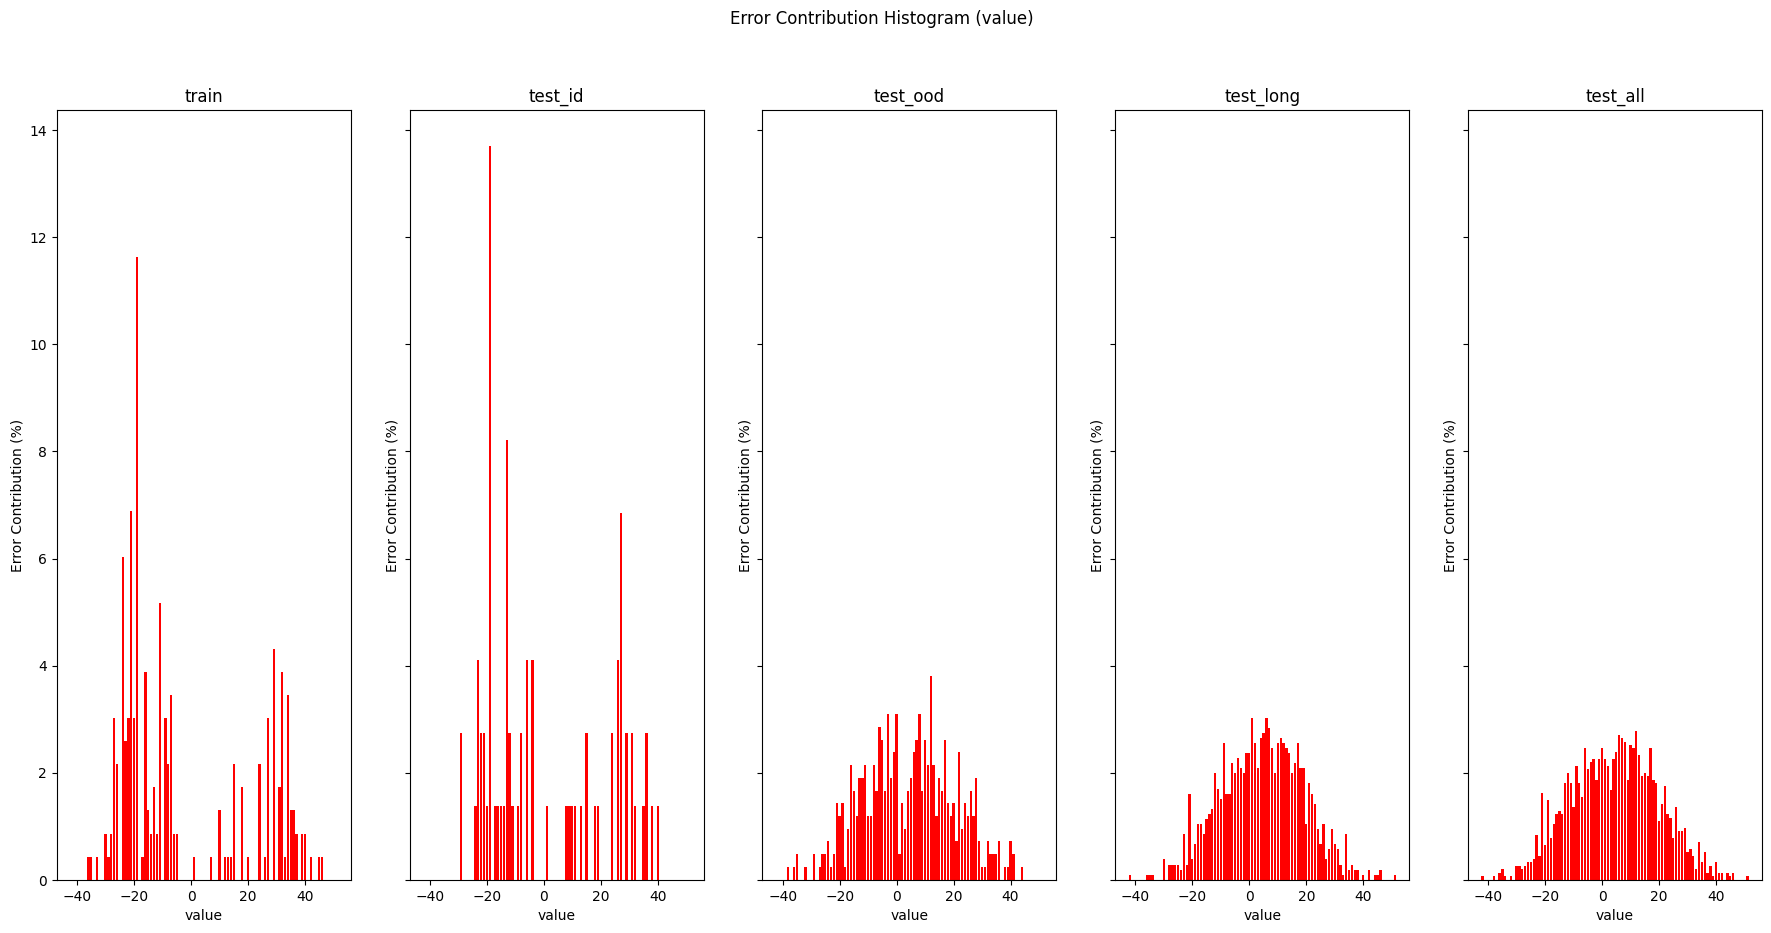

In [96]:
draw_error_contribution_grid("exact_match_transformer", "value", save_path=os.path.join(DIAGRAM_DIR,'T_error_contrib_value.png'))

### 7.5 Wasserstein Distance Between Training and Test Sets

The wasserstein shows the differences in distribution of the various test sets against the training set, explaining the large gaps in performance between various test sets. And as mentioned before, we were hoping to measure the distance between training set histogram and the error contributing histogram to see if we could identify any pattern that contribute to error.

In [97]:
print(wasserstein_distance_calc(data["train"], data["test_id"]))
print(wasserstein_distance_calc(data["train"], data["test_ood"]))
print(wasserstein_distance_calc(data["train"], data["test_long"]))

0.5483561840998068
1.2356187830937833
2.5617189851280724


# Notebook Run Time

In [98]:
TOTAL_TIME_USED = time.perf_counter() - START_TIME
print(f"Total Time Used:{TOTAL_TIME_USED}")

Total Time Used:120.55189418099985
